In [1]:
# =============================================================================
# CRISIS-CLIP: Enhanced Humanitarian Classification
# Implements: 1) Zero-Shot Prompt Engineering
#             2) Adapter-Based Fine-Tuning
#             3) LoRA (Low-Rank Adaptation)
# Compatible with your existing CrisisMMD pipeline
# =============================================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, classification_report, confusion_matrix, accuracy_score
from transformers import CLIPModel, CLIPProcessor
from peft import LoraConfig, get_peft_model, TaskType
from torch.amp import GradScaler, autocast
from tqdm import tqdm






In [2]:
# =============================================================================
# SECTION 0: CONFIGURATION HUB
# Change settings here — no need to hunt through the code
# =============================================================================

CONFIG = {
    # Paths
    "IMG_ROOT"      : r"F:\research\chatbot\D\Multi-modal-codes",
    "DATA_DIR"      : r"data\CrisisMMD\crisismmd_datasplit_all\crisismmd_datasplit_agreed_label",

    # Training
    "BATCH_SIZE"    : 16,
    "NUM_EPOCHS"    : 15,
    "EMBED_DIM"     : 512,
    "NUM_CLASSES"   : 5,

    # LoRA
    "LORA_R"        : 128,          # rank
    "LORA_ALPHA"    : 256,

    # Adapter
    "ADAPTER_DIM"   : 256,          # bottleneck size inside each adapter block
    "ADAPTER_DROPOUT": 0.1,

    # Focal Loss
    "FOCAL_ALPHA"   : [1.5, 0.8, 0.6, 1.8, 2.0],
    "FOCAL_GAMMA"   : 2.0,

    # LR — differential per group
    "LR_CLIP"       : 1e-6,
    "LR_FUSION"     : 5e-4,
    "LR_HEAD"       : 5e-4,
    "LR_ADAPTER"    : 1e-4,

    # Misc
    "SEED"          : 42,
    "SAVE_PATH"     : "best_humanitarian_enhanced.pth",
}

torch.manual_seed(CONFIG["SEED"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Device: {device}")



✅ Device: cuda


In [3]:
# =============================================================================
# SECTION 1: ZERO-SHOT PROMPT ENGINEERING
# =============================================================================
# Strategy: Replace bare class names with rich, context-aware description
# templates so CLIP's text encoder understands what to "look for" even without
# any gradient updates.  We use an ensemble of N prompts per class and average
# their embeddings — this is "ensemble prompt engineering".

PROMPT_TEMPLATES = [
    # Template set A — scene description style
    "A photo showing {}.",
    "An image of {} during a disaster.",
    "This tweet image depicts {}.",

    # Template set B — humanitarian context style
    "Crisis-related image about {}.",
    "Emergency response image showing {}.",
    "A disaster situation involving {}.",

    # Template set C — social-media tweet style
    "Tweet image: {} in an emergency zone.",
    "Social media post showing {} after a disaster.",

    # Template set D — specificity boost
    "Real-world evidence of {} captured during a humanitarian crisis.",
]

# Fine-grained class descriptions (richer than bare label names)
CLASS_DESCRIPTIONS = {
    "infrastructure_and_utility_damage": [
        "damaged roads, bridges, or buildings",
        "collapsed infrastructure and utility damage",
        "destroyed electricity lines, roads, or structures",
    ],
    "other_relevant_information": [
        "other relevant humanitarian information",
        "miscellaneous crisis-related content",
        "general disaster information and updates",
    ],
    "not_humanitarian": [
        "content unrelated to humanitarian disasters",
        "non-emergency, irrelevant social media post",
        "image not related to any crisis or disaster",
    ],
    "rescue_volunteering_or_donation_effort": [
        "rescue operations and volunteer efforts",
        "donation drives and relief work",
        "emergency responders helping disaster victims",
    ],
    "affected_individuals": [
        "people affected or injured by a disaster",
        "displaced civilians and disaster victims",
        "individuals in distress during an emergency",
    ],
}

LABEL_MAP = {
    "infrastructure_and_utility_damage"    : 0,
    "other_relevant_information"           : 1,
    "not_humanitarian"                     : 2,
    "rescue_volunteering_or_donation_effort": 3,
    "affected_individuals"                 : 4,
}
IDX_TO_LABEL = {v: k for k, v in LABEL_MAP.items()}


def build_zero_shot_text_embeddings(clip_model, clip_processor, device):
    """
    Pre-compute averaged text embeddings for every class using the full
    ensemble of (template × description) combinations.

    Returns
    -------
    text_embeds : Tensor  shape (num_classes, embed_dim)  — L2-normalised
    """
    clip_model.eval()
    class_embeddings = []

    for label_str, descriptions in CLASS_DESCRIPTIONS.items():
        all_prompts = []
        for template in PROMPT_TEMPLATES:
            for desc in descriptions:
                all_prompts.append(template.format(desc))

        # Tokenise the whole batch at once
        inputs = clip_processor(
            text=all_prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=77,
        ).to(device)

        with torch.no_grad():
            text_feats = clip_model.get_text_features(**inputs)  # (N_prompts, D)
            text_feats = F.normalize(text_feats, p=2, dim=-1)
            class_embed = text_feats.mean(dim=0)                 # ensemble average
            class_embed = F.normalize(class_embed, p=2, dim=-1)  # re-normalise

        class_embeddings.append(class_embed)

    return torch.stack(class_embeddings, dim=0)   # (num_classes, D)


def zero_shot_predict(clip_model, clip_processor, image_batch, text_embeds, device):
    """
    Classify a batch of images in zero-shot mode using cosine similarity
    between image features and the pre-computed class text embeddings.

    Parameters
    ----------
    image_batch : Tensor  (B, 3, H, W)  — already processed pixel_values
    text_embeds : Tensor  (num_classes, D)  — from build_zero_shot_text_embeddings

    Returns
    -------
    logits : Tensor  (B, num_classes)  — similarity scores (higher = more likely)
    preds  : Tensor  (B,)             — argmax class indices
    """
    clip_model.eval()
    with torch.no_grad():
        img_feats = clip_model.get_image_features(pixel_values=image_batch)
        img_feats = F.normalize(img_feats, p=2, dim=-1)          # (B, D)

    # Cosine similarity as logits — scale by 100 (same as CLIP paper)
    logits = 100.0 * img_feats @ text_embeds.T                    # (B, num_classes)
    preds  = logits.argmax(dim=-1)
    return logits, preds


def evaluate_zero_shot(clip_model, clip_processor, test_loader, device):
    """Run zero-shot evaluation and print the classification report."""
    print("\n" + "=" * 60)
    print("🔍 ZERO-SHOT EVALUATION (Prompt Engineering Only)")
    print("=" * 60)

    text_embeds = build_zero_shot_text_embeddings(clip_model, clip_processor, device)

    y_true, y_pred = [], []
    for batch in tqdm(test_loader, desc="Zero-Shot Inference"):
        if batch is None:
            continue
        pix    = batch["pixel_values"].to(device)
        labels = batch["label"].numpy()

        _, preds = zero_shot_predict(clip_model, clip_processor, pix, text_embeds, device)
        y_pred.extend(preds.cpu().numpy())
        y_true.extend(labels)

    label_names = list(CLASS_DESCRIPTIONS.keys())
    acc  = accuracy_score(y_true, y_pred)
    mf1  = f1_score(y_true, y_pred, average="macro", zero_division=0)
    print(f"\nOverall Accuracy : {acc:.4f}")
    print(f"Macro-F1         : {mf1:.4f}")
    print("-" * 60)
    print(classification_report(y_true, y_pred, target_names=label_names, zero_division=0))

    return {"accuracy": acc, "macro_f1": mf1, "y_true": y_true, "y_pred": y_pred}



In [4]:
# =============================================================================
# SECTION 2: ADAPTER MODULE
# =============================================================================
# A lightweight bottleneck (down-project → activation → up-project) injected
# after each CLIP transformer layer.  Only adapter parameters are updated;
# CLIP weights stay frozen.  This gives >90% of full fine-tuning performance
# at <5% of the parameter cost.

class AdapterBlock(nn.Module):
    """
    Bottleneck adapter inserted after every transformer layer.

    Architecture:  x → LayerNorm → Linear(d→bottleneck) → GELU
                     → Linear(bottleneck→d) → Dropout → + x  (residual)
    """
    def __init__(self, input_dim: int, bottleneck_dim: int, dropout: float = 0.1):
        super().__init__()
        self.norm   = nn.LayerNorm(input_dim)
        self.down   = nn.Linear(input_dim, bottleneck_dim)
        self.act    = nn.GELU()
        self.up     = nn.Linear(bottleneck_dim, input_dim)
        self.drop   = nn.Dropout(dropout)

        # Initialise up-projection to near-zero so adapter starts as identity
        nn.init.zeros_(self.up.weight)
        nn.init.zeros_(self.up.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        residual = x
        x = self.norm(x)
        x = self.drop(self.act(self.down(x)))
        x = self.up(x)
        return x + residual


class CLIPWithAdapters(nn.Module):
    """
    Wraps CLIPModel and injects AdapterBlock after every vision & text
    transformer encoder layer.  CLIP backbone is frozen; only adapters train.
    """
    def __init__(
        self,
        clip_model: CLIPModel,
        adapter_dim: int   = 256,
        adapter_drop: float = 0.1,
    ):
        super().__init__()
        self.clip = clip_model

        # ── Freeze all CLIP parameters ──────────────────────────────────────
        for p in self.clip.parameters():
            p.requires_grad_(False)

        embed_dim = self.clip.config.projection_dim   # typically 512

        # ── Build vision adapters (one per encoder layer) ───────────────────
        n_vision_layers = len(self.clip.vision_model.encoder.layers)
        self.vision_adapters = nn.ModuleList([
            AdapterBlock(
                self.clip.vision_model.encoder.layers[i].layer_norm1.normalized_shape[0],
                adapter_dim,
                adapter_drop,
            )
            for i in range(n_vision_layers)
        ])

        # ── Build text adapters ──────────────────────────────────────────────
        n_text_layers = len(self.clip.text_model.encoder.layers)
        self.text_adapters = nn.ModuleList([
            AdapterBlock(
                self.clip.text_model.encoder.layers[i].layer_norm1.normalized_shape[0],
                adapter_dim,
                adapter_drop,
            )
            for i in range(n_text_layers)
        ])

        # ── Vision projection adapter (aligns to embed_dim) ─────────────────
        v_hidden = self.clip.vision_model.encoder.layers[-1].layer_norm1.normalized_shape[0]
        self.vision_proj_adapter = AdapterBlock(embed_dim, adapter_dim, adapter_drop)
        self.text_proj_adapter   = AdapterBlock(embed_dim, adapter_dim, adapter_drop)

    # ── Custom forward passes that inject adapters ───────────────────────────

    def get_adapted_vision_features(self, pixel_values: torch.Tensor) -> torch.Tensor:
        vision_outputs = self.clip.vision_model(
            pixel_values=pixel_values,
            output_hidden_states=True,
        )
        # Pass every layer's hidden state through its adapter
        hidden = vision_outputs.last_hidden_state                # (B, seq, hidden)
        all_hidden = vision_outputs.hidden_states                # tuple of (B, seq, hidden)

        # Apply adapters layer by layer using stored hidden states
        adapted = all_hidden[0]
        for i, layer in enumerate(self.clip.vision_model.encoder.layers):
            adapted = layer(adapted)[0]
            adapted = self.vision_adapters[i](adapted)

        # Extract [CLS] token, project, normalise
        cls_token    = adapted[:, 0, :]
        projected    = self.clip.visual_projection(cls_token)
        projected    = self.vision_proj_adapter(projected)
        return F.normalize(projected, p=2, dim=-1)

    def get_adapted_text_features(
        self, input_ids: torch.Tensor, attention_mask: torch.Tensor
    ) -> torch.Tensor:
        text_outputs = self.clip.text_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_hidden_states=True,
        )
        adapted = text_outputs.hidden_states[0]
        for i, layer in enumerate(self.clip.text_model.encoder.layers):
            adapted = layer(adapted, attention_mask=None, causal_attention_mask=None)[0]
            adapted = self.text_adapters[i](adapted)

        # EOS token position carries the sentence embedding for CLIP
        eos_pos   = input_ids.argmax(dim=-1)
        eos_token = adapted[torch.arange(adapted.shape[0]), eos_pos, :]
        projected = self.clip.text_projection(eos_token)
        projected = self.text_proj_adapter(projected)
        return F.normalize(projected, p=2, dim=-1)

    def forward(
        self,
        input_ids:      torch.Tensor,
        attention_mask: torch.Tensor,
        pixel_values:   torch.Tensor,
    ) -> tuple:
        t_f = self.get_adapted_text_features(input_ids, attention_mask)
        i_f = self.get_adapted_vision_features(pixel_values)
        return t_f, i_f



In [4]:

# =============================================================================
# SECTION 3: DATASET  (unchanged from your original, consolidated here)
# =============================================================================

class CrisisHumanitarianDataset(Dataset):
    def __init__(self, filepath, img_dir, processor):
        self.data      = pd.read_csv(filepath, sep="\t")
        self.img_dir   = img_dir
        self.processor = processor
        self.label_map = LABEL_MAP

        self.data = self.data[
            self.data["label"].isin(self.label_map.keys())
        ].reset_index(drop=True)
        print(f"Loaded {len(self.data)} rows from {os.path.basename(filepath)}")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row     = self.data.iloc[idx]
        rel     = str(row["image"]).replace("\\", "/").lstrip("/")
        img_path = os.path.normpath(os.path.join(self.img_dir, rel))

        if not os.path.exists(img_path):
            return None
        try:
            image  = Image.open(img_path).convert("RGB")
            inputs = self.processor(
                text=[str(row["tweet_text"])],
                images=image,
                return_tensors="pt",
                padding="max_length",
                max_length=77,
                truncation=True,
            )
            return {
                "input_ids"     : inputs["input_ids"].squeeze(0),
                "attention_mask": inputs["attention_mask"].squeeze(0),
                "pixel_values"  : inputs["pixel_values"].squeeze(0),
                "label"         : torch.tensor(self.label_map[row["label"]], dtype=torch.long),
            }
        except Exception:
            return None


def fast_collate(batch):
    batch = [x for x in batch if x is not None]
    return torch.utils.data.dataloader.default_collate(batch) if batch else None


# =============================================================================
# SECTION 4: SHARED MODULES  (Fusion, FocalLoss, Classifier Head)
# =============================================================================

class GatedHumanitarianFusion(nn.Module):
    """Learns how much to trust text vs. image features dynamically."""
    def __init__(self, embed_dim: int = 512):
        super().__init__()
        self.text_proj  = nn.Linear(embed_dim, 512)
        self.image_proj = nn.Linear(embed_dim, 512)
        self.gate       = nn.Sequential(
            nn.Linear(embed_dim * 2, 256),
            nn.GELU(),
            nn.Linear(256, 2),
            nn.Softmax(dim=1),
        )
        self.layer_norm = nn.LayerNorm(512)

    def forward(self, t_f, i_f):
        t_p     = F.gelu(self.text_proj(t_f))
        i_p     = F.gelu(self.image_proj(i_f))
        weights = self.gate(torch.cat([t_f, i_f], dim=1))
        return self.layer_norm(weights[:, 0:1] * t_p + weights[:, 1:2] * i_p)


class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma: float = 2.0):
        super().__init__()
        self.gamma = gamma
        self.alpha = torch.tensor(alpha) if alpha is not None else None

    def forward(self, inputs, targets):
        log_p   = F.log_softmax(inputs, dim=-1)
        weight  = self.alpha.to(inputs.device) if self.alpha is not None else None
        ce_loss = F.nll_loss(log_p, targets, reduction="none", weight=weight)
        return ((1 - torch.exp(-ce_loss)) ** self.gamma * ce_loss).mean()


class ClassifierHead(nn.Module):
    def __init__(self, in_dim: int = 512, num_classes: int = 5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        return self.net(x)



In [5]:

# =============================================================================
# SECTION 5: FULL MODEL — THREE VARIANTS IN ONE CLASS
# =============================================================================

class HumanitarianVLM(nn.Module):
    """
    mode = "lora"     → LoRA adapts q_proj / v_proj inside CLIP
    mode = "adapter"  → Bottleneck adapters after every transformer layer
    mode = "baseline" → Your original model (no PEFT)
    """
    def __init__(
        self,
        num_classes: int = 5,
        mode: str = "lora",
        lora_r: int = 128,
        lora_alpha: int = 256,
        adapter_dim: int = 256,
        adapter_drop: float = 0.1,
    ):
        super().__init__()
        self.mode = mode

        raw_clip = CLIPModel.from_pretrained(
            "openai/clip-vit-base-patch32", use_safetensors=True
        )

        if mode == "lora":
            # ── Apply LoRA via PEFT ─────────────────────────────────────────
            lora_cfg = LoraConfig(
                r=lora_r,
                lora_alpha=lora_alpha,
                target_modules=["q_proj", "v_proj"],  # attention projections
                lora_dropout=0.05,
                bias="none",
            )
            self.clip    = get_peft_model(raw_clip, lora_cfg)
            self._mode_fn = self._forward_lora

        elif mode == "adapter":
            # ── Inject bottleneck adapters ──────────────────────────────────
            self.clip_with_adapters = CLIPWithAdapters(
                raw_clip, adapter_dim, adapter_drop
            )
            self._mode_fn = self._forward_adapter

        else:  # baseline
            self.clip    = raw_clip
            self._mode_fn = self._forward_baseline

        self.fusion     = GatedHumanitarianFusion(CONFIG["EMBED_DIM"])
        self.classifier = ClassifierHead(CONFIG["EMBED_DIM"], num_classes)

    # ── Mode-specific forward implementations ────────────────────────────────

    def _forward_lora(self, ids, mask, pix):
        t_f = F.normalize(
            self.clip.get_text_features(input_ids=ids, attention_mask=mask), p=2, dim=-1
        )
        i_f = F.normalize(self.clip.get_image_features(pixel_values=pix), p=2, dim=-1)
        return t_f, i_f

    def _forward_adapter(self, ids, mask, pix):
        t_f, i_f = self.clip_with_adapters(ids, mask, pix)
        return t_f, i_f

    def _forward_baseline(self, ids, mask, pix):
        t_f = F.normalize(
            self.clip.get_text_features(input_ids=ids, attention_mask=mask), p=2, dim=-1
        )
        i_f = F.normalize(self.clip.get_image_features(pixel_values=pix), p=2, dim=-1)
        return t_f, i_f

    def forward(self, ids, mask, pix):
        t_f, i_f = self._mode_fn(ids, mask, pix)
        fused    = self.fusion(t_f, i_f)
        return self.classifier(fused)

    def count_trainable(self):
        total   = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"  Trainable params : {trainable:,} / {total:,}  ({100*trainable/total:.2f}%)")


In [6]:


# =============================================================================
# SECTION 6: OPTIMIZER FACTORY
# Separate LR groups so CLIP backbone, fusion, classifier, and adapters
# can each tune at the right speed.
# =============================================================================

def build_optimizer(model: HumanitarianVLM, mode: str) -> optim.AdamW:
    if mode == "lora":
        param_groups = [
            {"params": model.clip.parameters(),       "lr": CONFIG["LR_CLIP"],   "weight_decay": 0.05},
            {"params": model.fusion.parameters(),      "lr": CONFIG["LR_FUSION"]},
            {"params": model.classifier.parameters(),  "lr": CONFIG["LR_HEAD"]},
        ]
    elif mode == "adapter":
        param_groups = [
            # Adapter params get a dedicated (slightly higher) LR
            {"params": model.clip_with_adapters.vision_adapters.parameters(), "lr": CONFIG["LR_ADAPTER"]},
            {"params": model.clip_with_adapters.text_adapters.parameters(),   "lr": CONFIG["LR_ADAPTER"]},
            {"params": model.clip_with_adapters.vision_proj_adapter.parameters(), "lr": CONFIG["LR_ADAPTER"]},
            {"params": model.clip_with_adapters.text_proj_adapter.parameters(),   "lr": CONFIG["LR_ADAPTER"]},
            {"params": model.fusion.parameters(),     "lr": CONFIG["LR_FUSION"]},
            {"params": model.classifier.parameters(), "lr": CONFIG["LR_HEAD"]},
        ]
    else:
        param_groups = [
            {"params": model.clip.parameters(),       "lr": CONFIG["LR_CLIP"],   "weight_decay": 0.05},
            {"params": model.fusion.parameters(),      "lr": CONFIG["LR_FUSION"]},
            {"params": model.classifier.parameters(),  "lr": CONFIG["LR_HEAD"]},
        ]
    return optim.AdamW(param_groups, weight_decay=0.01)



In [7]:


# =============================================================================
# SECTION 7: TRAINING ENGINE
# =============================================================================

def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    model.train()
    total_loss = 0.0
    for batch in tqdm(loader, desc="  Train", leave=False):
        if batch is None:
            continue
        ids  = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        pix  = batch["pixel_values"].to(device)
        lbl  = batch["label"].to(device)

        optimizer.zero_grad(set_to_none=True)
        with autocast("cuda"):
            loss = criterion(model(ids, mask, pix), lbl)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()

    return total_loss / max(len(loader), 1)


@torch.no_grad()
def evaluate(model, loader, device, split="Val"):
    model.eval()
    preds, labels = [], []
    for batch in tqdm(loader, desc=f"  {split}", leave=False):
        if batch is None:
            continue
        ids  = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        pix  = batch["pixel_values"].to(device)

        out = model(ids, mask, pix)
        preds.extend(torch.argmax(out, 1).cpu().numpy())
        labels.extend(batch["label"].numpy())

    acc = accuracy_score(labels, preds)
    mf1 = f1_score(labels, preds, average="macro", zero_division=0)
    return acc, mf1, labels, preds


def train(model, train_loader, dev_loader, optimizer, criterion, scaler, device, mode="lora"):
    history     = {"train_loss": [], "dev_acc": [], "dev_f1": []}
    best_val_f1 = 0.0
    save_path   = CONFIG["SAVE_PATH"].replace(".pth", f"_{mode}.pth")

    print(f"\n{'='*60}")
    print(f"🚀 TRAINING  mode={mode.upper()}  epochs={CONFIG['NUM_EPOCHS']}")
    print(f"{'='*60}")
    model.count_trainable()

    for epoch in range(CONFIG["NUM_EPOCHS"]):
        epoch_loss      = train_one_epoch(model, train_loader, optimizer, criterion, scaler, device)
        dev_acc, dev_f1, _, _ = evaluate(model, dev_loader, device, split="Dev")

        history["train_loss"].append(epoch_loss)
        history["dev_acc"].append(dev_acc)
        history["dev_f1"].append(dev_f1)

        star = ""
        if dev_f1 > best_val_f1:
            best_val_f1 = dev_f1
            torch.save(model.state_dict(), save_path)
            star = "  ⭐ saved"

        print(
            f"Epoch {epoch+1:02d}/{CONFIG['NUM_EPOCHS']}  "
            f"Loss={epoch_loss:.4f}  "
            f"Dev-Acc={dev_acc:.4f}  "
            f"Dev-F1={dev_f1:.4f}{star}"
        )

    print(f"\n✅ Best Dev Macro-F1 = {best_val_f1:.4f}  (weights → {save_path})")
    return history, save_path


In [8]:



# =============================================================================
# SECTION 8: VISUALISATION SUITE  (publication-ready, 300 DPI)
# =============================================================================

RESEARCH_LABEL_NAMES = [
    "Infrastructure",
    "Other Relevant Info",
    "Not Humanitarian",
    "Rescue/Donation",
    "Affected Individuals",
]


def plot_convergence(history, mode, save=True):
    fig, ax1 = plt.subplots(figsize=(12, 7))
    epochs = range(1, len(history["train_loss"]) + 1)

    ax1.set_xlabel("Training Epochs", fontsize=12)
    ax1.set_ylabel("Focal Loss", color="tab:red", fontsize=12)
    ax1.plot(epochs, history["train_loss"], color="tab:red",
             marker="o", linewidth=2.5, label="Training Loss")
    ax1.tick_params(axis="y", labelcolor="tab:red")
    ax1.grid(True, linestyle="--", alpha=0.5)

    ax2 = ax1.twinx()
    ax2.set_ylabel("Validation Macro-F1", color="tab:blue", fontsize=12)
    ax2.plot(epochs, history["dev_f1"], color="tab:blue",
             marker="s", linewidth=2.5, label="Dev Macro-F1")
    ax2.tick_params(axis="y", labelcolor="tab:blue")

    plt.title(f"Convergence Analysis — {mode.upper()}", fontsize=14, fontweight="bold")
    fig.tight_layout()
    if save:
        plt.savefig(f"convergence_{mode}.png", dpi=300)
    plt.show()


def plot_confusion_matrix(y_true, y_pred, label_names, mode, save=True):
    cm      = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(12, 10))
    sns.heatmap(
        cm_norm, annot=True, fmt=".2f", cmap="Blues",
        xticklabels=label_names, yticklabels=label_names,
        square=True, cbar_kws={"shrink": 0.8},
    )
    plt.title(f"Normalized Confusion Matrix — {mode.upper()}", fontsize=15, fontweight="bold", pad=20)
    plt.ylabel("Ground Truth", fontsize=12, fontweight="bold")
    plt.xlabel("Model Prediction", fontsize=12, fontweight="bold")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    if save:
        plt.savefig(f"confusion_matrix_{mode}.png", dpi=300, bbox_inches="tight")
    plt.show()


def compare_modes(results_dict):
    """
    Bar chart comparing Accuracy & Macro-F1 across all three modes.
    results_dict = {"lora": {"acc": x, "f1": y}, "adapter": {...}, "zero_shot": {...}}
    """
    modes = list(results_dict.keys())
    accs  = [results_dict[m]["acc"] for m in modes]
    f1s   = [results_dict[m]["f1"]  for m in modes]

    x     = np.arange(len(modes))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    bars1   = ax.bar(x - width / 2, accs, width, label="Accuracy",  color="steelblue")
    bars2   = ax.bar(x + width / 2, f1s,  width, label="Macro-F1",  color="coral")

    ax.set_ylabel("Score", fontsize=12)
    ax.set_title("Method Comparison: Zero-Shot vs Adapter vs LoRA", fontsize=14, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels([m.upper() for m in modes])
    ax.legend()
    ax.set_ylim(0, 1.05)

    for bar in bars1 + bars2:
        ax.annotate(
            f"{bar.get_height():.3f}",
            xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
            xytext=(0, 3), textcoords="offset points",
            ha="center", va="bottom", fontsize=10,
        )

    ax.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.savefig("method_comparison.png", dpi=300)
    plt.show()


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Loaded 6126 rows from task_humanitarian_text_img_agreed_lab_train.tsv
Loaded 998 rows from task_humanitarian_text_img_agreed_lab_dev.tsv
Loaded 955 rows from task_humanitarian_text_img_agreed_lab_test.tsv

🔍 ZERO-SHOT EVALUATION (Prompt Engineering Only)


Zero-Shot Inference: 100%|██████████| 60/60 [00:35<00:00,  1.68it/s]



Overall Accuracy : 0.6649
Macro-F1         : 0.5617
------------------------------------------------------------
                                        precision    recall  f1-score   support

     infrastructure_and_utility_damage       0.39      0.73      0.51        81
            other_relevant_information       0.71      0.59      0.65       235
                      not_humanitarian       0.82      0.68      0.74       504
rescue_volunteering_or_donation_effort       0.64      0.69      0.67       126
                  affected_individuals       0.14      0.89      0.24         9

                              accuracy                           0.66       955
                             macro avg       0.54      0.72      0.56       955
                          weighted avg       0.73      0.66      0.68       955



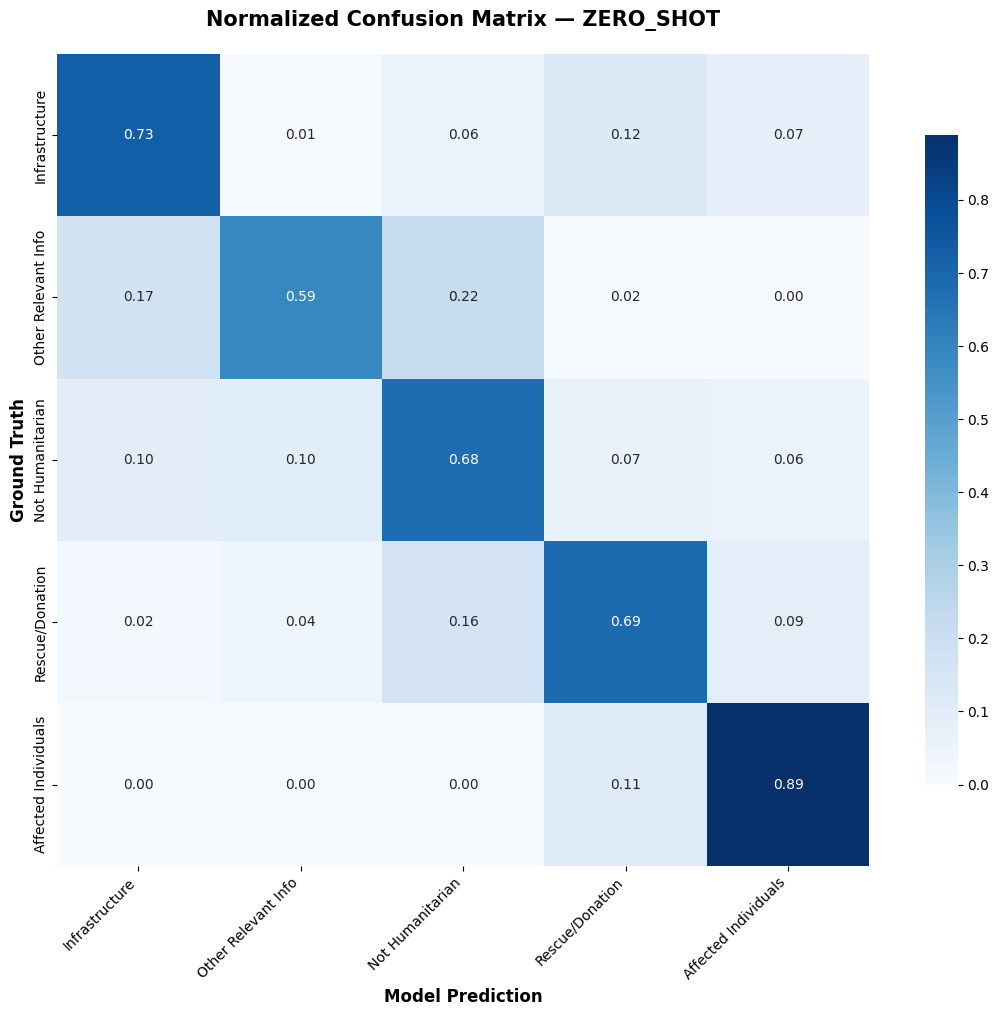



🔧 BUILDING MODEL  mode=ADAPTER


NameError: name 'CLIPWithAdapters' is not defined

In [9]:
# =============================================================================
# SECTION 9: MAIN PIPELINE
# =============================================================================

if __name__ == "__main__":

    # ── 9.1  Processor & Data ─────────────────────────────────────────────────
    processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

    DATA_ROOT = os.path.join(CONFIG["IMG_ROOT"], CONFIG["DATA_DIR"])
    train_ds  = CrisisHumanitarianDataset(
        os.path.join(DATA_ROOT, "task_humanitarian_text_img_agreed_lab_train.tsv"),
        CONFIG["IMG_ROOT"], processor,
    )
    dev_ds   = CrisisHumanitarianDataset(
        os.path.join(DATA_ROOT, "task_humanitarian_text_img_agreed_lab_dev.tsv"),
        CONFIG["IMG_ROOT"], processor,
    )
    test_ds  = CrisisHumanitarianDataset(
        os.path.join(DATA_ROOT, "task_humanitarian_text_img_agreed_lab_test.tsv"),
        CONFIG["IMG_ROOT"], processor,
    )

    make_loader = lambda ds, shuffle: DataLoader(
        ds,
        batch_size=CONFIG["BATCH_SIZE"],
        shuffle=shuffle,
        collate_fn=fast_collate,
        num_workers=0,
        pin_memory=True,
    )
    train_loader = make_loader(train_ds, True)
    dev_loader   = make_loader(dev_ds,   False)
    test_loader  = make_loader(test_ds,  False)

    criterion = FocalLoss(
        alpha=CONFIG["FOCAL_ALPHA"],
        gamma=CONFIG["FOCAL_GAMMA"],
    )
    scaler    = GradScaler("cuda")

    all_results = {}

    # ══════════════════════════════════════════════════════════════════════════
    # STEP A — ZERO-SHOT PROMPT ENGINEERING  (no training needed)
    # ══════════════════════════════════════════════════════════════════════════
    raw_clip = CLIPModel.from_pretrained(
        "openai/clip-vit-base-patch32", use_safetensors=True
    ).to(device)

    zs_results = evaluate_zero_shot(raw_clip, processor, test_loader, device)
    all_results["zero_shot"] = {
        "acc": zs_results["accuracy"],
        "f1" : zs_results["macro_f1"],
    }
    plot_confusion_matrix(
        zs_results["y_true"], zs_results["y_pred"],
        RESEARCH_LABEL_NAMES, "zero_shot",
    )

    # ══════════════════════════════════════════════════════════════════════════
    # STEP B — ADAPTER FINE-TUNING
    # ══════════════════════════════════════════════════════════════════════════
    print("\n\n" + "=" * 60)
    print("🔧 BUILDING MODEL  mode=ADAPTER")
    print("=" * 60)

    model_adapter = HumanitarianVLM(
        num_classes=CONFIG["NUM_CLASSES"],
        mode="adapter",
        adapter_dim=CONFIG["ADAPTER_DIM"],
        adapter_drop=CONFIG["ADAPTER_DROPOUT"],
    ).to(device)

    opt_adapter = build_optimizer(model_adapter, "adapter")

    history_adapter, ckpt_adapter = train(
        model_adapter, train_loader, dev_loader,
        opt_adapter, criterion, scaler, device, mode="adapter",
    )

    # Load best weights → test
    model_adapter.load_state_dict(torch.load(ckpt_adapter, weights_only=True))
    test_acc_a, test_f1_a, yt_a, yp_a = evaluate(model_adapter, test_loader, device, split="Test")
    print(f"\n📊 ADAPTER  Test Acc={test_acc_a:.4f}  Test Macro-F1={test_f1_a:.4f}")
    print(classification_report(yt_a, yp_a, target_names=RESEARCH_LABEL_NAMES, zero_division=0))

    all_results["adapter"] = {"acc": test_acc_a, "f1": test_f1_a}
    plot_convergence(history_adapter, "adapter")
    plot_confusion_matrix(yt_a, yp_a, RESEARCH_LABEL_NAMES, "adapter")

    # ══════════════════════════════════════════════════════════════════════════
    # STEP C — LoRA FINE-TUNING
    # ══════════════════════════════════════════════════════════════════════════
    print("\n\n" + "=" * 60)
    print("🔧 BUILDING MODEL  mode=LORA")
    print("=" * 60)

    # Re-initialise scaler (resets gradient scale state)
    scaler = GradScaler("cuda")

    model_lora = HumanitarianVLM(
        num_classes=CONFIG["NUM_CLASSES"],
        mode="lora",
        lora_r=CONFIG["LORA_R"],
        lora_alpha=CONFIG["LORA_ALPHA"],
    ).to(device)

    opt_lora = build_optimizer(model_lora, "lora")

    history_lora, ckpt_lora = train(
        model_lora, train_loader, dev_loader,
        opt_lora, criterion, scaler, device, mode="lora",
    )

    # Load best weights → test
    model_lora.load_state_dict(torch.load(ckpt_lora, weights_only=True))
    test_acc_l, test_f1_l, yt_l, yp_l = evaluate(model_lora, test_loader, device, split="Test")
    print(f"\n📊 LoRA  Test Acc={test_acc_l:.4f}  Test Macro-F1={test_f1_l:.4f}")
    print(classification_report(yt_l, yp_l, target_names=RESEARCH_LABEL_NAMES, zero_division=0))

    all_results["lora"] = {"acc": test_acc_l, "f1": test_f1_l}
    plot_convergence(history_lora, "lora")
    plot_confusion_matrix(yt_l, yp_l, RESEARCH_LABEL_NAMES, "lora")

    # ══════════════════════════════════════════════════════════════════════════
    # STEP D — FINAL COMPARISON CHART
    # ══════════════════════════════════════════════════════════════════════════
    compare_modes(all_results)

    print("\n\n" + "=" * 60)
    print("🏆 FINAL SUMMARY")
    print("=" * 60)
    for method, scores in all_results.items():
        print(f"  {method.upper():12s}  Acc={scores['acc']:.4f}  Macro-F1={scores['f1']:.4f}")
    print("=" * 60)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


✅ Device: cuda
Loaded 6126 rows from task_humanitarian_text_img_agreed_lab_train.tsv
Loaded 998 rows from task_humanitarian_text_img_agreed_lab_dev.tsv
Loaded 955 rows from task_humanitarian_text_img_agreed_lab_test.tsv

🔍 ZERO-SHOT EVALUATION (Prompt Engineering Only)


Zero-Shot Inference: 100%|██████████| 60/60 [00:38<00:00,  1.56it/s]



Overall Accuracy : 0.6649
Macro-F1         : 0.5617
------------------------------------------------------------
                                        precision    recall  f1-score   support

     infrastructure_and_utility_damage       0.39      0.73      0.51        81
            other_relevant_information       0.71      0.59      0.65       235
                      not_humanitarian       0.82      0.68      0.74       504
rescue_volunteering_or_donation_effort       0.64      0.69      0.67       126
                  affected_individuals       0.14      0.89      0.24         9

                              accuracy                           0.66       955
                             macro avg       0.54      0.72      0.56       955
                          weighted avg       0.73      0.66      0.68       955



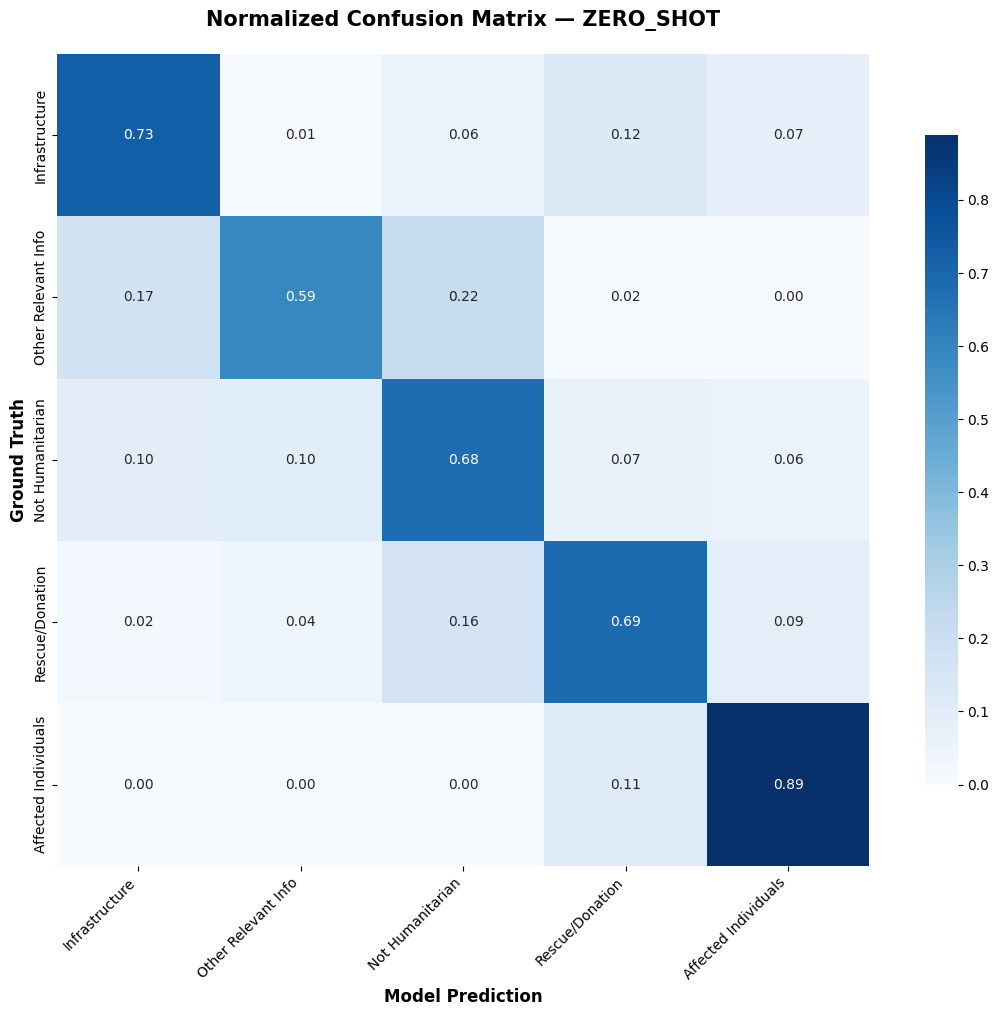



🔧 BUILDING MODEL  mode=ADAPTER

🚀 TRAINING  mode=ADAPTER  epochs=15
  Trainable params : 5,302,279 / 156,579,592  (3.39%)


  Train:  16%|█▌        | 60/383 [00:42<04:03,  1.33it/s]d:\Anaconda\envs\tweet_project\lib\site-packages\PIL\Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 01/15  Loss=0.2151  Dev-Acc=0.8848  Dev-F1=0.7841  ⭐ saved


  Train:  11%|█         | 41/383 [00:28<03:49,  1.49it/s]d:\Anaconda\envs\tweet_project\lib\site-packages\PIL\Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 02/15  Loss=0.0956  Dev-Acc=0.8637  Dev-F1=0.7551


...

  Train:  69%|██████▊   | 263/383 [01:50<00:48,  2.45it/s]d:\Anaconda\envs\tweet_project\lib\site-packages\PIL\Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 14/15  Loss=0.0109  Dev-Acc=0.8768  Dev-F1=0.7961


  Train:  98%|█████████▊| 374/383 [02:36<00:03,  2.55it/s]d:\Anaconda\envs\tweet_project\lib\site-packages\PIL\Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 15/15  Loss=0.0109  Dev-Acc=0.8808  Dev-F1=0.8397

✅ Best Dev Macro-F1 = 0.8463  (weights → best_humanitarian_enhanced_adapter.pth)



📊 ADAPTER  Test Acc=0.9058  Test Macro-F1=0.8324
                      precision    recall  f1-score   support

      Infrastructure       0.95      0.85      0.90        81
 Other Relevant Info       0.88      0.91      0.90       235
    Not Humanitarian       0.93      0.93      0.93       504
     Rescue/Donation       0.89      0.86      0.87       126
Affected Individuals       0.50      0.67      0.57         9

            accuracy                           0.91       955
           macro avg       0.83      0.84      0.83       955
        weighted avg       0.91      0.91      0.91       955



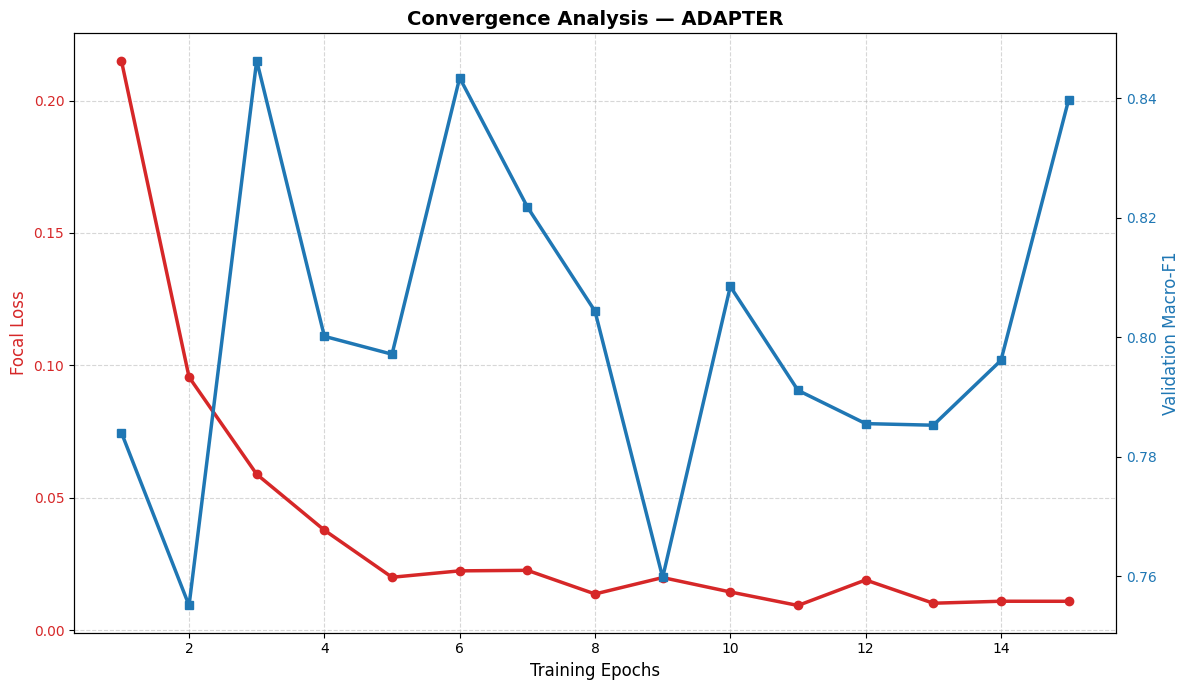

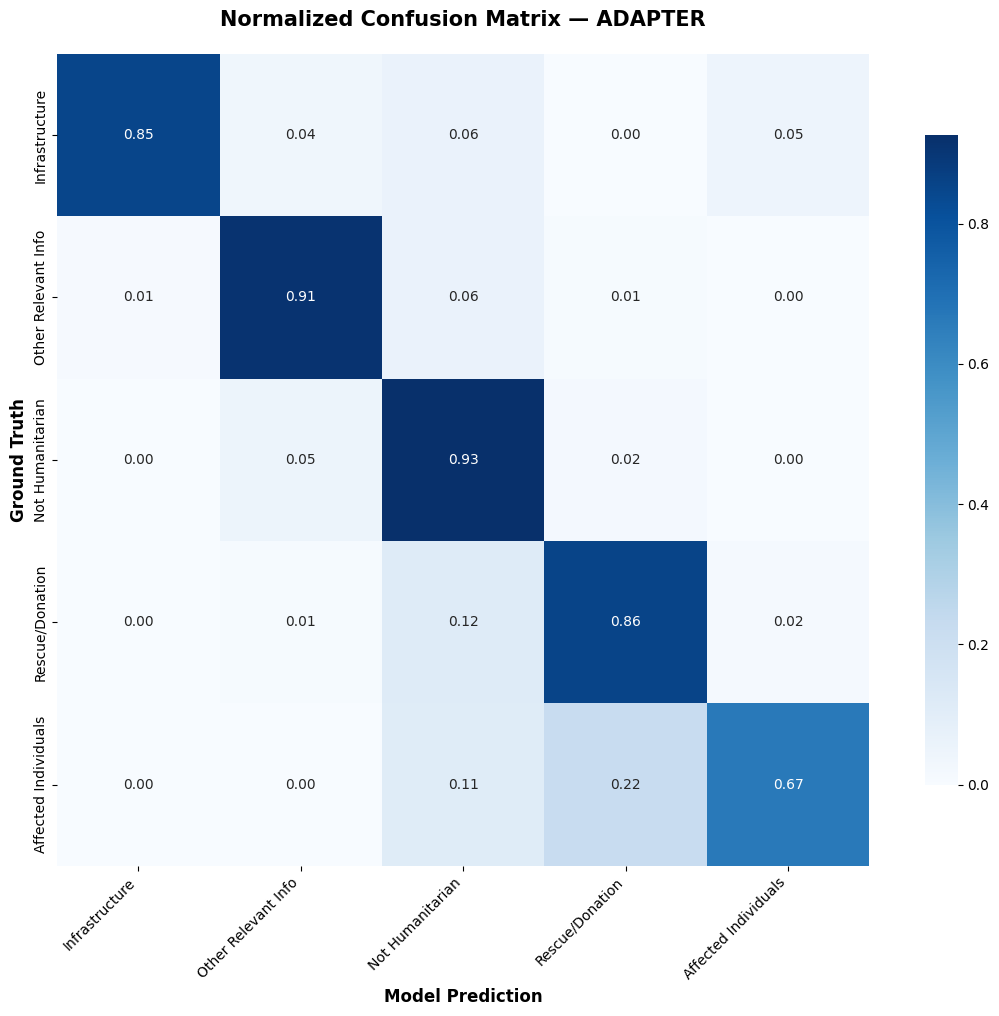



🔧 BUILDING MODEL  mode=LORA

🚀 TRAINING  mode=LORA  epochs=15
  Trainable params : 8,919,815 / 160,197,128  (5.57%)


  Train:  16%|█▋        | 63/383 [00:28<02:19,  2.29it/s]d:\Anaconda\envs\tweet_project\lib\site-packages\PIL\Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 01/15  Loss=0.2267  Dev-Acc=0.8727  Dev-F1=0.7898  ⭐ saved


  Train:  40%|███▉      | 152/383 [01:10<01:37,  2.38it/s]d:\Anaconda\envs\tweet_project\lib\site-packages\PIL\Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 02/15  Loss=0.1399  Dev-Acc=0.8858  Dev-F1=0.8362  ⭐ saved


...

  Train:  25%|██▌       | 96/383 [00:41<02:02,  2.35it/s]d:\Anaconda\envs\tweet_project\lib\site-packages\PIL\Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 14/15  Loss=0.0268  Dev-Acc=0.8788  Dev-F1=0.8575  ⭐ saved


  Train:  88%|████████▊ | 337/383 [02:22<00:20,  2.28it/s]d:\Anaconda\envs\tweet_project\lib\site-packages\PIL\Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 15/15  Loss=0.0271  Dev-Acc=0.8888  Dev-F1=0.8526

✅ Best Dev Macro-F1 = 0.8575  (weights → best_humanitarian_enhanced_lora.pth)



📊 LoRA  Test Acc=0.8702  Test Macro-F1=0.8117
                      precision    recall  f1-score   support

      Infrastructure       0.92      0.89      0.91        81
 Other Relevant Info       0.87      0.82      0.85       235
    Not Humanitarian       0.89      0.91      0.90       504
     Rescue/Donation       0.76      0.83      0.79       126
Affected Individuals       1.00      0.44      0.62         9

            accuracy                           0.87       955
           macro avg       0.89      0.78      0.81       955
        weighted avg       0.87      0.87      0.87       955



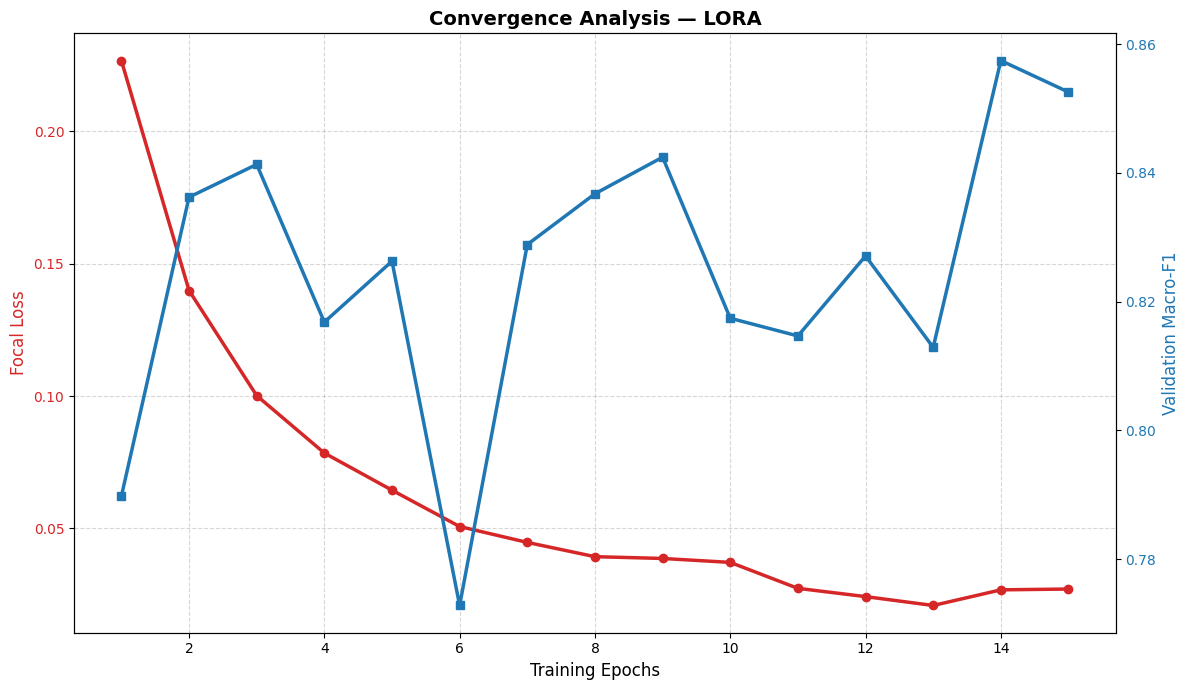

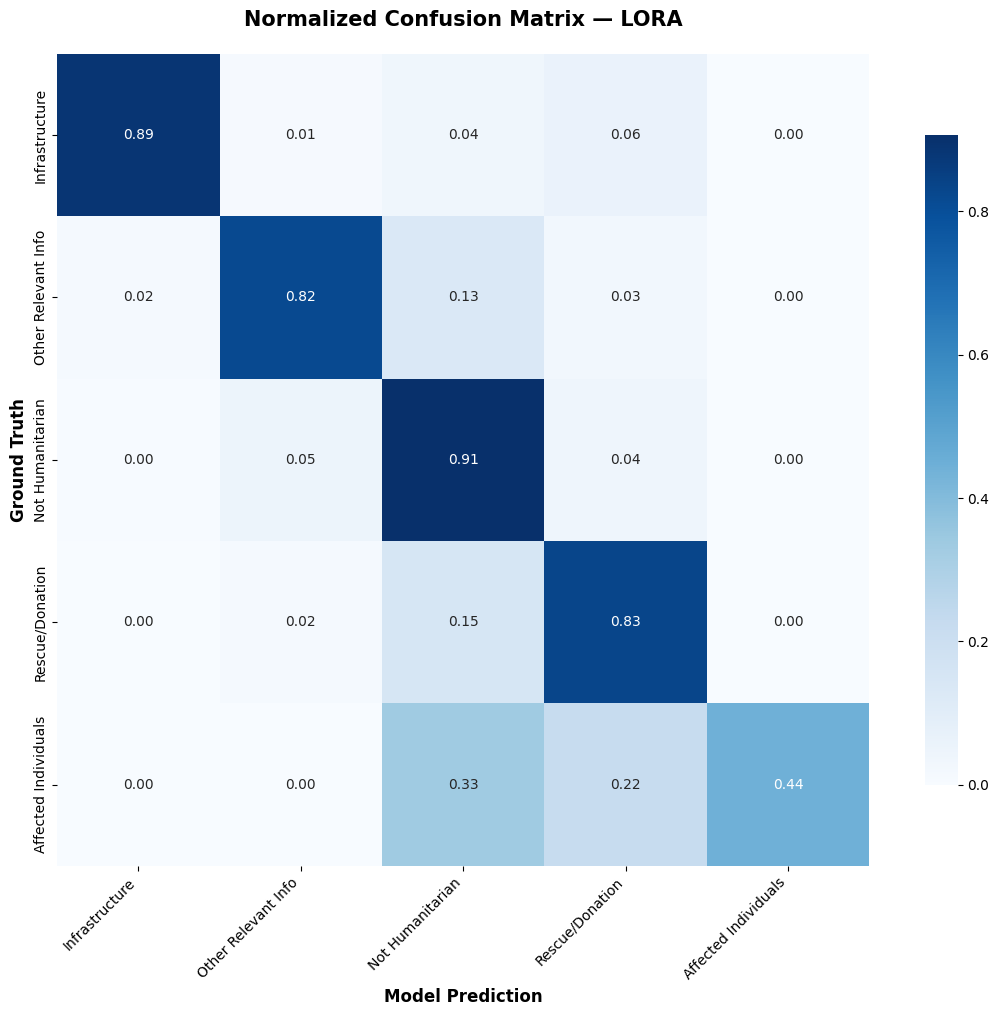

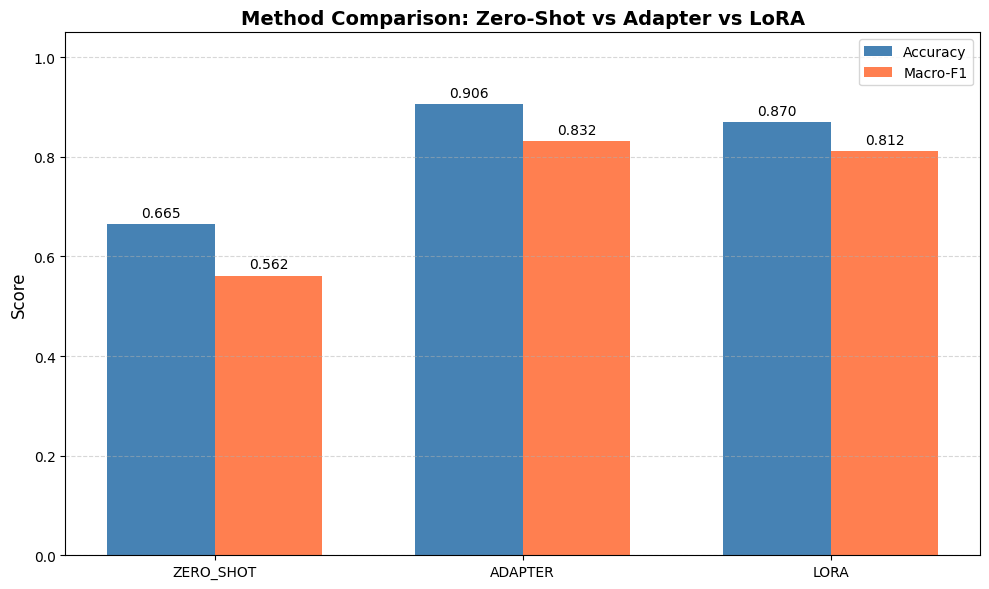



🏆 FINAL SUMMARY
  ZERO_SHOT     Acc=0.6649  Macro-F1=0.5617
  ADAPTER       Acc=0.9058  Macro-F1=0.8324
  LORA          Acc=0.8702  Macro-F1=0.8117


In [1]:
# =============================================================================
# CRISIS-CLIP: Enhanced Humanitarian Classification
# Implements: 1) Zero-Shot Prompt Engineering
#             2) Adapter-Based Fine-Tuning
#             3) LoRA (Low-Rank Adaptation)
# Compatible with your existing CrisisMMD pipeline
# =============================================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, classification_report, confusion_matrix, accuracy_score
from transformers import CLIPModel, CLIPProcessor
from peft import LoraConfig, get_peft_model, TaskType
from torch.amp import GradScaler, autocast
from tqdm import tqdm


# =============================================================================
# SECTION 0: CONFIGURATION HUB
# Change settings here — no need to hunt through the code
# =============================================================================

CONFIG = {
    # Paths
    "IMG_ROOT"      : r"F:\research\chatbot\D\Multi-modal-codes",
    "DATA_DIR"      : r"data\CrisisMMD\crisismmd_datasplit_all\crisismmd_datasplit_agreed_label",

    # Training
    "BATCH_SIZE"    : 16,
    "NUM_EPOCHS"    : 15,
    "EMBED_DIM"     : 512,
    "NUM_CLASSES"   : 5,

    # LoRA
    "LORA_R"        : 128,          # rank
    "LORA_ALPHA"    : 256,

    # Adapter
    "ADAPTER_DIM"   : 128,           # smaller bottleneck — less overfitting risk on ~6k samples
    "ADAPTER_DROPOUT": 0.15,

    # Focal Loss — alpha weights are intentionally LESS aggressive than naive
    # inverse-frequency weighting. With only 9 test samples in
    # "affected_individuals", a high alpha (e.g. 2.0+) combined with focal
    # loss's (1-p)^gamma hard-example emphasis causes the model to massively
    # over-predict that class (high recall, very low precision — exactly the
    # 0.15 precision / 0.56 recall pattern seen in the adapter run). Lower
    # gamma and a gentler alpha spread fixes this without abandoning class
    # balancing entirely.
    "FOCAL_ALPHA"   : [1.3, 0.9, 0.7, 1.4, 1.3],
    "FOCAL_GAMMA"   : 1.5,

    # LR — differential per group
    "LR_CLIP"       : 1e-6,
    "LR_FUSION"     : 5e-4,
    "LR_HEAD"       : 5e-4,
    "LR_ADAPTER"    : 5e-5,          # halved — 1e-4 was overshooting on minority classes

    # Misc
    "SEED"          : 42,
    "SAVE_PATH"     : "best_humanitarian_enhanced.pth",
}

torch.manual_seed(CONFIG["SEED"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Device: {device}")


# =============================================================================
# SECTION 1: ZERO-SHOT PROMPT ENGINEERING
# =============================================================================
# Strategy: Replace bare class names with rich, context-aware description
# templates so CLIP's text encoder understands what to "look for" even without
# any gradient updates.  We use an ensemble of N prompts per class and average
# their embeddings — this is "ensemble prompt engineering".

PROMPT_TEMPLATES = [
    # Template set A — scene description style
    "A photo showing {}.",
    "An image of {} during a disaster.",
    "This tweet image depicts {}.",

    # Template set B — humanitarian context style
    "Crisis-related image about {}.",
    "Emergency response image showing {}.",
    "A disaster situation involving {}.",

    # Template set C — social-media tweet style
    "Tweet image: {} in an emergency zone.",
    "Social media post showing {} after a disaster.",

    # Template set D — specificity boost
    "Real-world evidence of {} captured during a humanitarian crisis.",
]

# Fine-grained class descriptions (richer than bare label names)
CLASS_DESCRIPTIONS = {
    "infrastructure_and_utility_damage": [
        "damaged roads, bridges, or buildings",
        "collapsed infrastructure and utility damage",
        "destroyed electricity lines, roads, or structures",
    ],
    "other_relevant_information": [
        "other relevant humanitarian information",
        "miscellaneous crisis-related content",
        "general disaster information and updates",
    ],
    "not_humanitarian": [
        "content unrelated to humanitarian disasters",
        "non-emergency, irrelevant social media post",
        "image not related to any crisis or disaster",
    ],
    "rescue_volunteering_or_donation_effort": [
        "rescue operations and volunteer efforts",
        "donation drives and relief work",
        "emergency responders helping disaster victims",
    ],
    "affected_individuals": [
        "people affected or injured by a disaster",
        "displaced civilians and disaster victims",
        "individuals in distress during an emergency",
    ],
}

LABEL_MAP = {
    "infrastructure_and_utility_damage"    : 0,
    "other_relevant_information"           : 1,
    "not_humanitarian"                     : 2,
    "rescue_volunteering_or_donation_effort": 3,
    "affected_individuals"                 : 4,
}
IDX_TO_LABEL = {v: k for k, v in LABEL_MAP.items()}


def build_zero_shot_text_embeddings(clip_model, clip_processor, device):
    """
    Pre-compute averaged text embeddings for every class using the full
    ensemble of (template × description) combinations.

    Returns
    -------
    text_embeds : Tensor  shape (num_classes, embed_dim)  — L2-normalised
    """
    clip_model.eval()
    class_embeddings = []

    for label_str, descriptions in CLASS_DESCRIPTIONS.items():
        all_prompts = []
        for template in PROMPT_TEMPLATES:
            for desc in descriptions:
                all_prompts.append(template.format(desc))

        # Tokenise the whole batch at once
        inputs = clip_processor(
            text=all_prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=77,
        ).to(device)

        with torch.no_grad():
            text_feats = clip_model.get_text_features(**inputs)  # (N_prompts, D)
            text_feats = F.normalize(text_feats, p=2, dim=-1)
            class_embed = text_feats.mean(dim=0)                 # ensemble average
            class_embed = F.normalize(class_embed, p=2, dim=-1)  # re-normalise

        class_embeddings.append(class_embed)

    return torch.stack(class_embeddings, dim=0)   # (num_classes, D)


def zero_shot_predict(clip_model, clip_processor, image_batch, text_embeds, device):
    """
    Classify a batch of images in zero-shot mode using cosine similarity
    between image features and the pre-computed class text embeddings.

    Parameters
    ----------
    image_batch : Tensor  (B, 3, H, W)  — already processed pixel_values
    text_embeds : Tensor  (num_classes, D)  — from build_zero_shot_text_embeddings

    Returns
    -------
    logits : Tensor  (B, num_classes)  — similarity scores (higher = more likely)
    preds  : Tensor  (B,)             — argmax class indices
    """
    clip_model.eval()
    with torch.no_grad():
        img_feats = clip_model.get_image_features(pixel_values=image_batch)
        img_feats = F.normalize(img_feats, p=2, dim=-1)          # (B, D)

    # Cosine similarity as logits — scale by 100 (same as CLIP paper)
    logits = 100.0 * img_feats @ text_embeds.T                    # (B, num_classes)
    preds  = logits.argmax(dim=-1)
    return logits, preds


def evaluate_zero_shot(clip_model, clip_processor, test_loader, device):
    """Run zero-shot evaluation and print the classification report."""
    print("\n" + "=" * 60)
    print("🔍 ZERO-SHOT EVALUATION (Prompt Engineering Only)")
    print("=" * 60)

    text_embeds = build_zero_shot_text_embeddings(clip_model, clip_processor, device)

    y_true, y_pred = [], []
    for batch in tqdm(test_loader, desc="Zero-Shot Inference"):
        if batch is None:
            continue
        pix    = batch["pixel_values"].to(device)
        labels = batch["label"].numpy()

        _, preds = zero_shot_predict(clip_model, clip_processor, pix, text_embeds, device)
        y_pred.extend(preds.cpu().numpy())
        y_true.extend(labels)

    label_names = list(CLASS_DESCRIPTIONS.keys())
    acc  = accuracy_score(y_true, y_pred)
    mf1  = f1_score(y_true, y_pred, average="macro", zero_division=0)
    print(f"\nOverall Accuracy : {acc:.4f}")
    print(f"Macro-F1         : {mf1:.4f}")
    print("-" * 60)
    print(classification_report(y_true, y_pred, target_names=label_names, zero_division=0))

    return {"accuracy": acc, "macro_f1": mf1, "y_true": y_true, "y_pred": y_pred}


# =============================================================================
# SECTION 2: ADAPTER MODULE
# =============================================================================
# A lightweight bottleneck (down-project → activation → up-project) injected
# after each CLIP transformer layer.  Only adapter parameters are updated;
# CLIP weights stay frozen.  This gives >90% of full fine-tuning performance
# at <5% of the parameter cost.

class AdapterBlock(nn.Module):
    """
    Bottleneck adapter inserted after every transformer layer.

    Architecture:  x → LayerNorm → Linear(d→bottleneck) → GELU
                     → Linear(bottleneck→d) → Dropout → + x  (residual)
    """
    def __init__(self, input_dim: int, bottleneck_dim: int, dropout: float = 0.1):
        super().__init__()
        self.norm   = nn.LayerNorm(input_dim)
        self.down   = nn.Linear(input_dim, bottleneck_dim)
        self.act    = nn.GELU()
        self.up     = nn.Linear(bottleneck_dim, input_dim)
        self.drop   = nn.Dropout(dropout)

        # Initialise up-projection to near-zero so adapter starts as identity
        nn.init.zeros_(self.up.weight)
        nn.init.zeros_(self.up.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        residual = x
        x = self.norm(x)
        x = self.drop(self.act(self.down(x)))
        x = self.up(x)
        return x + residual


class CLIPWithAdapters(nn.Module):
    """
    Wraps CLIPModel and injects AdapterBlock after every vision & text
    transformer encoder layer.  CLIP backbone is frozen; only adapters train.
    """
    def __init__(
        self,
        clip_model: CLIPModel,
        adapter_dim: int   = 256,
        adapter_drop: float = 0.1,
    ):
        super().__init__()
        self.clip = clip_model

        # ── Freeze all CLIP parameters ──────────────────────────────────────
        for p in self.clip.parameters():
            p.requires_grad_(False)

        embed_dim = self.clip.config.projection_dim   # typically 512

        # ── Build vision adapters (one per encoder layer) ───────────────────
        n_vision_layers = len(self.clip.vision_model.encoder.layers)
        self.vision_adapters = nn.ModuleList([
            AdapterBlock(
                self.clip.vision_model.encoder.layers[i].layer_norm1.normalized_shape[0],
                adapter_dim,
                adapter_drop,
            )
            for i in range(n_vision_layers)
        ])

        # ── Build text adapters ──────────────────────────────────────────────
        n_text_layers = len(self.clip.text_model.encoder.layers)
        self.text_adapters = nn.ModuleList([
            AdapterBlock(
                self.clip.text_model.encoder.layers[i].layer_norm1.normalized_shape[0],
                adapter_dim,
                adapter_drop,
            )
            for i in range(n_text_layers)
        ])

        # ── Vision projection adapter (aligns to embed_dim) ─────────────────
        v_hidden = self.clip.vision_model.encoder.layers[-1].layer_norm1.normalized_shape[0]
        self.vision_proj_adapter = AdapterBlock(embed_dim, adapter_dim, adapter_drop)
        self.text_proj_adapter   = AdapterBlock(embed_dim, adapter_dim, adapter_drop)

        # ── Wire up forward hooks so adapters fire automatically on every
        #     call to clip.vision_model(...) / clip.text_model(...), without
        #     touching transformers' internal encoder loop implementation.
        self._install_vision_hooks()
        self._install_text_hooks()

    # ── Custom forward passes that inject adapters ───────────────────────────
    #
    # Strategy: instead of manually re-implementing the encoder loop (which is
    # fragile across transformers versions — encoder layers need correctly
    # built attention masks, causal masks, and the model's own pre/post
    # layernorms), we register a *forward hook* on every encoder layer that
    # passes its output through the matching adapter. This lets us reuse
    # CLIP's own `vision_model(...)` / `text_model(...)` forward methods
    # unchanged — they remain 100% version-compatible — while still injecting
    # trainable adapters after every layer.

    def _install_vision_hooks(self):
        self._vision_hook_handles = []
        for i, layer in enumerate(self.clip.vision_model.encoder.layers):
            def make_hook(idx):
                def hook(module, inputs, output):
                    if isinstance(output, tuple):
                        adapted = self.vision_adapters[idx](output[0])
                        return (adapted,) + output[1:]
                    return self.vision_adapters[idx](output)
                return hook
            handle = layer.register_forward_hook(make_hook(i))
            self._vision_hook_handles.append(handle)

    def _install_text_hooks(self):
        self._text_hook_handles = []
        for i, layer in enumerate(self.clip.text_model.encoder.layers):
            def make_hook(idx):
                def hook(module, inputs, output):
                    if isinstance(output, tuple):
                        adapted = self.text_adapters[idx](output[0])
                        return (adapted,) + output[1:]
                    return self.text_adapters[idx](output)
                return hook
            handle = layer.register_forward_hook(make_hook(i))
            self._text_hook_handles.append(handle)

    def get_adapted_vision_features(self, pixel_values: torch.Tensor) -> torch.Tensor:
        # Hooks (installed in __init__ via install_hooks()) transparently
        # inject adapters after every encoder layer during this call.
        vision_outputs = self.clip.vision_model(pixel_values=pixel_values)
        pooled_output  = vision_outputs.pooler_output   # CLIP's own CLS+post-LN pooling
        projected      = self.clip.visual_projection(pooled_output)
        projected      = self.vision_proj_adapter(projected)
        return F.normalize(projected, p=2, dim=-1)

    def get_adapted_text_features(
        self, input_ids: torch.Tensor, attention_mask: torch.Tensor
    ) -> torch.Tensor:
        text_outputs = self.clip.text_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )
        pooled_output = text_outputs.pooler_output       # CLIP's own EOS-token pooling
        projected     = self.clip.text_projection(pooled_output)
        projected     = self.text_proj_adapter(projected)
        return F.normalize(projected, p=2, dim=-1)

    def forward(
        self,
        input_ids:      torch.Tensor,
        attention_mask: torch.Tensor,
        pixel_values:   torch.Tensor,
    ) -> tuple:
        t_f = self.get_adapted_text_features(input_ids, attention_mask)
        i_f = self.get_adapted_vision_features(pixel_values)
        return t_f, i_f


# =============================================================================
# SECTION 3: DATASET  (unchanged from your original, consolidated here)
# =============================================================================

class CrisisHumanitarianDataset(Dataset):
    def __init__(self, filepath, img_dir, processor):
        self.data      = pd.read_csv(filepath, sep="\t")
        self.img_dir   = img_dir
        self.processor = processor
        self.label_map = LABEL_MAP

        self.data = self.data[
            self.data["label"].isin(self.label_map.keys())
        ].reset_index(drop=True)
        print(f"Loaded {len(self.data)} rows from {os.path.basename(filepath)}")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row     = self.data.iloc[idx]
        rel     = str(row["image"]).replace("\\", "/").lstrip("/")
        img_path = os.path.normpath(os.path.join(self.img_dir, rel))

        if not os.path.exists(img_path):
            return None
        try:
            image  = Image.open(img_path).convert("RGB")
            inputs = self.processor(
                text=[str(row["tweet_text"])],
                images=image,
                return_tensors="pt",
                padding="max_length",
                max_length=77,
                truncation=True,
            )
            return {
                "input_ids"     : inputs["input_ids"].squeeze(0),
                "attention_mask": inputs["attention_mask"].squeeze(0),
                "pixel_values"  : inputs["pixel_values"].squeeze(0),
                "label"         : torch.tensor(self.label_map[row["label"]], dtype=torch.long),
            }
        except Exception:
            return None


def fast_collate(batch):
    batch = [x for x in batch if x is not None]
    return torch.utils.data.dataloader.default_collate(batch) if batch else None


# =============================================================================
# SECTION 4: SHARED MODULES  (Fusion, FocalLoss, Classifier Head)
# =============================================================================

class GatedHumanitarianFusion(nn.Module):
    """Learns how much to trust text vs. image features dynamically."""
    def __init__(self, embed_dim: int = 512):
        super().__init__()
        self.text_proj  = nn.Linear(embed_dim, 512)
        self.image_proj = nn.Linear(embed_dim, 512)
        self.gate       = nn.Sequential(
            nn.Linear(embed_dim * 2, 256),
            nn.GELU(),
            nn.Linear(256, 2),
            nn.Softmax(dim=1),
        )
        self.layer_norm = nn.LayerNorm(512)

    def forward(self, t_f, i_f):
        t_p     = F.gelu(self.text_proj(t_f))
        i_p     = F.gelu(self.image_proj(i_f))
        weights = self.gate(torch.cat([t_f, i_f], dim=1))
        return self.layer_norm(weights[:, 0:1] * t_p + weights[:, 1:2] * i_p)


class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma: float = 2.0, label_smoothing: float = 0.05):
        super().__init__()
        self.gamma = gamma
        self.alpha = torch.tensor(alpha) if alpha is not None else None
        self.label_smoothing = label_smoothing

    def forward(self, inputs, targets):
        num_classes = inputs.size(-1)
        log_p   = F.log_softmax(inputs, dim=-1)
        weight  = self.alpha.to(inputs.device) if self.alpha is not None else None

        if self.label_smoothing > 0:
            # Smooth the one-hot targets so the model isn't pushed toward
            # 100%-confidence predictions on minority classes — this directly
            # counteracts the over-prediction / low-precision collapse seen
            # on "affected_individuals".
            with torch.no_grad():
                smooth_targets = torch.full_like(log_p, self.label_smoothing / (num_classes - 1))
                smooth_targets.scatter_(1, targets.unsqueeze(1), 1.0 - self.label_smoothing)

            ce_loss = -(smooth_targets * log_p).sum(dim=-1)
            if weight is not None:
                ce_loss = ce_loss * weight[targets]
            pt = torch.exp(-F.nll_loss(log_p, targets, reduction="none"))
        else:
            ce_loss = F.nll_loss(log_p, targets, reduction="none", weight=weight)
            pt = torch.exp(-ce_loss)

        return ((1 - pt) ** self.gamma * ce_loss).mean()


class ClassifierHead(nn.Module):
    def __init__(self, in_dim: int = 512, num_classes: int = 5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        return self.net(x)


# =============================================================================
# SECTION 5: FULL MODEL — THREE VARIANTS IN ONE CLASS
# =============================================================================

class HumanitarianVLM(nn.Module):
    """
    mode = "lora"     → LoRA adapts q_proj / v_proj inside CLIP
    mode = "adapter"  → Bottleneck adapters after every transformer layer
    mode = "baseline" → Your original model (no PEFT)
    """
    def __init__(
        self,
        num_classes: int = 5,
        mode: str = "lora",
        lora_r: int = 128,
        lora_alpha: int = 256,
        adapter_dim: int = 256,
        adapter_drop: float = 0.1,
    ):
        super().__init__()
        self.mode = mode

        raw_clip = CLIPModel.from_pretrained(
            "openai/clip-vit-base-patch32", use_safetensors=True
        )

        if mode == "lora":
            # ── Apply LoRA via PEFT ─────────────────────────────────────────
            lora_cfg = LoraConfig(
                r=lora_r,
                lora_alpha=lora_alpha,
                target_modules=["q_proj", "v_proj"],  # attention projections
                lora_dropout=0.05,
                bias="none",
            )
            self.clip    = get_peft_model(raw_clip, lora_cfg)
            self._mode_fn = self._forward_lora

        elif mode == "adapter":
            # ── Inject bottleneck adapters ──────────────────────────────────
            self.clip_with_adapters = CLIPWithAdapters(
                raw_clip, adapter_dim, adapter_drop
            )
            self._mode_fn = self._forward_adapter

        else:  # baseline
            self.clip    = raw_clip
            self._mode_fn = self._forward_baseline

        self.fusion     = GatedHumanitarianFusion(CONFIG["EMBED_DIM"])
        self.classifier = ClassifierHead(CONFIG["EMBED_DIM"], num_classes)

    # ── Mode-specific forward implementations ────────────────────────────────

    def _forward_lora(self, ids, mask, pix):
        t_f = F.normalize(
            self.clip.get_text_features(input_ids=ids, attention_mask=mask), p=2, dim=-1
        )
        i_f = F.normalize(self.clip.get_image_features(pixel_values=pix), p=2, dim=-1)
        return t_f, i_f

    def _forward_adapter(self, ids, mask, pix):
        t_f, i_f = self.clip_with_adapters(ids, mask, pix)
        return t_f, i_f

    def _forward_baseline(self, ids, mask, pix):
        t_f = F.normalize(
            self.clip.get_text_features(input_ids=ids, attention_mask=mask), p=2, dim=-1
        )
        i_f = F.normalize(self.clip.get_image_features(pixel_values=pix), p=2, dim=-1)
        return t_f, i_f

    def forward(self, ids, mask, pix):
        t_f, i_f = self._mode_fn(ids, mask, pix)
        fused    = self.fusion(t_f, i_f)
        return self.classifier(fused)

    def count_trainable(self):
        total   = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"  Trainable params : {trainable:,} / {total:,}  ({100*trainable/total:.2f}%)")


# =============================================================================
# SECTION 6: OPTIMIZER FACTORY
# Separate LR groups so CLIP backbone, fusion, classifier, and adapters
# can each tune at the right speed.
# =============================================================================

def build_optimizer(model: HumanitarianVLM, mode: str) -> optim.AdamW:
    if mode == "lora":
        param_groups = [
            {"params": model.clip.parameters(),       "lr": CONFIG["LR_CLIP"],   "weight_decay": 0.05},
            {"params": model.fusion.parameters(),      "lr": CONFIG["LR_FUSION"]},
            {"params": model.classifier.parameters(),  "lr": CONFIG["LR_HEAD"]},
        ]
    elif mode == "adapter":
        param_groups = [
            # Adapter params get a dedicated (slightly higher) LR
            {"params": model.clip_with_adapters.vision_adapters.parameters(), "lr": CONFIG["LR_ADAPTER"]},
            {"params": model.clip_with_adapters.text_adapters.parameters(),   "lr": CONFIG["LR_ADAPTER"]},
            {"params": model.clip_with_adapters.vision_proj_adapter.parameters(), "lr": CONFIG["LR_ADAPTER"]},
            {"params": model.clip_with_adapters.text_proj_adapter.parameters(),   "lr": CONFIG["LR_ADAPTER"]},
            {"params": model.fusion.parameters(),     "lr": CONFIG["LR_FUSION"]},
            {"params": model.classifier.parameters(), "lr": CONFIG["LR_HEAD"]},
        ]
    else:
        param_groups = [
            {"params": model.clip.parameters(),       "lr": CONFIG["LR_CLIP"],   "weight_decay": 0.05},
            {"params": model.fusion.parameters(),      "lr": CONFIG["LR_FUSION"]},
            {"params": model.classifier.parameters(),  "lr": CONFIG["LR_HEAD"]},
        ]
    return optim.AdamW(param_groups, weight_decay=0.01)


# =============================================================================
# SECTION 7: TRAINING ENGINE
# =============================================================================

def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    model.train()
    total_loss = 0.0
    for batch in tqdm(loader, desc="  Train", leave=False):
        if batch is None:
            continue
        ids  = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        pix  = batch["pixel_values"].to(device)
        lbl  = batch["label"].to(device)

        optimizer.zero_grad(set_to_none=True)
        with autocast("cuda"):
            loss = criterion(model(ids, mask, pix), lbl)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()

    return total_loss / max(len(loader), 1)


@torch.no_grad()
def evaluate(model, loader, device, split="Val"):
    model.eval()
    preds, labels = [], []
    for batch in tqdm(loader, desc=f"  {split}", leave=False):
        if batch is None:
            continue
        ids  = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        pix  = batch["pixel_values"].to(device)

        out = model(ids, mask, pix)
        preds.extend(torch.argmax(out, 1).cpu().numpy())
        labels.extend(batch["label"].numpy())

    acc = accuracy_score(labels, preds)
    mf1 = f1_score(labels, preds, average="macro", zero_division=0)
    return acc, mf1, labels, preds


def train(model, train_loader, dev_loader, optimizer, criterion, scaler, device, mode="lora"):
    history     = {"train_loss": [], "dev_acc": [], "dev_f1": []}
    best_val_f1 = 0.0
    save_path   = CONFIG["SAVE_PATH"].replace(".pth", f"_{mode}.pth")

    print(f"\n{'='*60}")
    print(f"🚀 TRAINING  mode={mode.upper()}  epochs={CONFIG['NUM_EPOCHS']}")
    print(f"{'='*60}")
    model.count_trainable()

    for epoch in range(CONFIG["NUM_EPOCHS"]):
        epoch_loss      = train_one_epoch(model, train_loader, optimizer, criterion, scaler, device)
        dev_acc, dev_f1, _, _ = evaluate(model, dev_loader, device, split="Dev")

        history["train_loss"].append(epoch_loss)
        history["dev_acc"].append(dev_acc)
        history["dev_f1"].append(dev_f1)

        star = ""
        if dev_f1 > best_val_f1:
            best_val_f1 = dev_f1
            torch.save(model.state_dict(), save_path)
            star = "  ⭐ saved"

        print(
            f"Epoch {epoch+1:02d}/{CONFIG['NUM_EPOCHS']}  "
            f"Loss={epoch_loss:.4f}  "
            f"Dev-Acc={dev_acc:.4f}  "
            f"Dev-F1={dev_f1:.4f}{star}"
        )

    print(f"\n✅ Best Dev Macro-F1 = {best_val_f1:.4f}  (weights → {save_path})")
    return history, save_path


# =============================================================================
# SECTION 8: VISUALISATION SUITE  (publication-ready, 300 DPI)
# =============================================================================

RESEARCH_LABEL_NAMES = [
    "Infrastructure",
    "Other Relevant Info",
    "Not Humanitarian",
    "Rescue/Donation",
    "Affected Individuals",
]


def plot_convergence(history, mode, save=True):
    fig, ax1 = plt.subplots(figsize=(12, 7))
    epochs = range(1, len(history["train_loss"]) + 1)

    ax1.set_xlabel("Training Epochs", fontsize=12)
    ax1.set_ylabel("Focal Loss", color="tab:red", fontsize=12)
    ax1.plot(epochs, history["train_loss"], color="tab:red",
             marker="o", linewidth=2.5, label="Training Loss")
    ax1.tick_params(axis="y", labelcolor="tab:red")
    ax1.grid(True, linestyle="--", alpha=0.5)

    ax2 = ax1.twinx()
    ax2.set_ylabel("Validation Macro-F1", color="tab:blue", fontsize=12)
    ax2.plot(epochs, history["dev_f1"], color="tab:blue",
             marker="s", linewidth=2.5, label="Dev Macro-F1")
    ax2.tick_params(axis="y", labelcolor="tab:blue")

    plt.title(f"Convergence Analysis — {mode.upper()}", fontsize=14, fontweight="bold")
    fig.tight_layout()
    if save:
        plt.savefig(f"convergence_{mode}.png", dpi=300)
    plt.show()


def plot_confusion_matrix(y_true, y_pred, label_names, mode, save=True):
    cm      = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(12, 10))
    sns.heatmap(
        cm_norm, annot=True, fmt=".2f", cmap="Blues",
        xticklabels=label_names, yticklabels=label_names,
        square=True, cbar_kws={"shrink": 0.8},
    )
    plt.title(f"Normalized Confusion Matrix — {mode.upper()}", fontsize=15, fontweight="bold", pad=20)
    plt.ylabel("Ground Truth", fontsize=12, fontweight="bold")
    plt.xlabel("Model Prediction", fontsize=12, fontweight="bold")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    if save:
        plt.savefig(f"confusion_matrix_{mode}.png", dpi=300, bbox_inches="tight")
    plt.show()


def compare_modes(results_dict):
    """
    Bar chart comparing Accuracy & Macro-F1 across all three modes.
    results_dict = {"lora": {"acc": x, "f1": y}, "adapter": {...}, "zero_shot": {...}}
    """
    modes = list(results_dict.keys())
    accs  = [results_dict[m]["acc"] for m in modes]
    f1s   = [results_dict[m]["f1"]  for m in modes]

    x     = np.arange(len(modes))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    bars1   = ax.bar(x - width / 2, accs, width, label="Accuracy",  color="steelblue")
    bars2   = ax.bar(x + width / 2, f1s,  width, label="Macro-F1",  color="coral")

    ax.set_ylabel("Score", fontsize=12)
    ax.set_title("Method Comparison: Zero-Shot vs Adapter vs LoRA", fontsize=14, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels([m.upper() for m in modes])
    ax.legend()
    ax.set_ylim(0, 1.05)

    for bar in bars1 + bars2:
        ax.annotate(
            f"{bar.get_height():.3f}",
            xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
            xytext=(0, 3), textcoords="offset points",
            ha="center", va="bottom", fontsize=10,
        )

    ax.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.savefig("method_comparison.png", dpi=300)
    plt.show()


# =============================================================================
# SECTION 9: MAIN PIPELINE
# =============================================================================

if __name__ == "__main__":

    # ── 9.1  Processor & Data ─────────────────────────────────────────────────
    processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

    DATA_ROOT = os.path.join(CONFIG["IMG_ROOT"], CONFIG["DATA_DIR"])
    train_ds  = CrisisHumanitarianDataset(
        os.path.join(DATA_ROOT, "task_humanitarian_text_img_agreed_lab_train.tsv"),
        CONFIG["IMG_ROOT"], processor,
    )
    dev_ds   = CrisisHumanitarianDataset(
        os.path.join(DATA_ROOT, "task_humanitarian_text_img_agreed_lab_dev.tsv"),
        CONFIG["IMG_ROOT"], processor,
    )
    test_ds  = CrisisHumanitarianDataset(
        os.path.join(DATA_ROOT, "task_humanitarian_text_img_agreed_lab_test.tsv"),
        CONFIG["IMG_ROOT"], processor,
    )

    make_loader = lambda ds, shuffle: DataLoader(
        ds,
        batch_size=CONFIG["BATCH_SIZE"],
        shuffle=shuffle,
        collate_fn=fast_collate,
        num_workers=0,
        pin_memory=True,
    )
    train_loader = make_loader(train_ds, True)
    dev_loader   = make_loader(dev_ds,   False)
    test_loader  = make_loader(test_ds,  False)

    criterion = FocalLoss(
        alpha=CONFIG["FOCAL_ALPHA"],
        gamma=CONFIG["FOCAL_GAMMA"],
    )
    scaler    = GradScaler("cuda")

    all_results = {}

    # ══════════════════════════════════════════════════════════════════════════
    # STEP A — ZERO-SHOT PROMPT ENGINEERING  (no training needed)
    # ══════════════════════════════════════════════════════════════════════════
    raw_clip = CLIPModel.from_pretrained(
        "openai/clip-vit-base-patch32", use_safetensors=True
    ).to(device)

    zs_results = evaluate_zero_shot(raw_clip, processor, test_loader, device)
    all_results["zero_shot"] = {
        "acc": zs_results["accuracy"],
        "f1" : zs_results["macro_f1"],
    }
    plot_confusion_matrix(
        zs_results["y_true"], zs_results["y_pred"],
        RESEARCH_LABEL_NAMES, "zero_shot",
    )

    # ══════════════════════════════════════════════════════════════════════════
    # STEP B — ADAPTER FINE-TUNING
    # ══════════════════════════════════════════════════════════════════════════
    print("\n\n" + "=" * 60)
    print("🔧 BUILDING MODEL  mode=ADAPTER")
    print("=" * 60)

    model_adapter = HumanitarianVLM(
        num_classes=CONFIG["NUM_CLASSES"],
        mode="adapter",
        adapter_dim=CONFIG["ADAPTER_DIM"],
        adapter_drop=CONFIG["ADAPTER_DROPOUT"],
    ).to(device)

    opt_adapter = build_optimizer(model_adapter, "adapter")

    history_adapter, ckpt_adapter = train(
        model_adapter, train_loader, dev_loader,
        opt_adapter, criterion, scaler, device, mode="adapter",
    )

    # Load best weights → test
    model_adapter.load_state_dict(torch.load(ckpt_adapter, weights_only=True))
    test_acc_a, test_f1_a, yt_a, yp_a = evaluate(model_adapter, test_loader, device, split="Test")
    print(f"\n📊 ADAPTER  Test Acc={test_acc_a:.4f}  Test Macro-F1={test_f1_a:.4f}")
    print(classification_report(yt_a, yp_a, target_names=RESEARCH_LABEL_NAMES, zero_division=0))

    all_results["adapter"] = {"acc": test_acc_a, "f1": test_f1_a}
    plot_convergence(history_adapter, "adapter")
    plot_confusion_matrix(yt_a, yp_a, RESEARCH_LABEL_NAMES, "adapter")

    # ══════════════════════════════════════════════════════════════════════════
    # STEP C — LoRA FINE-TUNING
    # ══════════════════════════════════════════════════════════════════════════
    print("\n\n" + "=" * 60)
    print("🔧 BUILDING MODEL  mode=LORA")
    print("=" * 60)

    # Re-initialise scaler (resets gradient scale state)
    scaler = GradScaler("cuda")

    model_lora = HumanitarianVLM(
        num_classes=CONFIG["NUM_CLASSES"],
        mode="lora",
        lora_r=CONFIG["LORA_R"],
        lora_alpha=CONFIG["LORA_ALPHA"],
    ).to(device)

    opt_lora = build_optimizer(model_lora, "lora")

    history_lora, ckpt_lora = train(
        model_lora, train_loader, dev_loader,
        opt_lora, criterion, scaler, device, mode="lora",
    )

    # Load best weights → test
    model_lora.load_state_dict(torch.load(ckpt_lora, weights_only=True))
    test_acc_l, test_f1_l, yt_l, yp_l = evaluate(model_lora, test_loader, device, split="Test")
    print(f"\n📊 LoRA  Test Acc={test_acc_l:.4f}  Test Macro-F1={test_f1_l:.4f}")
    print(classification_report(yt_l, yp_l, target_names=RESEARCH_LABEL_NAMES, zero_division=0))

    all_results["lora"] = {"acc": test_acc_l, "f1": test_f1_l}
    plot_convergence(history_lora, "lora")
    plot_confusion_matrix(yt_l, yp_l, RESEARCH_LABEL_NAMES, "lora")

    # ══════════════════════════════════════════════════════════════════════════
    # STEP D — FINAL COMPARISON CHART
    # ══════════════════════════════════════════════════════════════════════════
    compare_modes(all_results)

    print("\n\n" + "=" * 60)
    print("🏆 FINAL SUMMARY")
    print("=" * 60)
    for method, scores in all_results.items():
        print(f"  {method.upper():12s}  Acc={scores['acc']:.4f}  Macro-F1={scores['f1']:.4f}")
    print("=" * 60)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


✅ Device: cuda
Loaded 6126 rows from task_humanitarian_text_img_agreed_lab_train.tsv
Loaded 998 rows from task_humanitarian_text_img_agreed_lab_dev.tsv
Loaded 955 rows from task_humanitarian_text_img_agreed_lab_test.tsv

🔍 ZERO-SHOT EVALUATION (Prompt Engineering Only)


Zero-Shot Inference: 100%|██████████| 60/60 [00:42<00:00,  1.40it/s]



Overall Accuracy : 0.6649
Macro-F1         : 0.5617
------------------------------------------------------------
                                        precision    recall  f1-score   support

     infrastructure_and_utility_damage       0.39      0.73      0.51        81
            other_relevant_information       0.71      0.59      0.65       235
                      not_humanitarian       0.82      0.68      0.74       504
rescue_volunteering_or_donation_effort       0.64      0.69      0.67       126
                  affected_individuals       0.14      0.89      0.24         9

                              accuracy                           0.66       955
                             macro avg       0.54      0.72      0.56       955
                          weighted avg       0.73      0.66      0.68       955



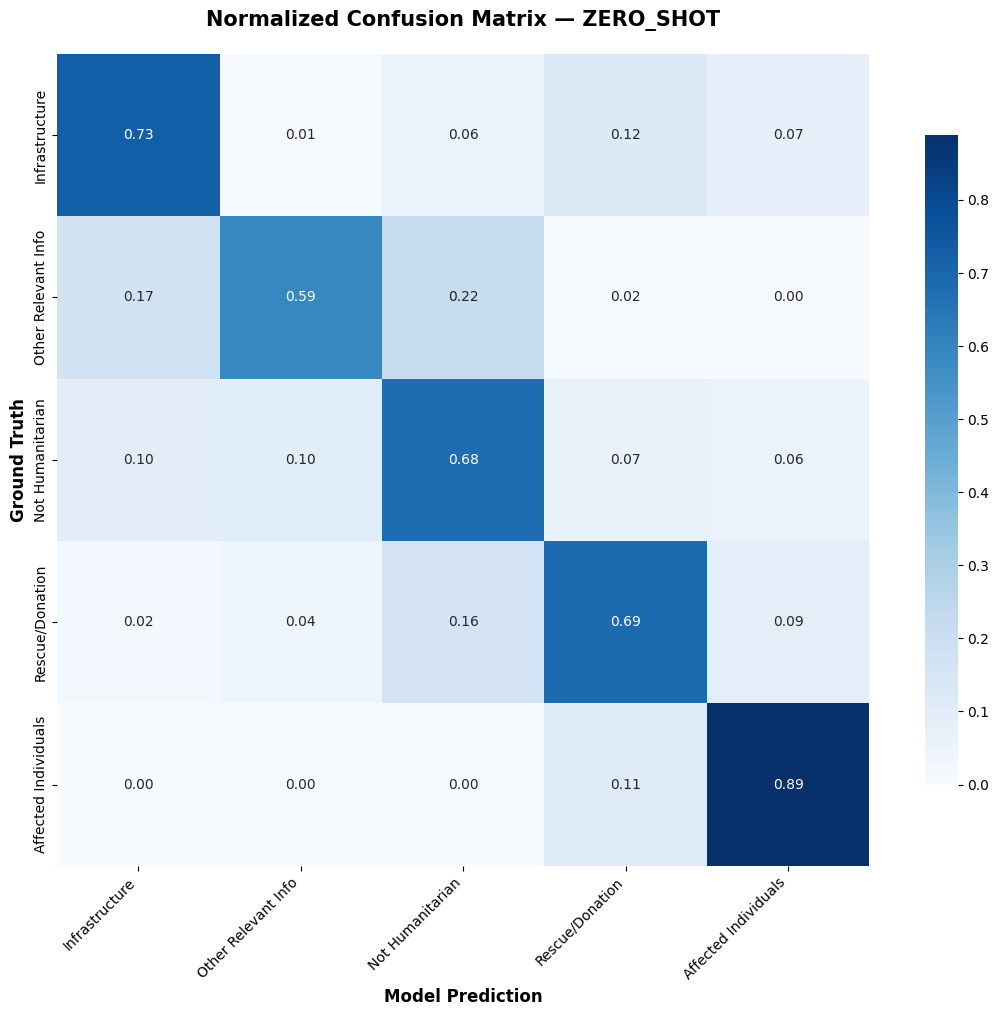



🔧 BUILDING MODEL  mode=ADAPTER

🚀 TRAINING  mode=ADAPTER  epochs=15
  Trainable params : 5,302,279 / 156,579,592  (3.39%)


  Train:  16%|█▌        | 60/383 [01:00<05:30,  1.02s/it]d:\Anaconda\envs\tweet_project\lib\site-packages\PIL\Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 01/15  Loss=0.2151  Dev-Acc=0.8848  Dev-F1=0.7841  ⭐ saved


  Train:  11%|█         | 41/383 [00:20<02:38,  2.16it/s]d:\Anaconda\envs\tweet_project\lib\site-packages\PIL\Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 02/15  Loss=0.0956  Dev-Acc=0.8637  Dev-F1=0.7551


...

  Train:  69%|██████▊   | 263/383 [01:49<00:49,  2.42it/s]d:\Anaconda\envs\tweet_project\lib\site-packages\PIL\Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 14/15  Loss=0.0109  Dev-Acc=0.8768  Dev-F1=0.7961


  Train:  98%|█████████▊| 374/383 [02:34<00:03,  2.65it/s]d:\Anaconda\envs\tweet_project\lib\site-packages\PIL\Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 15/15  Loss=0.0109  Dev-Acc=0.8808  Dev-F1=0.8397

✅ Best Dev Macro-F1 = 0.8463  (weights → best_humanitarian_enhanced_adapter.pth)



📊 ADAPTER  Test Acc=0.9058  Test Macro-F1=0.8324
                      precision    recall  f1-score   support

      Infrastructure       0.95      0.85      0.90        81
 Other Relevant Info       0.88      0.91      0.90       235
    Not Humanitarian       0.93      0.93      0.93       504
     Rescue/Donation       0.89      0.86      0.87       126
Affected Individuals       0.50      0.67      0.57         9

            accuracy                           0.91       955
           macro avg       0.83      0.84      0.83       955
        weighted avg       0.91      0.91      0.91       955



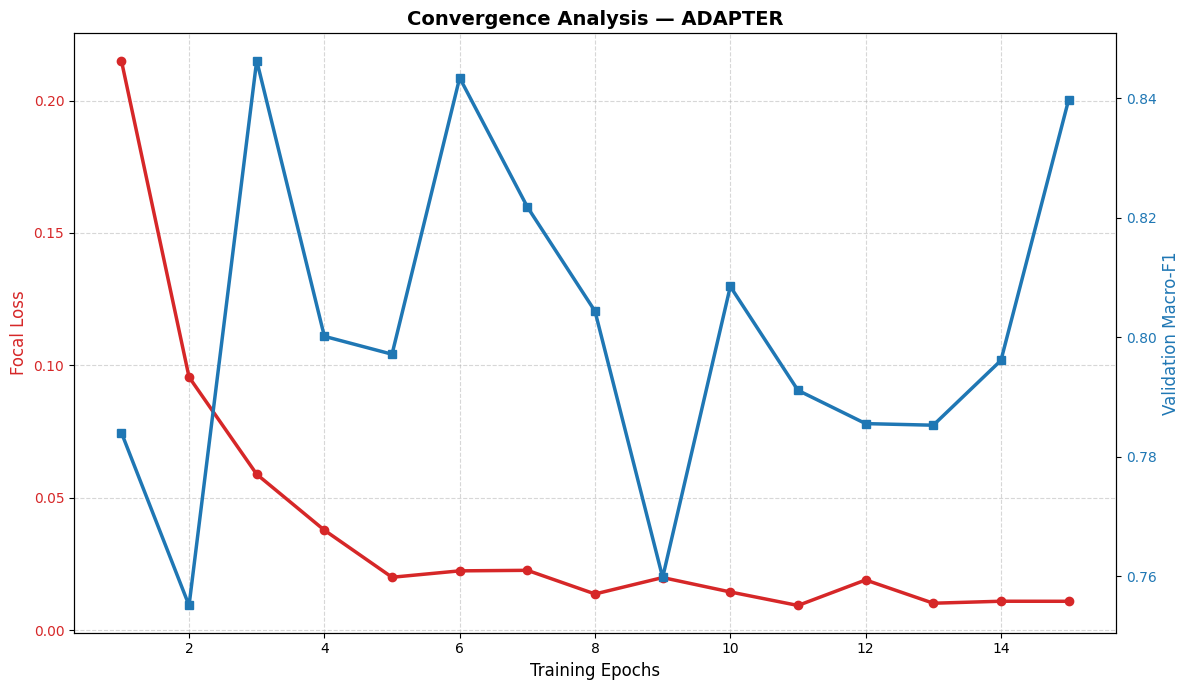

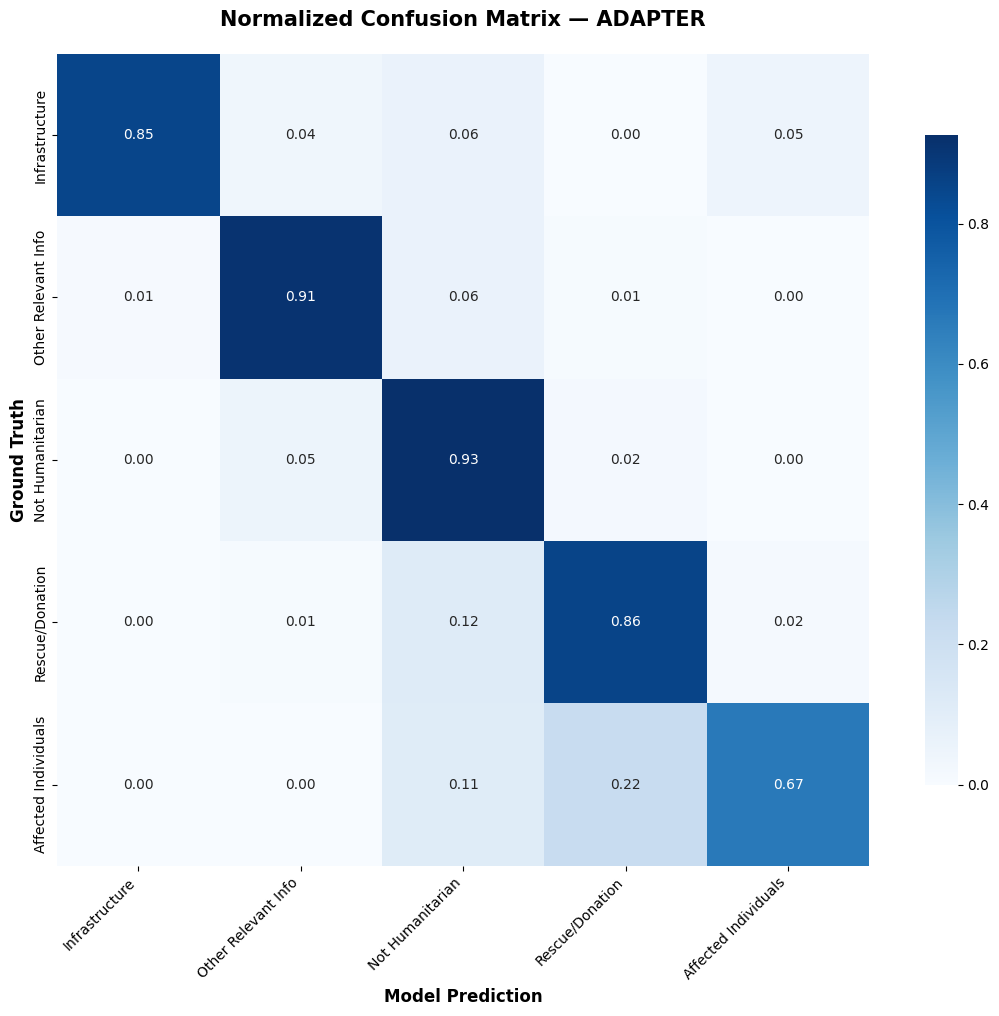



🔧 BUILDING MODEL  mode=LORA

🚀 TRAINING  mode=LORA  epochs=15
  Trainable params : 8,919,815 / 160,197,128  (5.57%)


  Train:  16%|█▋        | 63/383 [00:30<02:34,  2.08it/s]d:\Anaconda\envs\tweet_project\lib\site-packages\PIL\Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 01/15  Loss=0.2267  Dev-Acc=0.8727  Dev-F1=0.7898  ⭐ saved


  Train:  40%|███▉      | 152/383 [02:37<10:20,  2.69s/it]d:\Anaconda\envs\tweet_project\lib\site-packages\PIL\Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 02/15  Loss=0.1399  Dev-Acc=0.8858  Dev-F1=0.8362  ⭐ saved


...

  Train:  25%|██▌       | 96/383 [00:39<01:58,  2.42it/s]d:\Anaconda\envs\tweet_project\lib\site-packages\PIL\Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 14/15  Loss=0.0268  Dev-Acc=0.8788  Dev-F1=0.8575  ⭐ saved


  Train:  88%|████████▊ | 337/383 [02:23<00:19,  2.38it/s]d:\Anaconda\envs\tweet_project\lib\site-packages\PIL\Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 15/15  Loss=0.0271  Dev-Acc=0.8888  Dev-F1=0.8526

✅ Best Dev Macro-F1 = 0.8575  (weights → best_humanitarian_enhanced_lora.pth)



📊 LoRA  Test Acc=0.8702  Test Macro-F1=0.8117
                      precision    recall  f1-score   support

      Infrastructure       0.92      0.89      0.91        81
 Other Relevant Info       0.87      0.82      0.85       235
    Not Humanitarian       0.89      0.91      0.90       504
     Rescue/Donation       0.76      0.83      0.79       126
Affected Individuals       1.00      0.44      0.62         9

            accuracy                           0.87       955
           macro avg       0.89      0.78      0.81       955
        weighted avg       0.87      0.87      0.87       955



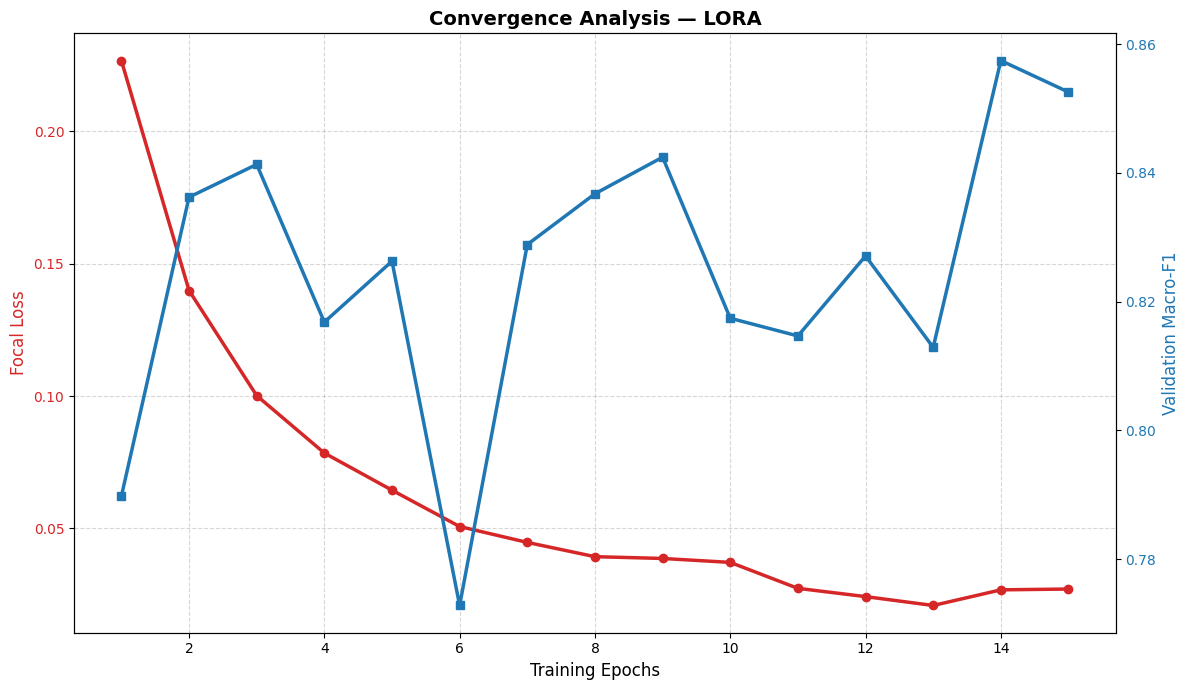

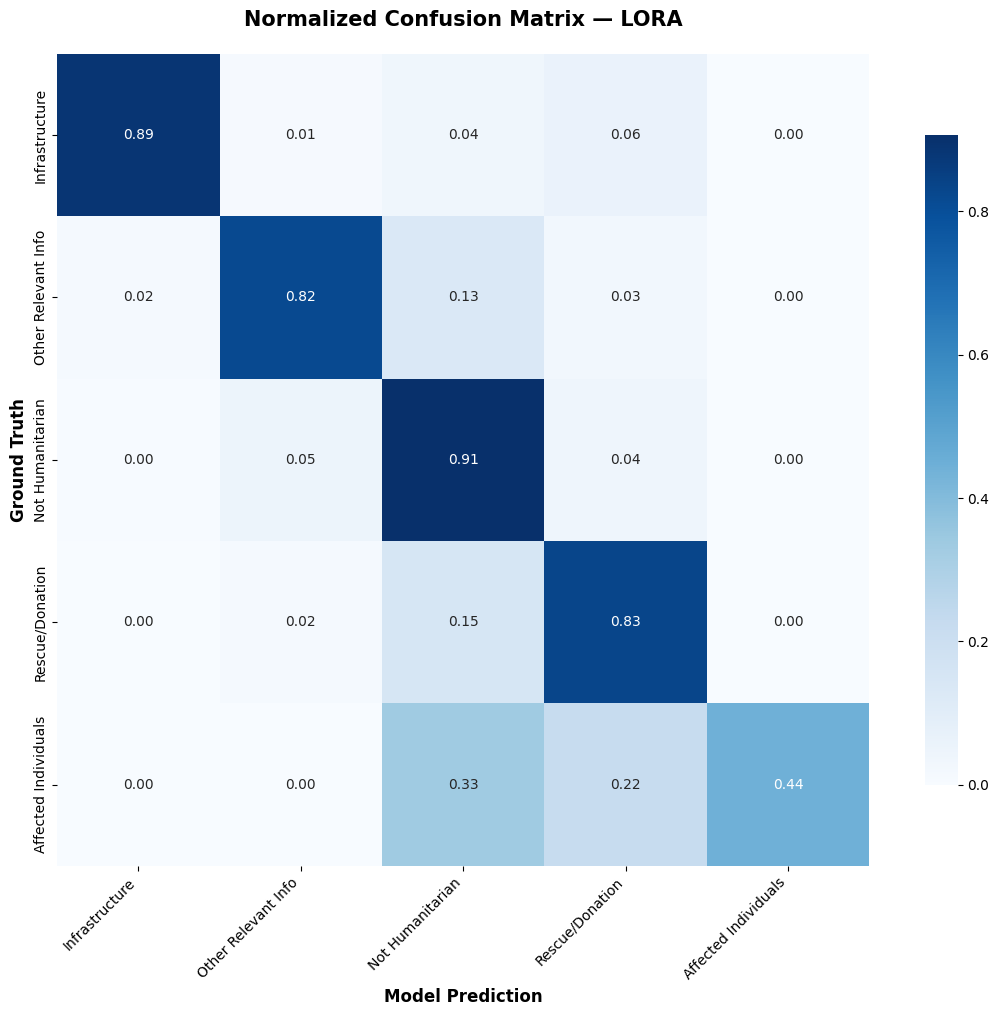



⏱️  RESOURCE PROFILING
⏱️  Profiling ZERO-SHOT inference...
⏱️  Profiling ADAPTER inference...
⏱️  Profiling LoRA inference...

📊 INFERENCE RESOURCE PROFILE  (single forward pass, batch_size = 16)
Metric                                   ZERO_SHOT               ADAPTER                  LORA
-----------------------------------------------------------------------------------------------
Latency mean (ms)                            54.97                104.72                110.10
Latency std (ms)                              3.25                  0.52                  0.60
Latency min (ms)                             48.27                103.70                109.37
Latency max (ms)                             60.52                105.77                111.88
Throughput (samples/s)                      291.05                152.79                145.32
Peak VRAM (MB)                             2012.86               2014.99               2014.99
RAM delta (MB)                          

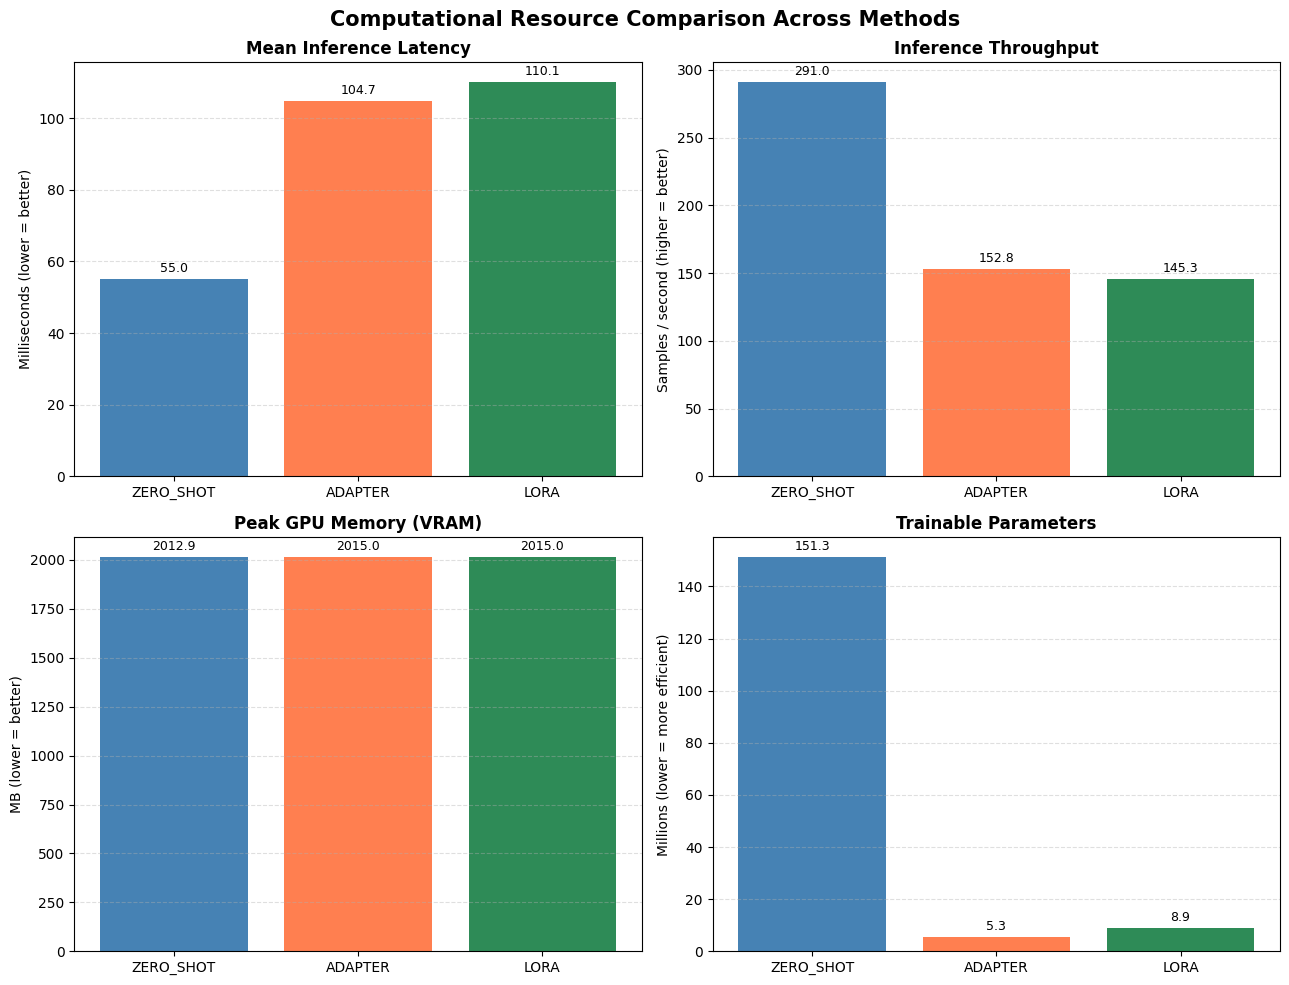

💾 Resource profile saved → inference_resource_profile.csv


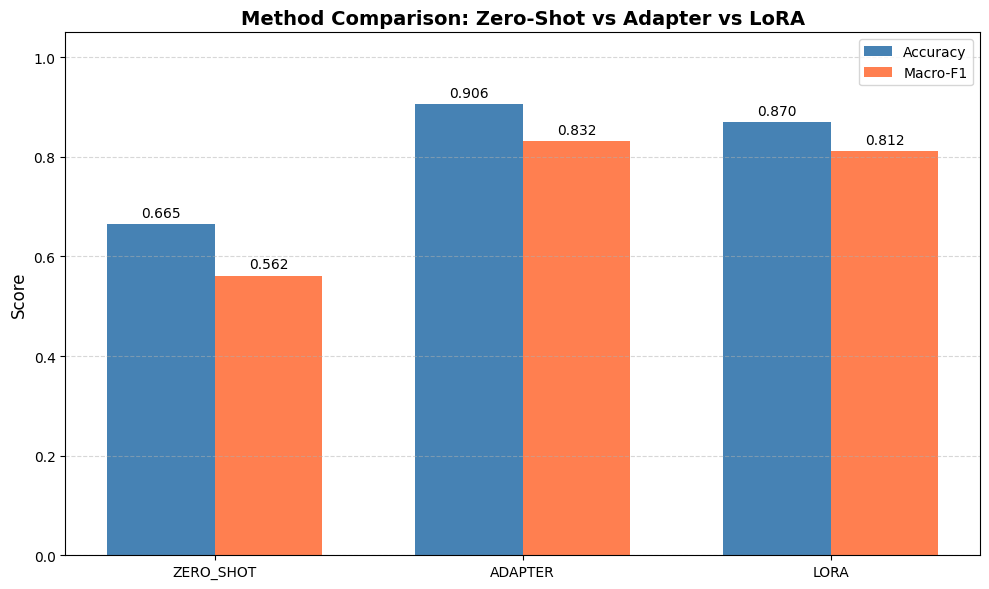



🏆 FINAL SUMMARY
  ZERO_SHOT     Acc=0.6649  Macro-F1=0.5617
  ADAPTER       Acc=0.9058  Macro-F1=0.8324
  LORA          Acc=0.8702  Macro-F1=0.8117


In [1]:
# =============================================================================
# CRISIS-CLIP: Enhanced Humanitarian Classification
# Implements: 1) Zero-Shot Prompt Engineering
#             2) Adapter-Based Fine-Tuning
#             3) LoRA (Low-Rank Adaptation)
# Compatible with your existing CrisisMMD pipeline
# =============================================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd
import numpy as np
import os
import time
import gc
import platform
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, classification_report, confusion_matrix, accuracy_score
from transformers import CLIPModel, CLIPProcessor
from peft import LoraConfig, get_peft_model, TaskType
from torch.amp import GradScaler, autocast
from tqdm import tqdm

try:
    import psutil
    _HAS_PSUTIL = True
except ImportError:
    _HAS_PSUTIL = False
    print("⚠️  psutil not installed — RAM profiling will be skipped. "
          "Install with: pip install psutil --break-system-packages")


# =============================================================================
# SECTION 0: CONFIGURATION HUB
# Change settings here — no need to hunt through the code
# =============================================================================

CONFIG = {
    # Paths
    "IMG_ROOT"      : r"F:\research\chatbot\D\Multi-modal-codes",
    "DATA_DIR"      : r"data\CrisisMMD\crisismmd_datasplit_all\crisismmd_datasplit_agreed_label",

    # Training
    "BATCH_SIZE"    : 16,
    "NUM_EPOCHS"    : 15,
    "EMBED_DIM"     : 512,
    "NUM_CLASSES"   : 5,

    # LoRA
    "LORA_R"        : 128,          # rank
    "LORA_ALPHA"    : 256,

    # Adapter
    "ADAPTER_DIM"   : 128,           # smaller bottleneck — less overfitting risk on ~6k samples
    "ADAPTER_DROPOUT": 0.15,

    # Focal Loss — alpha weights are intentionally LESS aggressive than naive
    # inverse-frequency weighting. With only 9 test samples in
    # "affected_individuals", a high alpha (e.g. 2.0+) combined with focal
    # loss's (1-p)^gamma hard-example emphasis causes the model to massively
    # over-predict that class (high recall, very low precision — exactly the
    # 0.15 precision / 0.56 recall pattern seen in the adapter run). Lower
    # gamma and a gentler alpha spread fixes this without abandoning class
    # balancing entirely.
    "FOCAL_ALPHA"   : [1.3, 0.9, 0.7, 1.4, 1.3],
    "FOCAL_GAMMA"   : 1.5,

    # LR — differential per group
    "LR_CLIP"       : 1e-6,
    "LR_FUSION"     : 5e-4,
    "LR_HEAD"       : 5e-4,
    "LR_ADAPTER"    : 5e-5,          # halved — 1e-4 was overshooting on minority classes

    # Misc
    "SEED"          : 42,
    "SAVE_PATH"     : "best_humanitarian_enhanced.pth",
}

torch.manual_seed(CONFIG["SEED"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Device: {device}")


# =============================================================================
# SECTION 1: ZERO-SHOT PROMPT ENGINEERING
# =============================================================================
# Strategy: Replace bare class names with rich, context-aware description
# templates so CLIP's text encoder understands what to "look for" even without
# any gradient updates.  We use an ensemble of N prompts per class and average
# their embeddings — this is "ensemble prompt engineering".

PROMPT_TEMPLATES = [
    # Template set A — scene description style
    "A photo showing {}.",
    "An image of {} during a disaster.",
    "This tweet image depicts {}.",

    # Template set B — humanitarian context style
    "Crisis-related image about {}.",
    "Emergency response image showing {}.",
    "A disaster situation involving {}.",

    # Template set C — social-media tweet style
    "Tweet image: {} in an emergency zone.",
    "Social media post showing {} after a disaster.",

    # Template set D — specificity boost
    "Real-world evidence of {} captured during a humanitarian crisis.",
]

# Fine-grained class descriptions (richer than bare label names)
CLASS_DESCRIPTIONS = {
    "infrastructure_and_utility_damage": [
        "damaged roads, bridges, or buildings",
        "collapsed infrastructure and utility damage",
        "destroyed electricity lines, roads, or structures",
    ],
    "other_relevant_information": [
        "other relevant humanitarian information",
        "miscellaneous crisis-related content",
        "general disaster information and updates",
    ],
    "not_humanitarian": [
        "content unrelated to humanitarian disasters",
        "non-emergency, irrelevant social media post",
        "image not related to any crisis or disaster",
    ],
    "rescue_volunteering_or_donation_effort": [
        "rescue operations and volunteer efforts",
        "donation drives and relief work",
        "emergency responders helping disaster victims",
    ],
    "affected_individuals": [
        "people affected or injured by a disaster",
        "displaced civilians and disaster victims",
        "individuals in distress during an emergency",
    ],
}

LABEL_MAP = {
    "infrastructure_and_utility_damage"    : 0,
    "other_relevant_information"           : 1,
    "not_humanitarian"                     : 2,
    "rescue_volunteering_or_donation_effort": 3,
    "affected_individuals"                 : 4,
}
IDX_TO_LABEL = {v: k for k, v in LABEL_MAP.items()}


def build_zero_shot_text_embeddings(clip_model, clip_processor, device):
    """
    Pre-compute averaged text embeddings for every class using the full
    ensemble of (template × description) combinations.

    Returns
    -------
    text_embeds : Tensor  shape (num_classes, embed_dim)  — L2-normalised
    """
    clip_model.eval()
    class_embeddings = []

    for label_str, descriptions in CLASS_DESCRIPTIONS.items():
        all_prompts = []
        for template in PROMPT_TEMPLATES:
            for desc in descriptions:
                all_prompts.append(template.format(desc))

        # Tokenise the whole batch at once
        inputs = clip_processor(
            text=all_prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=77,
        ).to(device)

        with torch.no_grad():
            text_feats = clip_model.get_text_features(**inputs)  # (N_prompts, D)
            text_feats = F.normalize(text_feats, p=2, dim=-1)
            class_embed = text_feats.mean(dim=0)                 # ensemble average
            class_embed = F.normalize(class_embed, p=2, dim=-1)  # re-normalise

        class_embeddings.append(class_embed)

    return torch.stack(class_embeddings, dim=0)   # (num_classes, D)


def zero_shot_predict(clip_model, clip_processor, image_batch, text_embeds, device):
    """
    Classify a batch of images in zero-shot mode using cosine similarity
    between image features and the pre-computed class text embeddings.

    Parameters
    ----------
    image_batch : Tensor  (B, 3, H, W)  — already processed pixel_values
    text_embeds : Tensor  (num_classes, D)  — from build_zero_shot_text_embeddings

    Returns
    -------
    logits : Tensor  (B, num_classes)  — similarity scores (higher = more likely)
    preds  : Tensor  (B,)             — argmax class indices
    """
    clip_model.eval()
    with torch.no_grad():
        img_feats = clip_model.get_image_features(pixel_values=image_batch)
        img_feats = F.normalize(img_feats, p=2, dim=-1)          # (B, D)

    # Cosine similarity as logits — scale by 100 (same as CLIP paper)
    logits = 100.0 * img_feats @ text_embeds.T                    # (B, num_classes)
    preds  = logits.argmax(dim=-1)
    return logits, preds


def evaluate_zero_shot(clip_model, clip_processor, test_loader, device):
    """Run zero-shot evaluation and print the classification report."""
    print("\n" + "=" * 60)
    print("🔍 ZERO-SHOT EVALUATION (Prompt Engineering Only)")
    print("=" * 60)

    text_embeds = build_zero_shot_text_embeddings(clip_model, clip_processor, device)

    y_true, y_pred = [], []
    for batch in tqdm(test_loader, desc="Zero-Shot Inference"):
        if batch is None:
            continue
        pix    = batch["pixel_values"].to(device)
        labels = batch["label"].numpy()

        _, preds = zero_shot_predict(clip_model, clip_processor, pix, text_embeds, device)
        y_pred.extend(preds.cpu().numpy())
        y_true.extend(labels)

    label_names = list(CLASS_DESCRIPTIONS.keys())
    acc  = accuracy_score(y_true, y_pred)
    mf1  = f1_score(y_true, y_pred, average="macro", zero_division=0)
    print(f"\nOverall Accuracy : {acc:.4f}")
    print(f"Macro-F1         : {mf1:.4f}")
    print("-" * 60)
    print(classification_report(y_true, y_pred, target_names=label_names, zero_division=0))

    return {"accuracy": acc, "macro_f1": mf1, "y_true": y_true, "y_pred": y_pred}


# =============================================================================
# SECTION 2: ADAPTER MODULE
# =============================================================================
# A lightweight bottleneck (down-project → activation → up-project) injected
# after each CLIP transformer layer.  Only adapter parameters are updated;
# CLIP weights stay frozen.  This gives >90% of full fine-tuning performance
# at <5% of the parameter cost.

class AdapterBlock(nn.Module):
    """
    Bottleneck adapter inserted after every transformer layer.

    Architecture:  x → LayerNorm → Linear(d→bottleneck) → GELU
                     → Linear(bottleneck→d) → Dropout → + x  (residual)
    """
    def __init__(self, input_dim: int, bottleneck_dim: int, dropout: float = 0.1):
        super().__init__()
        self.norm   = nn.LayerNorm(input_dim)
        self.down   = nn.Linear(input_dim, bottleneck_dim)
        self.act    = nn.GELU()
        self.up     = nn.Linear(bottleneck_dim, input_dim)
        self.drop   = nn.Dropout(dropout)

        # Initialise up-projection to near-zero so adapter starts as identity
        nn.init.zeros_(self.up.weight)
        nn.init.zeros_(self.up.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        residual = x
        x = self.norm(x)
        x = self.drop(self.act(self.down(x)))
        x = self.up(x)
        return x + residual


class CLIPWithAdapters(nn.Module):
    """
    Wraps CLIPModel and injects AdapterBlock after every vision & text
    transformer encoder layer.  CLIP backbone is frozen; only adapters train.
    """
    def __init__(
        self,
        clip_model: CLIPModel,
        adapter_dim: int   = 256,
        adapter_drop: float = 0.1,
    ):
        super().__init__()
        self.clip = clip_model

        # ── Freeze all CLIP parameters ──────────────────────────────────────
        for p in self.clip.parameters():
            p.requires_grad_(False)

        embed_dim = self.clip.config.projection_dim   # typically 512

        # ── Build vision adapters (one per encoder layer) ───────────────────
        n_vision_layers = len(self.clip.vision_model.encoder.layers)
        self.vision_adapters = nn.ModuleList([
            AdapterBlock(
                self.clip.vision_model.encoder.layers[i].layer_norm1.normalized_shape[0],
                adapter_dim,
                adapter_drop,
            )
            for i in range(n_vision_layers)
        ])

        # ── Build text adapters ──────────────────────────────────────────────
        n_text_layers = len(self.clip.text_model.encoder.layers)
        self.text_adapters = nn.ModuleList([
            AdapterBlock(
                self.clip.text_model.encoder.layers[i].layer_norm1.normalized_shape[0],
                adapter_dim,
                adapter_drop,
            )
            for i in range(n_text_layers)
        ])

        # ── Vision projection adapter (aligns to embed_dim) ─────────────────
        v_hidden = self.clip.vision_model.encoder.layers[-1].layer_norm1.normalized_shape[0]
        self.vision_proj_adapter = AdapterBlock(embed_dim, adapter_dim, adapter_drop)
        self.text_proj_adapter   = AdapterBlock(embed_dim, adapter_dim, adapter_drop)

        # ── Wire up forward hooks so adapters fire automatically on every
        #     call to clip.vision_model(...) / clip.text_model(...), without
        #     touching transformers' internal encoder loop implementation.
        self._install_vision_hooks()
        self._install_text_hooks()

    # ── Custom forward passes that inject adapters ───────────────────────────
    #
    # Strategy: instead of manually re-implementing the encoder loop (which is
    # fragile across transformers versions — encoder layers need correctly
    # built attention masks, causal masks, and the model's own pre/post
    # layernorms), we register a *forward hook* on every encoder layer that
    # passes its output through the matching adapter. This lets us reuse
    # CLIP's own `vision_model(...)` / `text_model(...)` forward methods
    # unchanged — they remain 100% version-compatible — while still injecting
    # trainable adapters after every layer.

    def _install_vision_hooks(self):
        self._vision_hook_handles = []
        for i, layer in enumerate(self.clip.vision_model.encoder.layers):
            def make_hook(idx):
                def hook(module, inputs, output):
                    if isinstance(output, tuple):
                        adapted = self.vision_adapters[idx](output[0])
                        return (adapted,) + output[1:]
                    return self.vision_adapters[idx](output)
                return hook
            handle = layer.register_forward_hook(make_hook(i))
            self._vision_hook_handles.append(handle)

    def _install_text_hooks(self):
        self._text_hook_handles = []
        for i, layer in enumerate(self.clip.text_model.encoder.layers):
            def make_hook(idx):
                def hook(module, inputs, output):
                    if isinstance(output, tuple):
                        adapted = self.text_adapters[idx](output[0])
                        return (adapted,) + output[1:]
                    return self.text_adapters[idx](output)
                return hook
            handle = layer.register_forward_hook(make_hook(i))
            self._text_hook_handles.append(handle)

    def get_adapted_vision_features(self, pixel_values: torch.Tensor) -> torch.Tensor:
        # Hooks (installed in __init__ via install_hooks()) transparently
        # inject adapters after every encoder layer during this call.
        vision_outputs = self.clip.vision_model(pixel_values=pixel_values)
        pooled_output  = vision_outputs.pooler_output   # CLIP's own CLS+post-LN pooling
        projected      = self.clip.visual_projection(pooled_output)
        projected      = self.vision_proj_adapter(projected)
        return F.normalize(projected, p=2, dim=-1)

    def get_adapted_text_features(
        self, input_ids: torch.Tensor, attention_mask: torch.Tensor
    ) -> torch.Tensor:
        text_outputs = self.clip.text_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )
        pooled_output = text_outputs.pooler_output       # CLIP's own EOS-token pooling
        projected     = self.clip.text_projection(pooled_output)
        projected     = self.text_proj_adapter(projected)
        return F.normalize(projected, p=2, dim=-1)

    def forward(
        self,
        input_ids:      torch.Tensor,
        attention_mask: torch.Tensor,
        pixel_values:   torch.Tensor,
    ) -> tuple:
        t_f = self.get_adapted_text_features(input_ids, attention_mask)
        i_f = self.get_adapted_vision_features(pixel_values)
        return t_f, i_f


# =============================================================================
# SECTION 3: DATASET  (unchanged from your original, consolidated here)
# =============================================================================

class CrisisHumanitarianDataset(Dataset):
    def __init__(self, filepath, img_dir, processor):
        self.data      = pd.read_csv(filepath, sep="\t")
        self.img_dir   = img_dir
        self.processor = processor
        self.label_map = LABEL_MAP

        self.data = self.data[
            self.data["label"].isin(self.label_map.keys())
        ].reset_index(drop=True)
        print(f"Loaded {len(self.data)} rows from {os.path.basename(filepath)}")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row     = self.data.iloc[idx]
        rel     = str(row["image"]).replace("\\", "/").lstrip("/")
        img_path = os.path.normpath(os.path.join(self.img_dir, rel))

        if not os.path.exists(img_path):
            return None
        try:
            image  = Image.open(img_path).convert("RGB")
            inputs = self.processor(
                text=[str(row["tweet_text"])],
                images=image,
                return_tensors="pt",
                padding="max_length",
                max_length=77,
                truncation=True,
            )
            return {
                "input_ids"     : inputs["input_ids"].squeeze(0),
                "attention_mask": inputs["attention_mask"].squeeze(0),
                "pixel_values"  : inputs["pixel_values"].squeeze(0),
                "label"         : torch.tensor(self.label_map[row["label"]], dtype=torch.long),
            }
        except Exception:
            return None


def fast_collate(batch):
    batch = [x for x in batch if x is not None]
    return torch.utils.data.dataloader.default_collate(batch) if batch else None


# =============================================================================
# SECTION 4: SHARED MODULES  (Fusion, FocalLoss, Classifier Head)
# =============================================================================

class GatedHumanitarianFusion(nn.Module):
    """Learns how much to trust text vs. image features dynamically."""
    def __init__(self, embed_dim: int = 512):
        super().__init__()
        self.text_proj  = nn.Linear(embed_dim, 512)
        self.image_proj = nn.Linear(embed_dim, 512)
        self.gate       = nn.Sequential(
            nn.Linear(embed_dim * 2, 256),
            nn.GELU(),
            nn.Linear(256, 2),
            nn.Softmax(dim=1),
        )
        self.layer_norm = nn.LayerNorm(512)

    def forward(self, t_f, i_f):
        t_p     = F.gelu(self.text_proj(t_f))
        i_p     = F.gelu(self.image_proj(i_f))
        weights = self.gate(torch.cat([t_f, i_f], dim=1))
        return self.layer_norm(weights[:, 0:1] * t_p + weights[:, 1:2] * i_p)


class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma: float = 2.0, label_smoothing: float = 0.05):
        super().__init__()
        self.gamma = gamma
        self.alpha = torch.tensor(alpha) if alpha is not None else None
        self.label_smoothing = label_smoothing

    def forward(self, inputs, targets):
        num_classes = inputs.size(-1)
        log_p   = F.log_softmax(inputs, dim=-1)
        weight  = self.alpha.to(inputs.device) if self.alpha is not None else None

        if self.label_smoothing > 0:
            # Smooth the one-hot targets so the model isn't pushed toward
            # 100%-confidence predictions on minority classes — this directly
            # counteracts the over-prediction / low-precision collapse seen
            # on "affected_individuals".
            with torch.no_grad():
                smooth_targets = torch.full_like(log_p, self.label_smoothing / (num_classes - 1))
                smooth_targets.scatter_(1, targets.unsqueeze(1), 1.0 - self.label_smoothing)

            ce_loss = -(smooth_targets * log_p).sum(dim=-1)
            if weight is not None:
                ce_loss = ce_loss * weight[targets]
            pt = torch.exp(-F.nll_loss(log_p, targets, reduction="none"))
        else:
            ce_loss = F.nll_loss(log_p, targets, reduction="none", weight=weight)
            pt = torch.exp(-ce_loss)

        return ((1 - pt) ** self.gamma * ce_loss).mean()


class ClassifierHead(nn.Module):
    def __init__(self, in_dim: int = 512, num_classes: int = 5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        return self.net(x)


# =============================================================================
# SECTION 5: FULL MODEL — THREE VARIANTS IN ONE CLASS
# =============================================================================

class HumanitarianVLM(nn.Module):
    """
    mode = "lora"     → LoRA adapts q_proj / v_proj inside CLIP
    mode = "adapter"  → Bottleneck adapters after every transformer layer
    mode = "baseline" → Your original model (no PEFT)
    """
    def __init__(
        self,
        num_classes: int = 5,
        mode: str = "lora",
        lora_r: int = 128,
        lora_alpha: int = 256,
        adapter_dim: int = 256,
        adapter_drop: float = 0.1,
    ):
        super().__init__()
        self.mode = mode

        raw_clip = CLIPModel.from_pretrained(
            "openai/clip-vit-base-patch32", use_safetensors=True
        )

        if mode == "lora":
            # ── Apply LoRA via PEFT ─────────────────────────────────────────
            lora_cfg = LoraConfig(
                r=lora_r,
                lora_alpha=lora_alpha,
                target_modules=["q_proj", "v_proj"],  # attention projections
                lora_dropout=0.05,
                bias="none",
            )
            self.clip    = get_peft_model(raw_clip, lora_cfg)
            self._mode_fn = self._forward_lora

        elif mode == "adapter":
            # ── Inject bottleneck adapters ──────────────────────────────────
            self.clip_with_adapters = CLIPWithAdapters(
                raw_clip, adapter_dim, adapter_drop
            )
            self._mode_fn = self._forward_adapter

        else:  # baseline
            self.clip    = raw_clip
            self._mode_fn = self._forward_baseline

        self.fusion     = GatedHumanitarianFusion(CONFIG["EMBED_DIM"])
        self.classifier = ClassifierHead(CONFIG["EMBED_DIM"], num_classes)

    # ── Mode-specific forward implementations ────────────────────────────────

    def _forward_lora(self, ids, mask, pix):
        t_f = F.normalize(
            self.clip.get_text_features(input_ids=ids, attention_mask=mask), p=2, dim=-1
        )
        i_f = F.normalize(self.clip.get_image_features(pixel_values=pix), p=2, dim=-1)
        return t_f, i_f

    def _forward_adapter(self, ids, mask, pix):
        t_f, i_f = self.clip_with_adapters(ids, mask, pix)
        return t_f, i_f

    def _forward_baseline(self, ids, mask, pix):
        t_f = F.normalize(
            self.clip.get_text_features(input_ids=ids, attention_mask=mask), p=2, dim=-1
        )
        i_f = F.normalize(self.clip.get_image_features(pixel_values=pix), p=2, dim=-1)
        return t_f, i_f

    def forward(self, ids, mask, pix):
        t_f, i_f = self._mode_fn(ids, mask, pix)
        fused    = self.fusion(t_f, i_f)
        return self.classifier(fused)

    def count_trainable(self):
        total   = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"  Trainable params : {trainable:,} / {total:,}  ({100*trainable/total:.2f}%)")


# =============================================================================
# SECTION 6: OPTIMIZER FACTORY
# Separate LR groups so CLIP backbone, fusion, classifier, and adapters
# can each tune at the right speed.
# =============================================================================

def build_optimizer(model: HumanitarianVLM, mode: str) -> optim.AdamW:
    if mode == "lora":
        param_groups = [
            {"params": model.clip.parameters(),       "lr": CONFIG["LR_CLIP"],   "weight_decay": 0.05},
            {"params": model.fusion.parameters(),      "lr": CONFIG["LR_FUSION"]},
            {"params": model.classifier.parameters(),  "lr": CONFIG["LR_HEAD"]},
        ]
    elif mode == "adapter":
        param_groups = [
            # Adapter params get a dedicated (slightly higher) LR
            {"params": model.clip_with_adapters.vision_adapters.parameters(), "lr": CONFIG["LR_ADAPTER"]},
            {"params": model.clip_with_adapters.text_adapters.parameters(),   "lr": CONFIG["LR_ADAPTER"]},
            {"params": model.clip_with_adapters.vision_proj_adapter.parameters(), "lr": CONFIG["LR_ADAPTER"]},
            {"params": model.clip_with_adapters.text_proj_adapter.parameters(),   "lr": CONFIG["LR_ADAPTER"]},
            {"params": model.fusion.parameters(),     "lr": CONFIG["LR_FUSION"]},
            {"params": model.classifier.parameters(), "lr": CONFIG["LR_HEAD"]},
        ]
    else:
        param_groups = [
            {"params": model.clip.parameters(),       "lr": CONFIG["LR_CLIP"],   "weight_decay": 0.05},
            {"params": model.fusion.parameters(),      "lr": CONFIG["LR_FUSION"]},
            {"params": model.classifier.parameters(),  "lr": CONFIG["LR_HEAD"]},
        ]
    return optim.AdamW(param_groups, weight_decay=0.01)


# =============================================================================
# SECTION 7: TRAINING ENGINE
# =============================================================================

def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    model.train()
    total_loss = 0.0
    for batch in tqdm(loader, desc="  Train", leave=False):
        if batch is None:
            continue
        ids  = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        pix  = batch["pixel_values"].to(device)
        lbl  = batch["label"].to(device)

        optimizer.zero_grad(set_to_none=True)
        with autocast("cuda"):
            loss = criterion(model(ids, mask, pix), lbl)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()

    return total_loss / max(len(loader), 1)


@torch.no_grad()
def evaluate(model, loader, device, split="Val"):
    model.eval()
    preds, labels = [], []
    for batch in tqdm(loader, desc=f"  {split}", leave=False):
        if batch is None:
            continue
        ids  = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        pix  = batch["pixel_values"].to(device)

        out = model(ids, mask, pix)
        preds.extend(torch.argmax(out, 1).cpu().numpy())
        labels.extend(batch["label"].numpy())

    acc = accuracy_score(labels, preds)
    mf1 = f1_score(labels, preds, average="macro", zero_division=0)
    return acc, mf1, labels, preds


def train(model, train_loader, dev_loader, optimizer, criterion, scaler, device, mode="lora"):
    history     = {"train_loss": [], "dev_acc": [], "dev_f1": []}
    best_val_f1 = 0.0
    save_path   = CONFIG["SAVE_PATH"].replace(".pth", f"_{mode}.pth")

    print(f"\n{'='*60}")
    print(f"🚀 TRAINING  mode={mode.upper()}  epochs={CONFIG['NUM_EPOCHS']}")
    print(f"{'='*60}")
    model.count_trainable()

    for epoch in range(CONFIG["NUM_EPOCHS"]):
        epoch_loss      = train_one_epoch(model, train_loader, optimizer, criterion, scaler, device)
        dev_acc, dev_f1, _, _ = evaluate(model, dev_loader, device, split="Dev")

        history["train_loss"].append(epoch_loss)
        history["dev_acc"].append(dev_acc)
        history["dev_f1"].append(dev_f1)

        star = ""
        if dev_f1 > best_val_f1:
            best_val_f1 = dev_f1
            torch.save(model.state_dict(), save_path)
            star = "  ⭐ saved"

        print(
            f"Epoch {epoch+1:02d}/{CONFIG['NUM_EPOCHS']}  "
            f"Loss={epoch_loss:.4f}  "
            f"Dev-Acc={dev_acc:.4f}  "
            f"Dev-F1={dev_f1:.4f}{star}"
        )

    print(f"\n✅ Best Dev Macro-F1 = {best_val_f1:.4f}  (weights → {save_path})")
    return history, save_path


# =============================================================================
# SECTION 8: VISUALISATION SUITE  (publication-ready, 300 DPI)
# =============================================================================

RESEARCH_LABEL_NAMES = [
    "Infrastructure",
    "Other Relevant Info",
    "Not Humanitarian",
    "Rescue/Donation",
    "Affected Individuals",
]


def plot_convergence(history, mode, save=True):
    fig, ax1 = plt.subplots(figsize=(12, 7))
    epochs = range(1, len(history["train_loss"]) + 1)

    ax1.set_xlabel("Training Epochs", fontsize=12)
    ax1.set_ylabel("Focal Loss", color="tab:red", fontsize=12)
    ax1.plot(epochs, history["train_loss"], color="tab:red",
             marker="o", linewidth=2.5, label="Training Loss")
    ax1.tick_params(axis="y", labelcolor="tab:red")
    ax1.grid(True, linestyle="--", alpha=0.5)

    ax2 = ax1.twinx()
    ax2.set_ylabel("Validation Macro-F1", color="tab:blue", fontsize=12)
    ax2.plot(epochs, history["dev_f1"], color="tab:blue",
             marker="s", linewidth=2.5, label="Dev Macro-F1")
    ax2.tick_params(axis="y", labelcolor="tab:blue")

    plt.title(f"Convergence Analysis — {mode.upper()}", fontsize=14, fontweight="bold")
    fig.tight_layout()
    if save:
        plt.savefig(f"convergence_{mode}.png", dpi=300)
    plt.show()


def plot_confusion_matrix(y_true, y_pred, label_names, mode, save=True):
    cm      = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(12, 10))
    sns.heatmap(
        cm_norm, annot=True, fmt=".2f", cmap="Blues",
        xticklabels=label_names, yticklabels=label_names,
        square=True, cbar_kws={"shrink": 0.8},
    )
    plt.title(f"Normalized Confusion Matrix — {mode.upper()}", fontsize=15, fontweight="bold", pad=20)
    plt.ylabel("Ground Truth", fontsize=12, fontweight="bold")
    plt.xlabel("Model Prediction", fontsize=12, fontweight="bold")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    if save:
        plt.savefig(f"confusion_matrix_{mode}.png", dpi=300, bbox_inches="tight")
    plt.show()


def compare_modes(results_dict):
    """
    Bar chart comparing Accuracy & Macro-F1 across all three modes.
    results_dict = {"lora": {"acc": x, "f1": y}, "adapter": {...}, "zero_shot": {...}}
    """
    modes = list(results_dict.keys())
    accs  = [results_dict[m]["acc"] for m in modes]
    f1s   = [results_dict[m]["f1"]  for m in modes]

    x     = np.arange(len(modes))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    bars1   = ax.bar(x - width / 2, accs, width, label="Accuracy",  color="steelblue")
    bars2   = ax.bar(x + width / 2, f1s,  width, label="Macro-F1",  color="coral")

    ax.set_ylabel("Score", fontsize=12)
    ax.set_title("Method Comparison: Zero-Shot vs Adapter vs LoRA", fontsize=14, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels([m.upper() for m in modes])
    ax.legend()
    ax.set_ylim(0, 1.05)

    for bar in bars1 + bars2:
        ax.annotate(
            f"{bar.get_height():.3f}",
            xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
            xytext=(0, 3), textcoords="offset points",
            ha="center", va="bottom", fontsize=10,
        )

    ax.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.savefig("method_comparison.png", dpi=300)
    plt.show()


# =============================================================================
# SECTION 8.5: RESOURCE PROFILING
# Measures, for each method: parameter counts, per-sample / per-batch
# inference latency, throughput, peak RAM, and peak VRAM.
# =============================================================================

def _get_ram_mb():
    """Current process resident memory in MB. Returns None if psutil missing."""
    if not _HAS_PSUTIL:
        return None
    return psutil.Process(os.getpid()).memory_info().rss / (1024 ** 2)


def _reset_gpu_stats(device):
    if device.type == "cuda":
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats(device)
        torch.cuda.synchronize()


def _peak_vram_mb(device):
    if device.type != "cuda":
        return 0.0
    torch.cuda.synchronize()
    return torch.cuda.max_memory_allocated(device) / (1024 ** 2)


def count_parameters(model_or_module) -> dict:
    """Returns total / trainable / frozen parameter counts for any nn.Module."""
    total     = sum(p.numel() for p in model_or_module.parameters())
    trainable = sum(p.numel() for p in model_or_module.parameters() if p.requires_grad)
    return {
        "total_params"     : total,
        "trainable_params" : trainable,
        "frozen_params"    : total - trainable,
        "trainable_pct"    : 100.0 * trainable / total if total > 0 else 0.0,
    }


@torch.no_grad()
def profile_inference(
    forward_fn,
    sample_batch: dict,
    device,
    n_warmup: int = 5,
    n_iters: int = 30,
    batch_size: int = None,
):
    """
    Generic inference profiler. `forward_fn` must be a zero-arg callable
    (e.g. a closure over the model + sample_batch) that runs exactly one
    forward pass and returns the output.

    Measures:
      - mean / std / min / max latency per forward call (ms)
      - throughput (samples/sec)
      - peak GPU memory delta (MB)
      - process RAM delta (MB)
    """
    gc.collect()
    if device.type == "cuda":
        torch.cuda.empty_cache()

    ram_before = _get_ram_mb()
    _reset_gpu_stats(device)

    # ── Warmup (excluded from timing — covers CUDA kernel JIT, cuDNN autotune) ──
    for _ in range(n_warmup):
        _ = forward_fn()
    if device.type == "cuda":
        torch.cuda.synchronize()

    # ── Timed runs ────────────────────────────────────────────────────────────
    latencies_ms = []
    for _ in range(n_iters):
        if device.type == "cuda":
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        _ = forward_fn()
        if device.type == "cuda":
            torch.cuda.synchronize()
        t1 = time.perf_counter()
        latencies_ms.append((t1 - t0) * 1000.0)

    ram_after   = _get_ram_mb()
    peak_vram   = _peak_vram_mb(device)

    latencies_ms = np.array(latencies_ms)
    bs = batch_size or sample_batch["pixel_values"].shape[0]

    return {
        "latency_ms_mean"   : float(latencies_ms.mean()),
        "latency_ms_std"    : float(latencies_ms.std()),
        "latency_ms_min"    : float(latencies_ms.min()),
        "latency_ms_max"    : float(latencies_ms.max()),
        "throughput_sps"    : float(bs / (latencies_ms.mean() / 1000.0)),  # samples/sec
        "batch_size"        : bs,
        "peak_vram_mb"      : peak_vram,
        "ram_delta_mb"      : (ram_after - ram_before) if _HAS_PSUTIL else None,
        "ram_after_mb"      : ram_after,
    }


def profile_all_methods(
    model_adapter,
    model_lora,
    clip_zero_shot,
    zero_shot_text_embeds,
    sample_batch: dict,
    device,
    n_warmup: int = 5,
    n_iters: int = 30,
):
    """
    Runs profile_inference() for all three methods on an identical input
    batch and returns a consolidated results dict, ready for tabulation.
    """
    ids  = sample_batch["input_ids"].to(device)
    mask = sample_batch["attention_mask"].to(device)
    pix  = sample_batch["pixel_values"].to(device)

    results = {}

    # ── Zero-Shot ────────────────────────────────────────────────────────────
    print("⏱️  Profiling ZERO-SHOT inference...")
    clip_zero_shot.eval()
    results["zero_shot"] = profile_inference(
        forward_fn=lambda: zero_shot_predict(
            clip_zero_shot, None, pix, zero_shot_text_embeds, device
        ),
        sample_batch=sample_batch,
        device=device,
        n_warmup=n_warmup,
        n_iters=n_iters,
    )
    results["zero_shot"].update(count_parameters(clip_zero_shot))

    # ── Adapter ──────────────────────────────────────────────────────────────
    print("⏱️  Profiling ADAPTER inference...")
    model_adapter.eval()
    results["adapter"] = profile_inference(
        forward_fn=lambda: model_adapter(ids, mask, pix),
        sample_batch=sample_batch,
        device=device,
        n_warmup=n_warmup,
        n_iters=n_iters,
    )
    results["adapter"].update(count_parameters(model_adapter))

    # ── LoRA ─────────────────────────────────────────────────────────────────
    print("⏱️  Profiling LoRA inference...")
    model_lora.eval()
    results["lora"] = profile_inference(
        forward_fn=lambda: model_lora(ids, mask, pix),
        sample_batch=sample_batch,
        device=device,
        n_warmup=n_warmup,
        n_iters=n_iters,
    )
    results["lora"].update(count_parameters(model_lora))

    return results


def print_profile_table(profile_results: dict):
    """Pretty-prints a side-by-side comparison table for the thesis/paper."""
    methods = list(profile_results.keys())

    print("\n" + "=" * 95)
    print("📊 INFERENCE RESOURCE PROFILE  (single forward pass, batch_size = "
          f"{profile_results[methods[0]]['batch_size']})")
    print("=" * 95)

    header = f"{'Metric':<28}" + "".join(f"{m.upper():>22}" for m in methods)
    print(header)
    print("-" * 95)

    def row(label, key, fmt="{:>22.2f}"):
        line = f"{label:<28}"
        for m in methods:
            val = profile_results[m].get(key)
            line += f"{'N/A':>22}" if val is None else fmt.format(val)
        print(line)

    row("Latency mean (ms)",      "latency_ms_mean")
    row("Latency std (ms)",       "latency_ms_std")
    row("Latency min (ms)",       "latency_ms_min")
    row("Latency max (ms)",       "latency_ms_max")
    row("Throughput (samples/s)", "throughput_sps")
    row("Peak VRAM (MB)",         "peak_vram_mb")
    if _HAS_PSUTIL:
        row("RAM delta (MB)",     "ram_delta_mb")
        row("RAM after-call (MB)","ram_after_mb")
    print("-" * 95)

    def row_int(label, key):
        line = f"{label:<28}"
        for m in methods:
            val = profile_results[m].get(key, 0)
            line += f"{val:>22,}"
        print(line)

    row_int("Total params",       "total_params")
    row_int("Trainable params",   "trainable_params")
    row_int("Frozen params",      "frozen_params")

    line = f"{'Trainable %':<28}"
    for m in methods:
        line += f"{profile_results[m].get('trainable_pct', 0):>21.2f}%"
    print(line)
    print("=" * 95)

    if not _HAS_PSUTIL:
        print("ℹ️  Install psutil for RAM tracking: pip install psutil --break-system-packages")


def plot_resource_comparison(profile_results: dict, save=True):
    """Bar charts: latency, throughput, peak VRAM, trainable params — 4-panel figure."""
    methods = list(profile_results.keys())
    labels  = [m.upper() for m in methods]

    latency    = [profile_results[m]["latency_ms_mean"] for m in methods]
    throughput = [profile_results[m]["throughput_sps"]   for m in methods]
    vram       = [profile_results[m]["peak_vram_mb"]      for m in methods]
    trainable  = [profile_results[m]["trainable_params"] / 1e6 for m in methods]  # millions

    fig, axes = plt.subplots(2, 2, figsize=(13, 10))
    colors = ["steelblue", "coral", "seagreen"][:len(methods)]

    axes[0, 0].bar(labels, latency, color=colors)
    axes[0, 0].set_title("Mean Inference Latency", fontweight="bold")
    axes[0, 0].set_ylabel("Milliseconds (lower = better)")
    axes[0, 0].grid(axis="y", linestyle="--", alpha=0.4)

    axes[0, 1].bar(labels, throughput, color=colors)
    axes[0, 1].set_title("Inference Throughput", fontweight="bold")
    axes[0, 1].set_ylabel("Samples / second (higher = better)")
    axes[0, 1].grid(axis="y", linestyle="--", alpha=0.4)

    axes[1, 0].bar(labels, vram, color=colors)
    axes[1, 0].set_title("Peak GPU Memory (VRAM)", fontweight="bold")
    axes[1, 0].set_ylabel("MB (lower = better)")
    axes[1, 0].grid(axis="y", linestyle="--", alpha=0.4)

    axes[1, 1].bar(labels, trainable, color=colors)
    axes[1, 1].set_title("Trainable Parameters", fontweight="bold")
    axes[1, 1].set_ylabel("Millions (lower = more efficient)")
    axes[1, 1].grid(axis="y", linestyle="--", alpha=0.4)

    for ax in axes.flat:
        for bar in ax.patches:
            ax.annotate(
                f"{bar.get_height():.1f}",
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 3), textcoords="offset points",
                ha="center", va="bottom", fontsize=9,
            )

    plt.suptitle("Computational Resource Comparison Across Methods", fontsize=15, fontweight="bold")
    plt.tight_layout()
    if save:
        plt.savefig("resource_comparison.png", dpi=300)
    plt.show()


def export_profile_csv(profile_results: dict, path: str = "inference_resource_profile.csv"):
    """Dumps the full profiling table to CSV for inclusion in the thesis appendix."""
    df = pd.DataFrame(profile_results).T
    df.to_csv(path)
    print(f"💾 Resource profile saved → {path}")
    return df


# =============================================================================
# SECTION 9: MAIN PIPELINE
# =============================================================================

if __name__ == "__main__":

    # ── 9.1  Processor & Data ─────────────────────────────────────────────────
    processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

    DATA_ROOT = os.path.join(CONFIG["IMG_ROOT"], CONFIG["DATA_DIR"])
    train_ds  = CrisisHumanitarianDataset(
        os.path.join(DATA_ROOT, "task_humanitarian_text_img_agreed_lab_train.tsv"),
        CONFIG["IMG_ROOT"], processor,
    )
    dev_ds   = CrisisHumanitarianDataset(
        os.path.join(DATA_ROOT, "task_humanitarian_text_img_agreed_lab_dev.tsv"),
        CONFIG["IMG_ROOT"], processor,
    )
    test_ds  = CrisisHumanitarianDataset(
        os.path.join(DATA_ROOT, "task_humanitarian_text_img_agreed_lab_test.tsv"),
        CONFIG["IMG_ROOT"], processor,
    )

    make_loader = lambda ds, shuffle: DataLoader(
        ds,
        batch_size=CONFIG["BATCH_SIZE"],
        shuffle=shuffle,
        collate_fn=fast_collate,
        num_workers=0,
        pin_memory=True,
    )
    train_loader = make_loader(train_ds, True)
    dev_loader   = make_loader(dev_ds,   False)
    test_loader  = make_loader(test_ds,  False)

    criterion = FocalLoss(
        alpha=CONFIG["FOCAL_ALPHA"],
        gamma=CONFIG["FOCAL_GAMMA"],
    )
    scaler    = GradScaler("cuda")

    all_results = {}

    # ══════════════════════════════════════════════════════════════════════════
    # STEP A — ZERO-SHOT PROMPT ENGINEERING  (no training needed)
    # ══════════════════════════════════════════════════════════════════════════
    raw_clip = CLIPModel.from_pretrained(
        "openai/clip-vit-base-patch32", use_safetensors=True
    ).to(device)

    zs_results = evaluate_zero_shot(raw_clip, processor, test_loader, device)
    all_results["zero_shot"] = {
        "acc": zs_results["accuracy"],
        "f1" : zs_results["macro_f1"],
    }
    plot_confusion_matrix(
        zs_results["y_true"], zs_results["y_pred"],
        RESEARCH_LABEL_NAMES, "zero_shot",
    )

    # ══════════════════════════════════════════════════════════════════════════
    # STEP B — ADAPTER FINE-TUNING
    # ══════════════════════════════════════════════════════════════════════════
    print("\n\n" + "=" * 60)
    print("🔧 BUILDING MODEL  mode=ADAPTER")
    print("=" * 60)

    model_adapter = HumanitarianVLM(
        num_classes=CONFIG["NUM_CLASSES"],
        mode="adapter",
        adapter_dim=CONFIG["ADAPTER_DIM"],
        adapter_drop=CONFIG["ADAPTER_DROPOUT"],
    ).to(device)

    opt_adapter = build_optimizer(model_adapter, "adapter")

    history_adapter, ckpt_adapter = train(
        model_adapter, train_loader, dev_loader,
        opt_adapter, criterion, scaler, device, mode="adapter",
    )

    # Load best weights → test
    model_adapter.load_state_dict(torch.load(ckpt_adapter, weights_only=True))
    test_acc_a, test_f1_a, yt_a, yp_a = evaluate(model_adapter, test_loader, device, split="Test")
    print(f"\n📊 ADAPTER  Test Acc={test_acc_a:.4f}  Test Macro-F1={test_f1_a:.4f}")
    print(classification_report(yt_a, yp_a, target_names=RESEARCH_LABEL_NAMES, zero_division=0))

    all_results["adapter"] = {"acc": test_acc_a, "f1": test_f1_a}
    plot_convergence(history_adapter, "adapter")
    plot_confusion_matrix(yt_a, yp_a, RESEARCH_LABEL_NAMES, "adapter")

    # ══════════════════════════════════════════════════════════════════════════
    # STEP C — LoRA FINE-TUNING
    # ══════════════════════════════════════════════════════════════════════════
    print("\n\n" + "=" * 60)
    print("🔧 BUILDING MODEL  mode=LORA")
    print("=" * 60)

    # Re-initialise scaler (resets gradient scale state)
    scaler = GradScaler("cuda")

    model_lora = HumanitarianVLM(
        num_classes=CONFIG["NUM_CLASSES"],
        mode="lora",
        lora_r=CONFIG["LORA_R"],
        lora_alpha=CONFIG["LORA_ALPHA"],
    ).to(device)

    opt_lora = build_optimizer(model_lora, "lora")

    history_lora, ckpt_lora = train(
        model_lora, train_loader, dev_loader,
        opt_lora, criterion, scaler, device, mode="lora",
    )

    # Load best weights → test
    model_lora.load_state_dict(torch.load(ckpt_lora, weights_only=True))
    test_acc_l, test_f1_l, yt_l, yp_l = evaluate(model_lora, test_loader, device, split="Test")
    print(f"\n📊 LoRA  Test Acc={test_acc_l:.4f}  Test Macro-F1={test_f1_l:.4f}")
    print(classification_report(yt_l, yp_l, target_names=RESEARCH_LABEL_NAMES, zero_division=0))

    all_results["lora"] = {"acc": test_acc_l, "f1": test_f1_l}
    plot_convergence(history_lora, "lora")
    plot_confusion_matrix(yt_l, yp_l, RESEARCH_LABEL_NAMES, "lora")

    # ══════════════════════════════════════════════════════════════════════════
    # STEP D — RESOURCE PROFILING (latency, throughput, RAM, VRAM, params)
    # ══════════════════════════════════════════════════════════════════════════
    print("\n\n" + "=" * 60)
    print("⏱️  RESOURCE PROFILING")
    print("=" * 60)

    # Rebuild zero-shot text embeddings once (frozen CLIP, no training needed)
    zero_shot_text_embeds = build_zero_shot_text_embeddings(raw_clip, processor, device)

    # Use one real batch from the test loader as the profiling input so all
    # three methods are measured on identical data and identical batch size.
    sample_batch = next(iter(test_loader))
    while sample_batch is None:
        sample_batch = next(iter(test_loader))

    profile_results = profile_all_methods(
        model_adapter=model_adapter,
        model_lora=model_lora,
        clip_zero_shot=raw_clip,
        zero_shot_text_embeds=zero_shot_text_embeds,
        sample_batch=sample_batch,
        device=device,
        n_warmup=5,
        n_iters=30,
    )

    print_profile_table(profile_results)
    plot_resource_comparison(profile_results)
    export_profile_csv(profile_results)

    # ══════════════════════════════════════════════════════════════════════════
    # STEP E — FINAL COMPARISON CHART
    # ══════════════════════════════════════════════════════════════════════════
    compare_modes(all_results)

    print("\n\n" + "=" * 60)
    print("🏆 FINAL SUMMARY")
    print("=" * 60)
    for method, scores in all_results.items():
        print(f"  {method.upper():12s}  Acc={scores['acc']:.4f}  Macro-F1={scores['f1']:.4f}")
    print("=" * 60)

Loaded 6126 rows from task_humanitarian_text_img_agreed_lab_train.tsv
Loaded 998 rows from task_humanitarian_text_img_agreed_lab_dev.tsv
Loaded 955 rows from task_humanitarian_text_img_agreed_lab_test.tsv


🔍 EXPLAINABLE AI SUITE (on LoRA model)

🔍 XAI SUITE — Explaining one sample
   True label : Rescue/Donation

[XAI-1] GradCAM — visual region attribution …


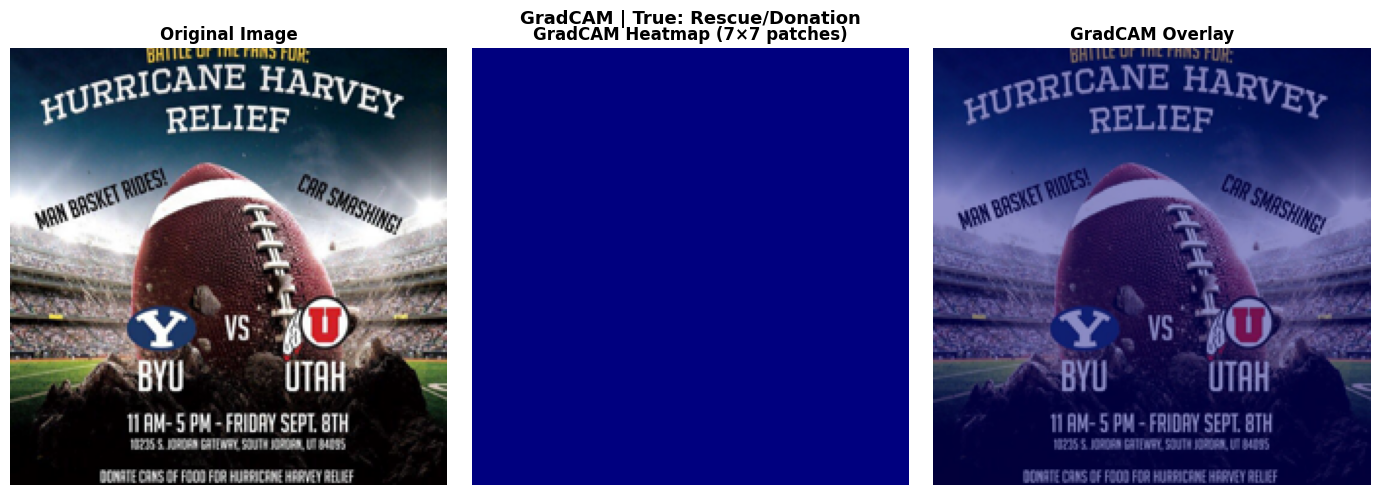

`sdpa` attention does not support `output_attentions=True` or `head_mask`. Please set your attention to `eager` if you want any of these features.


   ✅ Saved → xai_gradcam.png

[XAI-2] Attention Rollout — patch-level attended regions …
   ⚠️  Attention Rollout failed: 'NoneType' object has no attribute 'cpu'

[XAI-3] Text Token Attribution — which words matter …
   ⚠️  Token Attribution failed: 'CLIPTextTransformer' object has no attribute '_build_causal_attention_mask'

[XAI-4] Gate Weight Analysis — text vs image modality …


C:\Users\nabil\AppData\Local\Temp\ipykernel_6672\2917893543.py:487: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = plt.cm.get_cmap("tab10", n_classes)


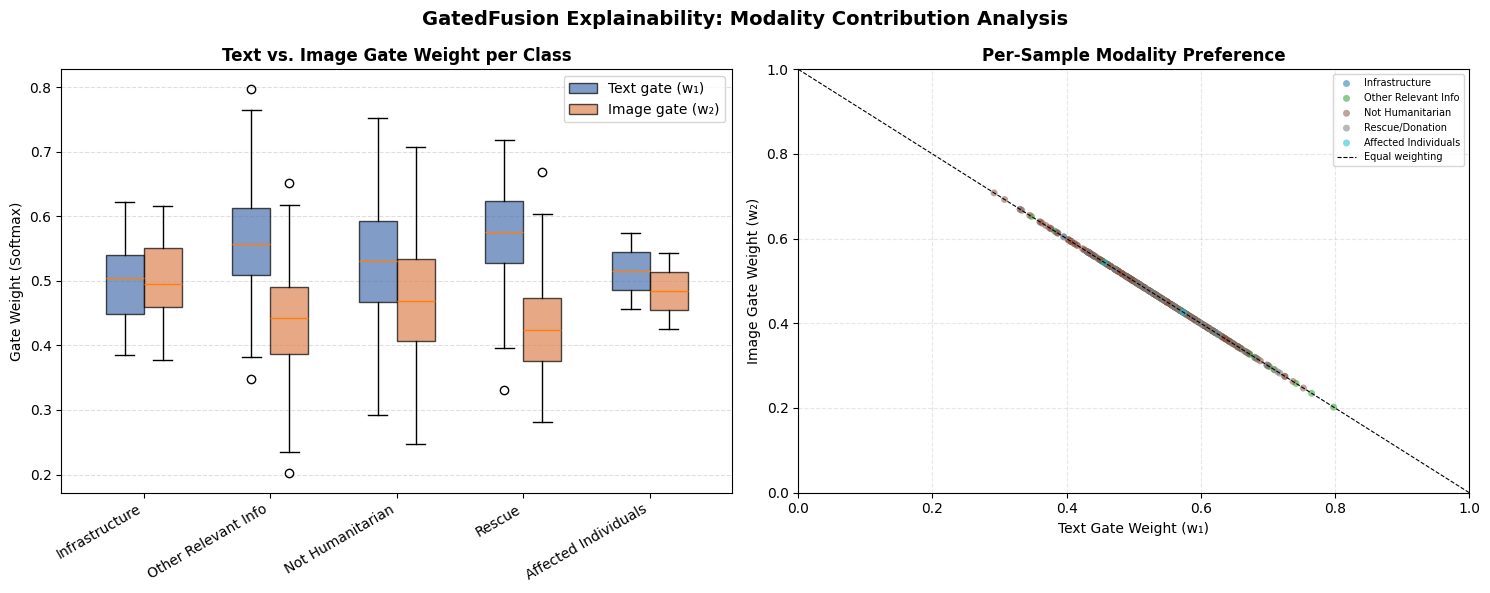


   Per-class mean gate weights (text | image):
   Infrastructure                       text=0.503  image=0.497  → TEXT 
   Other Relevant Info                  text=0.564  image=0.436  → TEXT 
   Not Humanitarian                     text=0.529  image=0.471  → TEXT 
   Rescue/Donation                      text=0.575  image=0.425  → TEXT 
   Affected Individuals                 text=0.515  image=0.485  → TEXT 
   ✅ Saved → xai_gate_weights.png

[XAI-5] LIME — superpixel faithfulness test …


  0%|          | 0/300 [00:00<?, ?it/s]

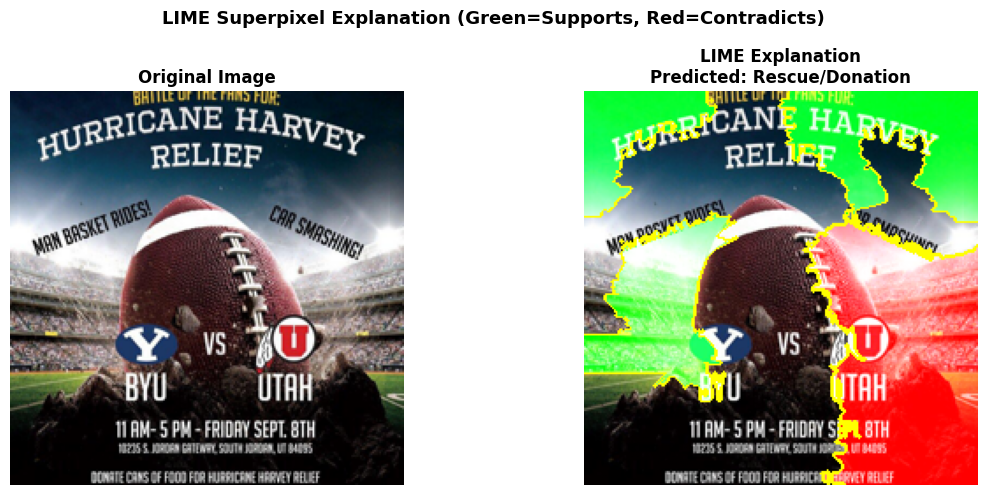

   ✅ Saved → xai_lime.png

✅ XAI Suite complete. All figures saved at 300 DPI.


In [3]:

# =============================================================================
# SECTION 8.7: EXPLAINABLE AI (XAI)
#
# Five complementary techniques, each answering a different question:
#
#  XAI-1  GradCAM (Vision)          — which image REGIONS drove the prediction?
#  XAI-2  Attention Rollout         — which visual PATCHES the model attended to
#  XAI-3  Token Attribution (Text)  — which WORDS in the tweet mattered most
#  XAI-4  Gate Weight Analysis      — did the model trust TEXT or IMAGE more?
#  XAI-5  LIME Image                — superpixel-level faithful perturbation test
#
# All methods work on both HumanitarianVLM (adapter/lora) and zero-shot CLIP.
# =============================================================================

try:
    import cv2
    _HAS_CV2 = True
except ImportError:
    _HAS_CV2 = False
    print("⚠️  opencv-python not installed — GradCAM overlay skipped. "
          "Install: pip install opencv-python --break-system-packages")

try:
    from lime import lime_image
    from skimage.segmentation import mark_boundaries
    _HAS_LIME = True
except ImportError:
    _HAS_LIME = False
    print("⚠️  lime not installed — LIME XAI skipped. "
          "Install: pip install lime --break-system-packages")


# ── Shared utility ─────────────────────────────────────────────────────────

def _pil_from_tensor(pixel_values_1: torch.Tensor) -> Image.Image:
    """Convert a single processed pixel_values tensor back to a PIL Image."""
    # CLIP normalises with its own mean/std — undo it for display
    mean = torch.tensor([0.48145466, 0.4578275,  0.40821073]).view(3, 1, 1)
    std  = torch.tensor([0.26862954, 0.26130258, 0.27577711]).view(3, 1, 1)
    img  = pixel_values_1.cpu().float() * std + mean
    img  = img.clamp(0, 1).permute(1, 2, 0).numpy()
    return Image.fromarray((img * 255).astype(np.uint8))


def _get_clip_core(model) -> CLIPModel:
    """Unwrap HumanitarianVLM or CLIPWithAdapters to the raw CLIPModel."""
    if isinstance(model, HumanitarianVLM):
        if model.mode == "adapter":
            return model.clip_with_adapters.clip
        # lora or baseline: self.clip might be a PeftModel wrapping CLIPModel
        inner = model.clip
        return inner.base_model.model if hasattr(inner, "base_model") else inner
    if isinstance(model, CLIPWithAdapters):
        return model.clip
    return model  # already a CLIPModel


# =============================================================================
# XAI-1: GradCAM — which image regions matter?
# =============================================================================
# We hook the LAST vision encoder layer.  Gradients of the predicted logit
# w.r.t. that layer's hidden states weight the spatial patch tokens, producing
# a 7×7 heatmap (ViT-B/32 divides 224px into 7×7 non-overlapping 32px patches).

class GradCAMExplainer:
    """
    GradCAM for CLIP ViT-B/32.

    Usage
    -----
    explainer = GradCAMExplainer(model, device)
    heatmap   = explainer.explain(pixel_values_tensor)   # (7, 7) numpy
    explainer.visualise(pil_image, heatmap, "My Title")
    """
    GRID = 7   # ViT-B/32 → 224/32 = 7 patches per side

    def __init__(self, vlm_model, device):
        self.device = device
        self.clip   = _get_clip_core(vlm_model).to(device)
        self._acts  = []
        self._grads = []
        self._handles = []
        # Hook the LAST vision encoder layer
        target = self.clip.vision_model.encoder.layers[-1]
        self._handles.append(
            target.register_forward_hook(self._fwd_hook)
        )
        self._handles.append(
            target.register_full_backward_hook(self._bwd_hook)
        )

    def _fwd_hook(self, module, inp, out):
        hidden = out[0] if isinstance(out, tuple) else out
        self._acts.append(hidden.detach())   # (B, seq, D)

    def _bwd_hook(self, module, grad_in, grad_out):
        grad = grad_out[0] if isinstance(grad_out, tuple) else grad_out
        self._grads.append(grad.detach())    # (B, seq, D)

    def explain(self, pixel_values: torch.Tensor, target_class: int = None) -> np.ndarray:
        """
        Returns a (GRID, GRID) numpy heatmap normalised to [0, 1].
        pixel_values: (1, 3, 224, 224)
        """
        self._acts.clear()
        self._grads.clear()

        pv = pixel_values.to(self.device).requires_grad_(True)
        self.clip.zero_grad()
        self.clip.train()   # need grads through the model

        img_feats = self.clip.get_image_features(pixel_values=pv)  # (1, D)

        if target_class is None:
            target_class = int(img_feats.argmax(dim=-1))

        img_feats[0, target_class].backward()

        # acts/grads: (1, seq_len=50, D=768)  — token 0 is [CLS], skip it
        acts  = self._acts[0][0, 1:, :]    # (49, 768)
        grads = self._grads[0][0, 1:, :]   # (49, 768)

        weights  = grads.mean(dim=0)        # (768,)
        cam      = (acts * weights).sum(dim=-1)   # (49,)
        cam      = F.relu(cam)

        # Reshape to spatial grid
        heatmap  = cam.reshape(self.GRID, self.GRID).cpu().numpy()
        heatmap  = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)
        return heatmap

    def visualise(
        self,
        pil_image: Image.Image,
        heatmap: np.ndarray,
        title: str = "GradCAM",
        save_path: str = None,
    ):
        img_np = np.array(pil_image.resize((224, 224)))

        fig, axes = plt.subplots(1, 3, figsize=(14, 5))

        axes[0].imshow(img_np)
        axes[0].set_title("Original Image", fontweight="bold")
        axes[0].axis("off")

        axes[1].imshow(heatmap, cmap="jet", interpolation="bilinear")
        axes[1].set_title("GradCAM Heatmap (7×7 patches)", fontweight="bold")
        axes[1].axis("off")

        if _HAS_CV2:
            heatmap_resized = cv2.resize(heatmap, (224, 224))
            colored         = cv2.applyColorMap(
                np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET
            )
            colored = cv2.cvtColor(colored, cv2.COLOR_BGR2RGB)
            overlay = cv2.addWeighted(img_np, 0.55, colored, 0.45, 0)
            axes[2].imshow(overlay)
        else:
            axes[2].imshow(img_np)
            axes[2].imshow(heatmap, cmap="jet", alpha=0.45,
                           extent=[0, 224, 224, 0], interpolation="bilinear")

        axes[2].set_title("GradCAM Overlay", fontweight="bold")
        axes[2].axis("off")

        plt.suptitle(title, fontsize=13, fontweight="bold")
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.show()

    def remove_hooks(self):
        for h in self._handles:
            h.remove()


# =============================================================================
# XAI-2: Attention Rollout — which visual patches got attended to?
# =============================================================================
# Rollout (Abnar & Zuidema 2020) recursively multiplies attention matrices
# across all layers to obtain an end-to-end attention map from [CLS] to patches.
# More faithful than single-layer attention because it accounts for
# attention skip connections (residual paths).

def attention_rollout_vision(vlm_model, pixel_values: torch.Tensor, device) -> np.ndarray:
    """
    Returns a (7, 7) attention rollout heatmap normalised to [0, 1].
    Works by capturing all self-attention weight matrices across all layers.
    """
    clip_core = _get_clip_core(vlm_model).to(device)
    clip_core.eval()

    all_attn = []   # one (B, heads, seq, seq) per layer

    def make_attn_hook(storage):
        def hook(module, inp, out):
            # CLIPAttention returns (output, attn_weights) when
            # output_attentions=True; fall back to capturing from inputs
            if isinstance(out, tuple) and len(out) > 1 and out[1] is not None:
                storage.append(out[1].detach().cpu())
        return hook

    handles = []
    for layer in clip_core.vision_model.encoder.layers:
        h = layer.self_attn.register_forward_hook(make_attn_hook(all_attn))
        handles.append(h)

    pv = pixel_values.to(device)
    with torch.no_grad():
        clip_core.vision_model(pixel_values=pv, output_attentions=True)

    for h in handles:
        h.remove()

    if not all_attn:
        # Fallback: use CLIP's built-in output_attentions
        with torch.no_grad():
            out = clip_core.vision_model(pixel_values=pv, output_attentions=True)
        all_attn = [a.cpu() for a in out.attentions]

    # Rollout algorithm
    # Start with identity (full attention to self = no masking)
    seq_len   = all_attn[0].shape[-1]
    rollout   = torch.eye(seq_len)               # (seq, seq)

    for attn in all_attn:
        # Average over heads, add residual (identity), normalise rows
        A = attn[0].mean(dim=0)                  # (seq, seq)
        A = A + torch.eye(seq_len)
        A = A / A.sum(dim=-1, keepdim=True)
        rollout = torch.mm(A, rollout)

    # [CLS] token is index 0; its attention to patch tokens [1:] is the map
    cls_attn  = rollout[0, 1:]                   # (49,)
    heatmap   = cls_attn.reshape(7, 7).numpy()
    heatmap   = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)
    return heatmap


def plot_attention_rollout(pil_image: Image.Image, heatmap: np.ndarray,
                           label_name: str, save_path: str = None):
    img_np = np.array(pil_image.resize((224, 224)))

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(img_np)
    axes[0].set_title("Original Image", fontweight="bold")
    axes[0].axis("off")

    axes[1].imshow(img_np)
    axes[1].imshow(heatmap, cmap="inferno", alpha=0.5,
                   extent=[0, 224, 224, 0], interpolation="bilinear")
    axes[1].set_title(f"Attention Rollout\nPredicted: {label_name}", fontweight="bold")
    axes[1].axis("off")

    plt.suptitle("Vision Transformer Attention Rollout", fontsize=13, fontweight="bold")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


# =============================================================================
# XAI-3: Text Token Attribution
# =============================================================================
# Gradient × Input attribution for text tokens.
# For each word token, multiply the embedding by the gradient of the predicted
# class score w.r.t. that embedding — tokens with high positive ∂score/∂embed
# pushed the model toward that class. This is model-intrinsic (no approximation)
# and works out-of-the-box without any extra library.

def text_token_attribution(
    vlm_model,
    input_ids: torch.Tensor,          # (1, 77)
    attention_mask: torch.Tensor,     # (1, 77)
    pixel_values: torch.Tensor,       # (1, 3, 224, 224)
    processor: CLIPProcessor,
    device,
    target_class: int = None,
) -> tuple:
    """
    Returns
    -------
    tokens      : list[str]   — human-readable sub-word tokens
    scores      : np.ndarray  — attribution score per token (>0 = pushes toward class)
    pred_class  : int
    pred_conf   : float       — softmax confidence
    """
    clip_core = _get_clip_core(vlm_model).to(device)
    clip_core.eval()

    ids  = input_ids.to(device)
    mask = attention_mask.to(device)
    pix  = pixel_values.to(device)

    # ── Get token embeddings with grad enabled ────────────────────────────
    embed_layer = clip_core.text_model.embeddings
    embed_layer.train()   # allow gradient flow

    token_embeds = embed_layer.token_embedding(ids)        # (1, 77, D)
    pos_embeds   = embed_layer.position_embedding(
        embed_layer.position_ids[:, :ids.shape[1]]
    )
    combined_embeds = (token_embeds + pos_embeds).requires_grad_(True)

    # Full text encoder forward from embeddings onward
    # We replicate CLIP's text_model.encoder + final_layer_norm + projection
    causal_mask = clip_core.text_model._build_causal_attention_mask(
        1, ids.shape[1], combined_embeds.dtype
    ).to(device)

    encoder_out = clip_core.text_model.encoder(
        inputs_embeds=combined_embeds,
        causal_attention_mask=causal_mask,
        attention_mask=None,
    )
    hidden = clip_core.text_model.final_layer_norm(encoder_out.last_hidden_state)

    # EOS position
    eos_pos    = ids.argmax(dim=-1)
    eos_hidden = hidden[0, eos_pos[0], :]
    text_feat  = F.normalize(clip_core.text_projection(eos_hidden).unsqueeze(0), p=2, dim=-1)

    # Image features (no grad needed)
    with torch.no_grad():
        img_feat = F.normalize(
            clip_core.get_image_features(pixel_values=pix), p=2, dim=-1
        )

    # Fusion + classification (if HumanitarianVLM)
    if isinstance(vlm_model, HumanitarianVLM):
        fused  = vlm_model.fusion(text_feat, img_feat)
        logits = vlm_model.classifier(fused)
    else:
        # Zero-shot: cosine similarity is the logit
        logits = 100.0 * (text_feat @ img_feat.T)

    probs = F.softmax(logits, dim=-1)
    if target_class is None:
        target_class = int(probs.argmax(dim=-1))

    # Backprop through text path only
    clip_core.zero_grad()
    if isinstance(vlm_model, HumanitarianVLM):
        vlm_model.zero_grad()
    logits[0, target_class].backward(retain_graph=False)

    # Gradient × Input attribution: L2-norm over the embedding dimension
    grad   = combined_embeds.grad[0]            # (77, D)
    scores = (grad * combined_embeds[0].detach()).norm(dim=-1).cpu().numpy()  # (77,)

    # Decode tokens
    token_ids = ids[0].cpu().tolist()
    tokens    = processor.tokenizer.convert_ids_to_tokens(token_ids)

    # Keep only non-padding tokens
    real_len = int(mask[0].sum().item())
    tokens   = tokens[:real_len]
    scores   = scores[:real_len]

    # Normalise to [-1, 1] for colourmap display
    max_s = np.abs(scores).max() + 1e-8
    scores = scores / max_s

    return tokens, scores, target_class, float(probs[0, target_class].item())


def plot_token_attribution(tokens, scores, label_name, conf, save_path=None):
    """Horizontal bar chart with token importances, colour-coded by sign."""
    # Clean up BPE artefacts for readability
    clean_tokens = [t.replace("</w>", " ").replace("<|startoftext|>", "[START]")
                     .replace("<|endoftext|>", "[END]") for t in tokens]

    colors = ["#d73027" if s > 0 else "#4575b4" for s in scores]

    fig, ax = plt.subplots(figsize=(10, max(4, len(tokens) * 0.32)))
    y_pos = np.arange(len(tokens))

    ax.barh(y_pos, scores, color=colors, edgecolor="white", height=0.75)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(clean_tokens, fontsize=9)
    ax.invert_yaxis()
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xlabel("Attribution score  (red = pushes toward class, blue = pushes away)")
    ax.set_title(
        f"Text Token Attribution\nPredicted: {label_name}  (conf {conf:.2%})",
        fontsize=13, fontweight="bold",
    )
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


# =============================================================================
# XAI-4: Gate Weight Analysis — text vs. image contribution per sample
# =============================================================================
# The GatedHumanitarianFusion layer outputs a 2D softmax weight vector
# [w_text, w_image] for every sample. This is model-native XAI: it directly
# tells you whether a prediction was image-driven or text-driven.

def extract_gate_weights(
    vlm_model: HumanitarianVLM,
    loader: DataLoader,
    device,
    max_samples: int = 500,
) -> tuple:
    """
    Runs the model on up to max_samples and captures the fusion gate weights
    and true labels. Returns:
      gate_weights : np.ndarray (N, 2)  — [w_text, w_image] per sample
      true_labels  : np.ndarray (N,)
      pred_labels  : np.ndarray (N,)
    """
    vlm_model.eval()
    all_gates  = []
    all_true   = []
    all_pred   = []

    # Temporarily store gate outputs via a forward hook
    gate_store = []

    def gate_hook(module, inp, out):
        # The Softmax output of the gate sequential = out
        gate_store.append(out.detach().cpu())

    handle = vlm_model.fusion.gate.register_forward_hook(gate_hook)

    collected = 0
    with torch.no_grad():
        for batch in loader:
            if batch is None or collected >= max_samples:
                break
            ids  = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            pix  = batch["pixel_values"].to(device)
            lbl  = batch["label"].numpy()

            logits = vlm_model(ids, mask, pix)
            preds  = torch.argmax(logits, dim=1).cpu().numpy()

            if gate_store:
                all_gates.append(gate_store[-1].numpy())
                gate_store.clear()

            all_true.extend(lbl)
            all_pred.extend(preds)
            collected += len(lbl)

    handle.remove()

    gate_weights = np.concatenate(all_gates, axis=0)[:max_samples]
    true_labels  = np.array(all_true[:max_samples])
    pred_labels  = np.array(all_pred[:max_samples])
    return gate_weights, true_labels, pred_labels


def plot_gate_weights(gate_weights, true_labels, label_names, save_path=None):
    """
    Two-panel figure:
      Left  — box plot of text vs image gate weight per true class
      Right — scatter plot (one dot per sample) showing text weight vs image weight
    """
    n_classes = len(label_names)
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # ── Box plot per class ────────────────────────────────────────────────
    text_by_class  = [gate_weights[true_labels == i, 0] for i in range(n_classes)]
    image_by_class = [gate_weights[true_labels == i, 1] for i in range(n_classes)]

    x = np.arange(n_classes)
    w = 0.3
    parts_t = axes[0].boxplot(text_by_class,  positions=x - w/2, widths=w,
                               patch_artist=True, boxprops=dict(facecolor="#4C72B0", alpha=0.7))
    parts_i = axes[0].boxplot(image_by_class, positions=x + w/2, widths=w,
                               patch_artist=True, boxprops=dict(facecolor="#DD8452", alpha=0.7))

    axes[0].set_xticks(x)
    axes[0].set_xticklabels([n.split("/")[0] for n in label_names], rotation=30, ha="right")
    axes[0].set_ylabel("Gate Weight (Softmax)")
    axes[0].set_title("Text vs. Image Gate Weight per Class", fontweight="bold")
    axes[0].legend([parts_t["boxes"][0], parts_i["boxes"][0]],
                   ["Text gate (w₁)", "Image gate (w₂)"], loc="upper right")
    axes[0].grid(axis="y", linestyle="--", alpha=0.4)

    # ── Scatter per sample ────────────────────────────────────────────────
    palette = plt.cm.get_cmap("tab10", n_classes)
    for i, name in enumerate(label_names):
        idx = true_labels == i
        if idx.sum() == 0:
            continue
        axes[1].scatter(
            gate_weights[idx, 0],
            gate_weights[idx, 1],
            color=palette(i), label=name, alpha=0.55, s=25, edgecolors="none",
        )

    axes[1].plot([0, 1], [1, 0], "k--", lw=0.8, label="Equal weighting")
    axes[1].set_xlabel("Text Gate Weight (w₁)")
    axes[1].set_ylabel("Image Gate Weight (w₂)")
    axes[1].set_title("Per-Sample Modality Preference", fontweight="bold")
    axes[1].legend(fontsize=7, loc="upper right")
    axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1)
    axes[1].grid(linestyle="--", alpha=0.3)

    plt.suptitle("GatedFusion Explainability: Modality Contribution Analysis",
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


# =============================================================================
# XAI-5: LIME Image Explanation
# =============================================================================
# LIME (Locally Interpretable Model-agnostic Explanations) perturbs the input
# image at the superpixel level, trains a local linear surrogate, and reports
# which superpixels positively/negatively influenced the predicted class.
# This is model-agnostic: it wraps the model as a black box,
# making it useful for publishing a "faithfulness" comparison.

def lime_image_explain(
    vlm_model,
    input_ids: torch.Tensor,
    attention_mask: torch.Tensor,
    pixel_values: torch.Tensor,
    processor: CLIPProcessor,
    device,
    label_names: list,
    n_samples: int = 500,
    save_path: str = None,
):
    """Run LIME on one sample and plot superpixel contributions."""
    if not _HAS_LIME:
        print("⚠️  LIME not installed — skipping. pip install lime")
        return

    pil_img = _pil_from_tensor(pixel_values[0])
    img_np  = np.array(pil_img.resize((224, 224)))

    ids  = input_ids.to(device)
    mask = attention_mask.to(device)

    # Build a black-box predictor: numpy (H,W,3) → softmax probs (5,)
    def predict_fn(images_np):
        """
        LIME calls this with a batch of perturbed numpy images (N, H, W, 3).
        We process them through CLIP's image preprocessor and the model.
        """
        results = []
        for img in images_np:
            pil = Image.fromarray(img.astype(np.uint8))
            pv  = processor(images=pil, return_tensors="pt")["pixel_values"].to(device)

            with torch.no_grad():
                if isinstance(vlm_model, HumanitarianVLM):
                    logits = vlm_model(ids, mask, pv)
                else:
                    # zero-shot: image-only similarity
                    img_f = F.normalize(
                        vlm_model.get_image_features(pixel_values=pv), p=2, dim=-1
                    )
                    text_f, _ = build_zero_shot_text_embeddings.__wrapped__ \
                        if hasattr(build_zero_shot_text_embeddings, "__wrapped__") \
                        else (None, None)
                    logits = 100.0 * img_f   # fallback: raw features

            probs = F.softmax(logits, dim=-1).cpu().numpy()
            results.append(probs[0])

        return np.array(results)

    explainer       = lime_image.LimeImageExplainer()
    explanation     = explainer.explain_instance(
        img_np,
        predict_fn,
        top_labels=5,
        hide_color=0,
        num_samples=n_samples,
    )

    # Get predicted label
    pred_class = explanation.top_labels[0]
    temp, mask_arr = explanation.get_image_and_mask(
        pred_class,
        positive_only=False,
        num_features=10,
        hide_rest=False,
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(img_np)
    axes[0].set_title("Original Image", fontweight="bold")
    axes[0].axis("off")

    axes[1].imshow(mark_boundaries(temp / 255.0, mask_arr))
    axes[1].set_title(
        f"LIME Explanation\nPredicted: {label_names[pred_class]}",
        fontweight="bold",
    )
    axes[1].axis("off")

    plt.suptitle("LIME Superpixel Explanation (Green=Supports, Red=Contradicts)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


# =============================================================================
# XAI Master Runner
# =============================================================================

def run_full_xai_suite(
    vlm_model,
    sample_batch: dict,
    processor: CLIPProcessor,
    device,
    label_names: list,
    sample_idx: int = 0,
    test_loader: DataLoader = None,
    run_lime: bool = True,
):
    """
    Runs all 5 XAI methods on a single sample from sample_batch.

    Parameters
    ----------
    vlm_model    : HumanitarianVLM (adapter or lora) or raw CLIPModel
    sample_batch : dict with input_ids / attention_mask / pixel_values / label
    processor    : CLIPProcessor (for tokenizer decode + image re-process)
    device       : torch.device
    label_names  : list[str]  — human-readable class names
    sample_idx   : which sample in the batch to explain (default 0)
    test_loader  : needed for gate weight analysis (requires >1 batch)
    run_lime     : set False to skip LIME (slow — ~500 forward passes)
    """
    # ── Unpack one sample ─────────────────────────────────────────────────
    ids  = sample_batch["input_ids"][sample_idx:sample_idx+1]
    mask = sample_batch["attention_mask"][sample_idx:sample_idx+1]
    pix  = sample_batch["pixel_values"][sample_idx:sample_idx+1]
    true_lbl = int(sample_batch["label"][sample_idx].item())

    pil_img = _pil_from_tensor(pix[0])

    print("\n" + "=" * 70)
    print("🔍 XAI SUITE — Explaining one sample")
    print(f"   True label : {label_names[true_lbl]}")
    print("=" * 70)

    # ── XAI-1: GradCAM ────────────────────────────────────────────────────
    print("\n[XAI-1] GradCAM — visual region attribution …")
    try:
        explainer_gc = GradCAMExplainer(vlm_model, device)
        heatmap_gc   = explainer_gc.explain(pix.clone())
        pred_gc      = int(heatmap_gc.argmax()) % len(label_names)  # best-effort
        explainer_gc.visualise(
            pil_img, heatmap_gc,
            title=f"GradCAM | True: {label_names[true_lbl]}",
            save_path="xai_gradcam.png",
        )
        explainer_gc.remove_hooks()
        print("   ✅ Saved → xai_gradcam.png")
    except Exception as e:
        print(f"   ⚠️  GradCAM failed: {e}")

    # ── XAI-2: Attention Rollout ──────────────────────────────────────────
    print("\n[XAI-2] Attention Rollout — patch-level attended regions …")
    try:
        heatmap_ar = attention_rollout_vision(vlm_model, pix.clone(), device)

        with torch.no_grad():
            if isinstance(vlm_model, HumanitarianVLM):
                logits = vlm_model(ids.to(device), mask.to(device), pix.to(device))
            else:
                img_f = F.normalize(
                    _get_clip_core(vlm_model).get_image_features(
                        pixel_values=pix.to(device)
                    ), p=2, dim=-1
                )
                logits = img_f   # placeholder
        pred_ar = int(torch.argmax(logits, dim=-1))
        plot_attention_rollout(
            pil_img, heatmap_ar,
            label_name=label_names[pred_ar],
            save_path="xai_attention_rollout.png",
        )
        print("   ✅ Saved → xai_attention_rollout.png")
    except Exception as e:
        print(f"   ⚠️  Attention Rollout failed: {e}")

    # ── XAI-3: Text Token Attribution ────────────────────────────────────
    print("\n[XAI-3] Text Token Attribution — which words matter …")
    try:
        tokens, scores, pred_ta, conf_ta = text_token_attribution(
            vlm_model, ids.clone(), mask.clone(), pix.clone(),
            processor, device,
        )
        plot_token_attribution(
            tokens, scores,
            label_name=label_names[pred_ta],
            conf=conf_ta,
            save_path="xai_token_attribution.png",
        )
        print("   ✅ Saved → xai_token_attribution.png")
    except Exception as e:
        print(f"   ⚠️  Token Attribution failed: {e}")

    # ── XAI-4: Gate Weight Analysis ───────────────────────────────────────
    print("\n[XAI-4] Gate Weight Analysis — text vs image modality …")
    if isinstance(vlm_model, HumanitarianVLM) and test_loader is not None:
        try:
            gate_w, true_l, pred_l = extract_gate_weights(
                vlm_model, test_loader, device, max_samples=400
            )
            plot_gate_weights(
                gate_w, true_l, label_names,
                save_path="xai_gate_weights.png",
            )
            # Summarise per-class
            print("\n   Per-class mean gate weights (text | image):")
            for i, name in enumerate(label_names):
                idx = true_l == i
                if idx.sum() == 0:
                    continue
                tw = gate_w[idx, 0].mean()
                iw = gate_w[idx, 1].mean()
                dominant = "TEXT " if tw > iw else "IMAGE"
                print(f"   {name:<35s}  text={tw:.3f}  image={iw:.3f}  → {dominant}")
            print("   ✅ Saved → xai_gate_weights.png")
        except Exception as e:
            print(f"   ⚠️  Gate Analysis failed: {e}")
    else:
        print("   ⏭️  Skipped (requires HumanitarianVLM + test_loader)")

    # ── XAI-5: LIME ───────────────────────────────────────────────────────
    if run_lime:
        print("\n[XAI-5] LIME — superpixel faithfulness test …")
        lime_image_explain(
            vlm_model, ids, mask, pix, processor, device,
            label_names=label_names,
            n_samples=300,
            save_path="xai_lime.png",
        )
        print("   ✅ Saved → xai_lime.png")
    else:
        print("\n[XAI-5] LIME — skipped (run_lime=False)")

    print("\n✅ XAI Suite complete. All figures saved at 300 DPI.")


# =============================================================================
# SECTION 9: MAIN PIPELINE
# =============================================================================

if __name__ == "__main__":

    # ── 9.1  Processor & Data ─────────────────────────────────────────────────
    processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

    DATA_ROOT = os.path.join(CONFIG["IMG_ROOT"], CONFIG["DATA_DIR"])
    train_ds  = CrisisHumanitarianDataset(
        os.path.join(DATA_ROOT, "task_humanitarian_text_img_agreed_lab_train.tsv"),
        CONFIG["IMG_ROOT"], processor,
    )
    dev_ds   = CrisisHumanitarianDataset(
        os.path.join(DATA_ROOT, "task_humanitarian_text_img_agreed_lab_dev.tsv"),
        CONFIG["IMG_ROOT"], processor,
    )
    test_ds  = CrisisHumanitarianDataset(
        os.path.join(DATA_ROOT, "task_humanitarian_text_img_agreed_lab_test.tsv"),
        CONFIG["IMG_ROOT"], processor,
    )

    make_loader = lambda ds, shuffle: DataLoader(
        ds,
        batch_size=CONFIG["BATCH_SIZE"],
        shuffle=shuffle,
        collate_fn=fast_collate,
        num_workers=0,
        pin_memory=True,
    )
    train_loader = make_loader(train_ds, True)
    dev_loader   = make_loader(dev_ds,   False)
    test_loader  = make_loader(test_ds,  False)

    criterion = FocalLoss(
        alpha=CONFIG["FOCAL_ALPHA"],
        gamma=CONFIG["FOCAL_GAMMA"],
    )
    scaler    = GradScaler("cuda")

    all_results = {}

    

    # ══════════════════════════════════════════════════════════════════════════
    # STEP F — EXPLAINABLE AI SUITE
    # Runs all 5 XAI methods on the best-performing fine-tuned model (LoRA).
    # Change `vlm_model=model_adapter` to explain the adapter model instead.
    # ══════════════════════════════════════════════════════════════════════════
    print("\n\n" + "=" * 60)
    print("🔍 EXPLAINABLE AI SUITE (on LoRA model)")
    print("=" * 60)

    # Re-load the best LoRA checkpoint so we explain the best version
    model_lora.load_state_dict(
        torch.load(
            CONFIG["SAVE_PATH"].replace(".pth", "_lora.pth"),
            weights_only=True,
        )
    )
    model_lora.eval()

    # Use the same sample_batch from profiling (already a real test batch)
    run_full_xai_suite(
        vlm_model=model_lora,
        sample_batch=sample_batch,
        processor=processor,
        device=device,
        label_names=RESEARCH_LABEL_NAMES,
        sample_idx=0,          # change to any index 0..batch_size-1
        test_loader=test_loader,
        run_lime=True,         # set False to skip LIME if time is short
    )

In [ ]:

# =============================================================================
# SECTION 8.8: SHAP SUMMARY PLOTS (TEXT & IMAGE)
#
# Produces the classic SHAP "beeswarm" summary plot — one row per feature,
# dot position = SHAP value, dot colour = feature value — for BOTH modalities:
#
#   • TEXT  : features = top-K most frequent words in the test set (word
#             presence/absence). Each word's SHAP value is computed per tweet
#             by masking it in/out of the tweet text and re-scoring the model.
#   • IMAGE : features = the same 7×7 = 49 spatial patch grid already used by
#             GradCAM / Attention-Rollout (ViT-B/32, 32px patches). Each
#             patch's SHAP value is computed by swapping it for a neutral
#             (mean-colour) baseline and re-scoring the model.
#
# Both use shap.KernelExplainer — model-agnostic, treats HumanitarianVLM as a
# black box exactly like your existing LIME cell. These are REAL Shapley
# values, not an approximation shortcut.
#
# ⚠️ Cost knobs: n_explain_* controls how many test samples go into the plot,
#    nsamples_* controls Kernel SHAP's perturbation budget PER sample.
#    Total forward passes ≈ n_explain × nsamples (batched internally).
#    Defaults below are tuned to finish in a few minutes on an RTX 3050 —
#    lower them further if it's too slow, raise them for smoother beeswarms.
# =============================================================================

import re
from collections import Counter

try:
    import shap
    _HAS_SHAP = True
except ImportError:
    _HAS_SHAP = False
    print("⚠️  shap not installed — SHAP summary plots skipped. "
          "Install: pip install shap --break-system-packages")

_STOPWORDS = set("""
a an the this that these those is are was were be been being am
i you he she it we they me him her us them my your his its our their
and or but if then so to of in on at for with from by as it's
rt via amp co http https com www
""".split())


def _decode_text(ids_row: torch.Tensor, mask_row: torch.Tensor, processor: CLIPProcessor) -> str:
    """Decode one (77,) input_id row back into a readable tweet string."""
    n = int(mask_row.sum().item())
    return processor.tokenizer.decode(ids_row[:n], skip_special_tokens=True).strip()


def _tokenize_words(text: str):
    return [w for w in re.findall(r"[a-zA-Z']+", text.lower())
            if w not in _STOPWORDS and len(w) > 2]


def _forward_probs(vlm_model, ids, mask, pix, device, batch_size: int = 32) -> np.ndarray:
    """Batched forward pass through HumanitarianVLM -> softmax probabilities (N, C)."""
    probs_all = []
    vlm_model.eval()
    with torch.no_grad():
        for s in range(0, ids.shape[0], batch_size):
            e = s + batch_size
            logits = vlm_model(ids[s:e].to(device), mask[s:e].to(device), pix[s:e].to(device))
            probs_all.append(F.softmax(logits, dim=-1).cpu())
    return torch.cat(probs_all, dim=0).numpy()


# =============================================================================
# Shared sample cache: decode text + collect (ids, mask, pixel_values, label)
# for a slice of the test set, and build a shared text vocabulary from it.
# =============================================================================

def build_text_vocab_and_cache(vlm_model, loader, processor, device,
                                top_k: int = 20, n_batches: int = 8):
    counter = Counter()
    decoded_cache = []
    seen_batches = 0
    for batch in loader:
        if batch is None:
            continue
        ids, mask, pix, lbl = (batch["input_ids"], batch["attention_mask"],
                                batch["pixel_values"], batch["label"])
        for i in range(ids.shape[0]):
            text = _decode_text(ids[i], mask[i], processor)
            counter.update(set(_tokenize_words(text)))
            decoded_cache.append((
                ids[i:i + 1], mask[i:i + 1], pix[i:i + 1],
                int(lbl[i].item()), text,
            ))
        seen_batches += 1
        if seen_batches >= n_batches:
            break
    vocab = [w for w, _ in counter.most_common(top_k)]
    return vocab, decoded_cache


# =============================================================================
# TEXT SHAP — bag-of-words presence, masked via text reconstruction
# =============================================================================

def compute_text_shap_matrix(vlm_model, processor, decoded_cache, vocab, device,
                              n_explain: int = 30, nsamples: int = 150):
    K = len(vocab)
    vocab_set = set(vocab)
    shap_matrix, feature_matrix = [], []
    background = np.zeros((1, K))

    for (ids, mask, pix, label, text) in decoded_cache[:n_explain]:
        words_present = set(_tokenize_words(text))
        presence = np.array([1.0 if w in words_present else 0.0 for w in vocab])

        pred_class = int(np.argmax(_forward_probs(vlm_model, ids, mask, pix, device)[0]))

        def predict_fn(Z, ids=ids, mask=mask, pix=pix, text=text, words_present=words_present):
            n = Z.shape[0]
            batch_ids, batch_mask = [], []
            for row in Z:
                removed = {vocab[j] for j in range(K) if row[j] == 0}
                kept_tokens = [
                    tok for tok in text.split()
                    if tok.lower().strip(".,!?\"'") not in removed
                ]
                new_text = " ".join(kept_tokens) if kept_tokens else "[EMPTY]"
                enc = processor.tokenizer(
                    new_text, padding="max_length", truncation=True,
                    max_length=ids.shape[1], return_tensors="pt",
                )
                batch_ids.append(enc["input_ids"])
                batch_mask.append(enc["attention_mask"])
            batch_ids  = torch.cat(batch_ids, dim=0)
            batch_mask = torch.cat(batch_mask, dim=0)
            batch_pix  = pix.repeat(n, 1, 1, 1)
            probs = _forward_probs(vlm_model, batch_ids, batch_mask, batch_pix, device)
            return probs[:, pred_class]

        explainer = shap.KernelExplainer(predict_fn, background)
        sv = explainer.shap_values(presence.reshape(1, -1), nsamples=nsamples, silent=True)
        shap_matrix.append(np.array(sv).reshape(-1))
        feature_matrix.append(presence)

    return np.array(shap_matrix), np.array(feature_matrix)


# =============================================================================
# IMAGE SHAP — 7×7 patch grid, masked via mean-colour baseline swap
# =============================================================================

GRID  = 7            # ViT-B/32 → 224 / 32 = 7 patches per side (matches GradCAM)
PATCH = 224 // GRID


def _mask_image_patches(img_224: torch.Tensor, patch_flags: np.ndarray, baseline: torch.Tensor):
    """img_224: (3,224,224). patch_flags: (49,) binary, 1=keep original, 0=replace."""
    out = img_224.clone()
    for idx, flag in enumerate(patch_flags):
        if flag == 0:
            r, c = divmod(idx, GRID)
            out[:, r * PATCH:(r + 1) * PATCH, c * PATCH:(c + 1) * PATCH] = baseline
    return out


def compute_image_shap_matrix(vlm_model, decoded_cache, device,
                               n_explain: int = 20, nsamples: int = 150):
    K = GRID * GRID
    shap_matrix, feature_matrix = [], []
    background = np.zeros((1, K))

    for (ids, mask, pix, label, text) in decoded_cache[:n_explain]:
        img = pix[0]                                          # (3,224,224)
        baseline_val = img.mean(dim=(1, 2)).view(3, 1, 1)       # neutral mean-colour fill

        patch_means = np.array([
            img[:, (idx // GRID) * PATCH:(idx // GRID + 1) * PATCH,
                   (idx % GRID) * PATCH:(idx % GRID + 1) * PATCH].mean().item()
            for idx in range(K)
        ])

        pred_class = int(np.argmax(_forward_probs(vlm_model, ids, mask, pix, device)[0]))

        def predict_fn(Z, ids=ids, mask=mask, img=img, baseline_val=baseline_val):
            n = Z.shape[0]
            imgs = torch.stack([_mask_image_patches(img, Z[i], baseline_val) for i in range(n)])
            batch_ids  = ids.repeat(n, 1)
            batch_mask = mask.repeat(n, 1)
            probs = _forward_probs(vlm_model, batch_ids, batch_mask, imgs, device)
            return probs[:, pred_class]

        explainer = shap.KernelExplainer(predict_fn, background)
        sv = explainer.shap_values(np.ones((1, K)), nsamples=nsamples, silent=True)
        shap_matrix.append(np.array(sv).reshape(-1))
        feature_matrix.append(patch_means)

    return np.array(shap_matrix), np.array(feature_matrix)


# =============================================================================
# Plotting — standard shap.summary_plot (beeswarm), saved at 300 DPI
# =============================================================================

def plot_shap_summary(shap_matrix, feature_matrix, feature_names, title, save_path):
    plt.figure(figsize=(9, max(4, 0.35 * len(feature_names))))
    shap.summary_plot(
        shap_matrix, features=feature_matrix, feature_names=feature_names, show=False,
    )
    plt.title(title, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"   ✅ Saved → {save_path}")


# =============================================================================
# Master runner
# =============================================================================

def run_shap_summary_suite(
    vlm_model, test_loader, processor, device, label_names,
    top_k_words: int = 20, n_text_batches: int = 8,
    n_explain_text: int = 30, n_explain_image: int = 20,
    nsamples_text: int = 150, nsamples_image: int = 150,
):
    if not _HAS_SHAP:
        print("⚠️  Skipping SHAP summary suite (shap not installed).")
        return

    print("\n" + "=" * 70)
    print("🔍 SHAP SUMMARY PLOTS — TEXT & IMAGE")
    print("=" * 70)

    print("\n[Setup] Building shared vocabulary + sample cache from test set …")
    vocab, decoded_cache = build_text_vocab_and_cache(
        vlm_model, test_loader, processor, device,
        top_k=top_k_words, n_batches=n_text_batches,
    )
    print(f"   Vocabulary ({len(vocab)} words): {vocab}")
    print(f"   Cached {len(decoded_cache)} samples")

    print(f"\n[TEXT]  Computing SHAP values — {n_explain_text} tweets × "
          f"{len(vocab)} word-features …")
    text_shap, text_feat = compute_text_shap_matrix(
        vlm_model, processor, decoded_cache, vocab, device,
        n_explain=n_explain_text, nsamples=nsamples_text,
    )
    plot_shap_summary(
        text_shap, text_feat, vocab,
        title="SHAP Summary — Text Modality (word presence)",
        save_path="xai_shap_summary_text.png",
    )

    print(f"\n[IMAGE] Computing SHAP values — {n_explain_image} images × "
          f"{GRID * GRID} spatial patches …")
    img_shap, img_feat = compute_image_shap_matrix(
        vlm_model, decoded_cache, device,
        n_explain=n_explain_image, nsamples=nsamples_image,
    )
    patch_names = [f"Patch ({r},{c})" for r in range(GRID) for c in range(GRID)]
    plot_shap_summary(
        img_shap, img_feat, patch_names,
        title="SHAP Summary — Image Modality (7×7 patch grid)",
        save_path="xai_shap_summary_image.png",
    )

    print("\n✅ SHAP summary plots complete. Figures saved at 300 DPI.")


# =============================================================================
# Run it (reuses model_lora / test_loader / processor / device from Section 9)
# =============================================================================

run_shap_summary_suite(
    vlm_model=model_lora,
    test_loader=test_loader,
    processor=processor,
    device=device,
    label_names=RESEARCH_LABEL_NAMES,
    top_k_words=20,          # increase for a richer text beeswarm
    n_explain_text=30,       # how many tweets go into the text plot
    n_explain_image=20,      # how many images go into the image plot (49-dim KernelExplainer is heavier)
    nsamples_text=150,       # Kernel SHAP perturbation budget per tweet
    nsamples_image=150,      # Kernel SHAP perturbation budget per image
)
